SuperCellMulti identifies robust multiomics metacells increasing inter-modality consistency compared to single cells. 

# Package loading

In [ ]:
#library(Cairo)
#options(bitmapType = "cairo")

In [1]:
library(SuperCell)
library(Seurat)
library(ggplot2)
library(scales)
library(patchwork)
#library(ggpubr)

#library(rstatix)
#library(purrr)
# library(effectsize)



Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




ERROR: Error in library(ggpubr): there is no package called ‘ggpubr’


In [9]:
source("../../../R/functions/CoveragePlots.R")
source("../../../R/functions/StatTestPlots.R")


In [2]:
# datadir <- ../../../ in the workflow
# in home with the notebook
datadir <- "/mnt/beegfs01/scratch/l_herault/tests/SuperCellMultiomicsAnalyses/" 

## Bone marrow cite seq results

Single cells

An object of class Seurat 
17034 features across 30672 samples within 2 assays 
Active assay: RNA (17009 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: ADT
 6 dimensional reductions calculated: spca, apca, pca, wnn.umap, pca_diffusion, apca_diffusion

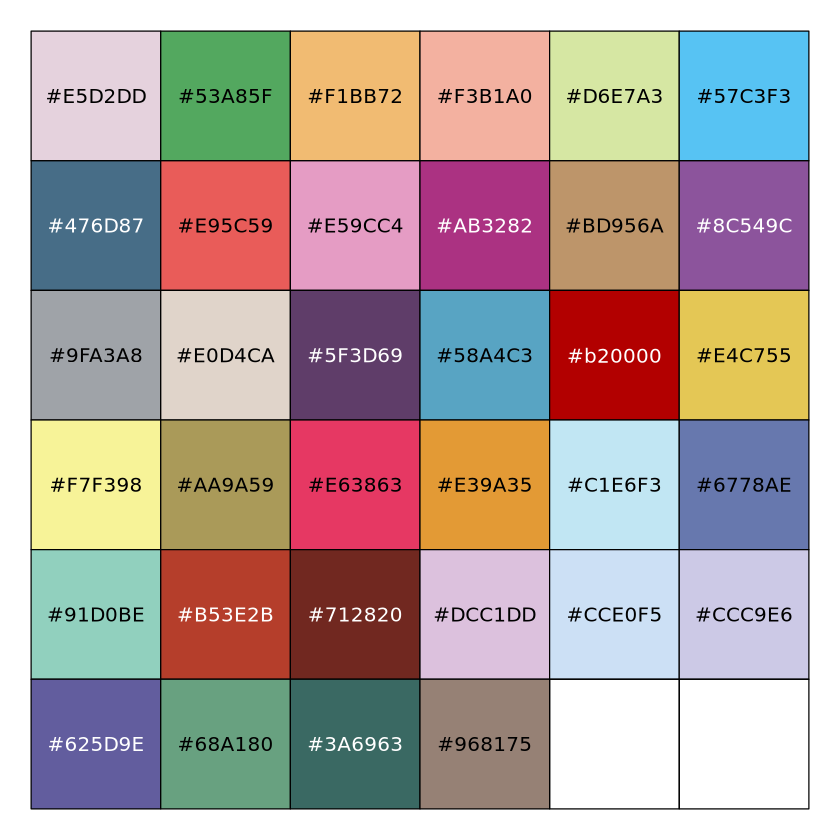

In [3]:
bm <- readRDS(paste0(datadir,"/output/bmCiteSeq/singlecells_analysis/seuratWNN.rds"))
bm




addCellType <- function(bm) {
  bm$celltype <- as.vector(bm$celltype.l2)
  bm$celltype[startsWith(bm$celltype,"Prog_B")] <- "Prog_B"
  bm$celltype[startsWith(bm$celltype,"CD8 Effector")] <- "CD8 Effector"
  bm$celltype[startsWith(bm$celltype,"CD8 Memory")] <- "CD8 Mem"
  # bm$celltype[startsWith(bm$celltype,"CD8 ")] <- "CD8"
  # bm$celltype[startsWith(bm$celltype,"CD4 ")] <- "CD4"
  bm$celltype[bm$celltype == "Naive B"] <- "B Naive"
  bm$celltype[bm$celltype == "Memory B"] <- "B Mem"
  bm$celltype[bm$celltype == "CD4 Memory"] <- "CD4 Mem"
  bm$celltype[bm$celltype == "Plasmablast"] <- "Plasma"
  
  
  #bm$celltype[endsWith(bm$celltype,"Mono")] <- "Mono"
  
  bm$celltype[startsWith(bm$celltype,"CD56 bright NK")] <- "NK"
  bm$celltype[startsWith(bm$celltype,"Prog_Mk")] <- "MEP"
  bm$celltype[startsWith(bm$celltype,"Prog_RBC")] <- "MEP"
  bm$celltype.l2 <- factor(bm$celltype.l2) 
  bm$celltype <- factor(bm$celltype) 
  
  return(bm)
}

bm <- addCellType(bm)

colors  <- c('#E5D2DD', '#53A85F', '#F1BB72', '#F3B1A0', '#D6E7A3', '#57C3F3', '#476D87',
             '#E95C59', '#E59CC4', '#AB3282', '#BD956A', '#8C549C',
             '#9FA3A8', '#E0D4CA', '#5F3D69', '#58A4C3', "#b20000",'#E4C755', '#F7F398',
             '#AA9A59', '#E63863', '#E39A35', '#C1E6F3', '#6778AE', '#91D0BE', '#B53E2B',
             '#712820', '#DCC1DD', '#CCE0F5', '#CCC9E6', '#625D9E', '#68A180', '#3A6963',
             '#968175')

show_col(colors)



color.celltypes.bm  <- c("MEP" = '#D6E7A3',
                         "gdT" = '#E95C59',
                         "GMP" = '#476D87',
                         "LMPP" = '#3A6963',
                         "Prog_DC" =  '#625D9E', 
                         'Prog_B' = "#AA9A59",
                         "CD14 Mono" =  "#F1BB72",
                         "CD16 Mono" = "#53A85F",
                         "CD4 Mem" = '#91D0BE',
                         "CD4 Naive" = "#F3B1A0",
                         "CD8 Effector" = "#AB3282",
                         "CD8 Mem" = "#BD956A",
                         "CD8 Naive" = "#8C549C",
                         "cDC2" = "#9FA3A8",
                         "gdT" = "#E0D4CA",
                         "MAIT" = "#E4C755",
                         "Plasma" = "#ff6db6",
                         'B Mem' = "#F7F398",
                         "B Naive" = "#E63863",
                         "NK" = "#6778AE",
                         "pDC" = "#712820",
                         "Treg" ='#57C3F3',
                         "HSC" = "#58A4C3")

# 
# color.celltypes.l2 <- colors[1:length(unique(bm$celltype.l2))]
# bm$celltype.l2 <- factor(bm$celltype.l2) 
# 
# 
# names(color.celltypes.l2) <- levels(bm$celltype.l2)
# 
# color.celltypes <- c(na.exclude(color.celltypes.l2[levels(bm$celltype)]),
#                      "MEP" = "#b20000",
#                      "CD4" =  '#F1BB72',
#                      "CD8 Effector" = '#57C3F3',
#                      'CD8 Memory' = '#E95C59',
#                      "Prog_B" ='#C1E6F3')
# 
# bm$celltype <- factor(bm$celltype) 
# 
# 
# names(color.celltypes) <- levels(bm$celltype)
# names(color.celltypes.l2) <- levels(bm$celltype.l2)




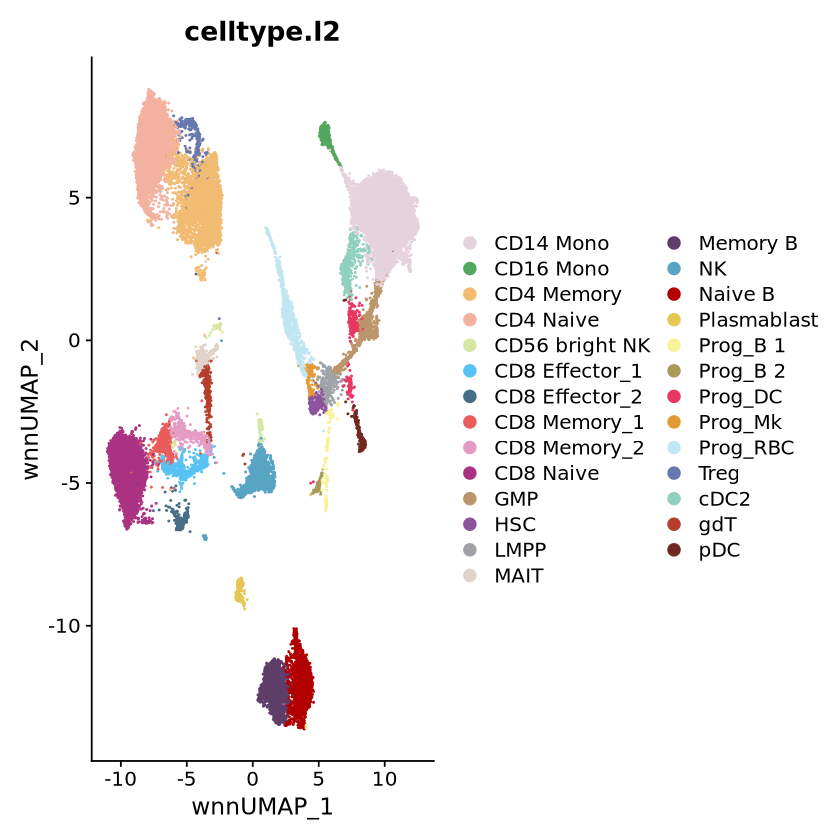

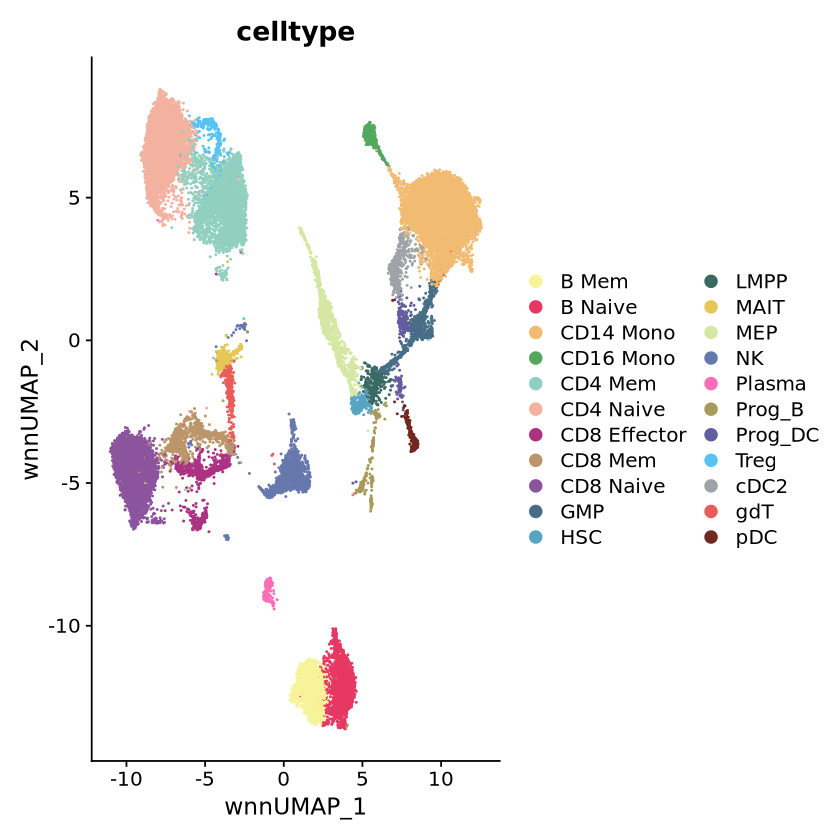

In [4]:
DimPlot(bm,group.by = "celltype.l2",cols = colors)
DimPlot(bm,group.by = "celltype",cols = color.celltypes.bm)



# Metacalls on single cell WNN UMAP

In [6]:
bm.supercell.adt <- readRDS(paste0(datadir,"/output/bmCiteSeq//SuperCellADT/g75/seurat.cite.mc.rds"))
bm.supercell.adt <- addCellType(bm.supercell.adt)

bm.supercell.rna <- readRDS(paste0(datadir,"/output/bmCiteSeq/SuperCellRNA//g75/seurat.cite.mc.rds"))
bm.supercell.rna <- addCellType(bm.supercell.rna)

bm.supercell.multi <- readRDS(paste0(datadir,"/output/bmCiteSeq//SuperCellMulti//g75/seurat.cite.mc.rds"))
bm.supercell.multi <- addCellType(bm.supercell.multi)


## SEACells
bm.seacells.adt <- readRDS(paste0(datadir,"/output/bmCiteSeq/seacellsADT//g75/seurat.cite.mc.rds"))
bm.seacells.adt <- addCellType(bm.seacells.adt)

bm.seacells.rna <- readRDS(paste0(datadir,"/output/bmCiteSeq/seacellsRNA//g75/seurat.cite.mc.rds"))
bm.seacells.rna <- addCellType(bm.seacells.rna)


bm.seacells.mofa <- readRDS(paste0(datadir,"/output/bmCiteSeq/seacellsMOFA/g75/seurat.cite.mc.rds"))
bm.seacells.mofa <- addCellType(bm.seacells.mofa)

## MetaQ
bm.metaq.adt <- readRDS(paste0(datadir,"/output/bmCiteSeq/metaqADT/g75/seurat.cite.mc.rds"))
bm.metaq.adt <- addCellType(bm.metaq.adt)

bm.metaq.rna <- readRDS(paste0(datadir,"/output/bmCiteSeq/metaqRNA//g75/seurat.cite.mc.rds"))
bm.metaq.rna <- addCellType(bm.metaq.rna)


bm.metaq.multi <- readRDS(paste0(datadir,"/output/bmCiteSeq/metaqMulti/g75/seurat.cite.mc.rds"))
bm.metaq.multi <- addCellType(bm.metaq.multi)

## Metacell2


bm.metacell.rna <- readRDS(paste0(datadir,"/output/bmCiteSeq/MetaCellRNA//g75/seurat.cite.mc.rds"))
bm.metacell.rna <- addCellType(bm.metacell.rna)



In [7]:
cn <- c(colnames(bm.supercell.multi@meta.data)[!colnames(bm.supercell.multi@meta.data) %in% c("innerNormVar","celltype")],"input","gamma")
metrics <- data.frame()

for (g in c(20,50,75,100)){
  # for (i in c('SuperCellMulti','SuperCellRNA',"SuperCellADT","randomMetacells","seacellsRNA","seacellsADT","MetaCellRNA")){
  for (i in c('SuperCellMulti','seacellsMOFA','metaqMulti',"SuperCellADT","seacellsADT","metaqADT",'SuperCellRNA',"seacellsRNA","metaqRNA","MetaCellRNA")){  
    file <- paste0(datadir,"/output/bmCiteSeq/",
                   i,"/g",
                   g,
                   "/seurat.cite.mc.rds")
    if (file.exists(file)) {
      pbmc.mc <- readRDS(file)
      if (i == '') {i <- "MULTI"}
      pbmc.mc@meta.data$input <- i
      pbmc.mc@meta.data$gamma <- g
      metrics <- rbind(metrics,pbmc.mc@meta.data[,cn])
    }
  }
  
  
}

Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
17:47:23 UMAP embedding parameters a = 0.9922 b = 1.112

17:47:24 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 20

17:47:25 Initializing from normalized Laplacian + noise (using RSpectra)

17:47:28 Commencing optimization for 200 epochs, with 1017390 positive edges

17:47:28 Using rng type: pcg

17:47:54 Optimization finished

Warning message:
“No assay specified, setting assay as RNA by default.”
Warning message:
“No assay specified, setting ass

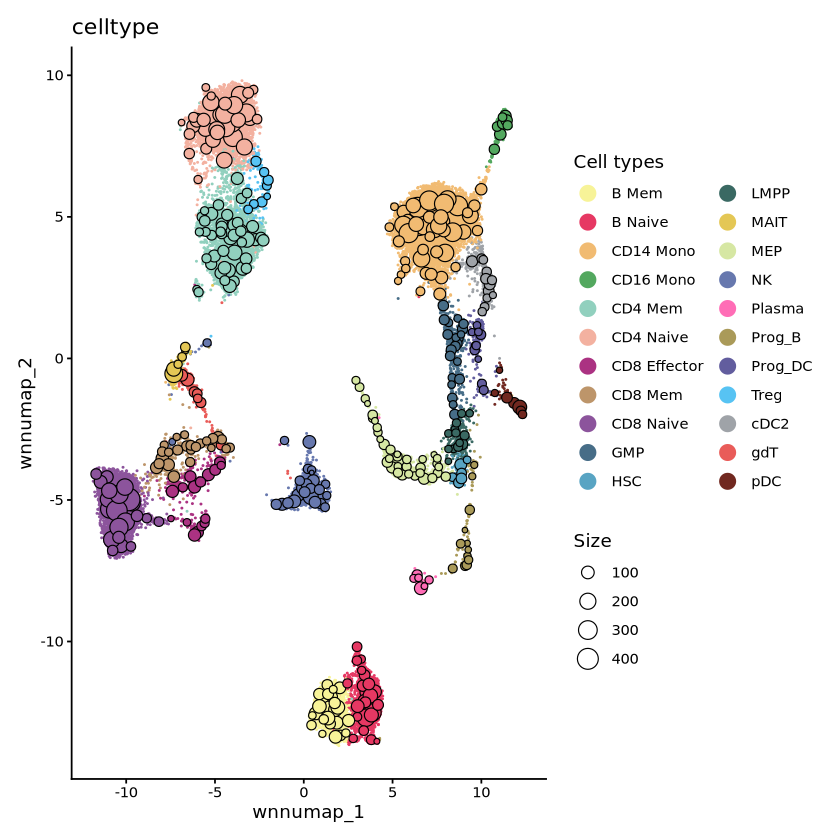

In [10]:

fig1.A <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = bm,
  sobj.mc = bm.supercell.multi,
  dimred_1 = "pca",
  dimred_2= "apca",
  dims.list = list(1:30, 1:18),
  cols = color.celltypes.bm,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic()  +
  guides(colour=guide_legend(ncol =2,title = "Cell types",
                             override.aes = list(size=4)),
         size = guide_legend(title = "Size"))

fig1.A

In [11]:


## SuperCell2.0

umap.sc.multi <-  fig1.A + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 

# legend.celltypes <- ggpubr::get_legend(fig1.A+scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
#                                                          breaks = c(50,100,200,400)),
#                                        position  = c(0.5,0)) 

umap.sc.rna <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = bm,
  sobj.mc = bm.supercell.rna,
  dimred_1 = "pca",
  dimred_2= "apca",
  dims.list = list(1:30, 1:18),
  cols = color.celltypes.bm,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 


umap.sc.adt <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = bm,
  sobj.mc = bm.supercell.adt,
  dimred_1 = "pca",
  dimred_2= "apca",
  dims.list = list(1:30, 1:18),
  cols = color.celltypes.bm,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 


## SEACells

umap.sea.rna <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = bm,
  sobj.mc = bm.seacells.rna,
  dimred_1 = "pca",
  dimred_2= "apca",
  dims.list = list(1:30, 1:18),
  cols = color.celltypes.bm,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 

umap.sea.adt <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = bm,
  sobj.mc = bm.seacells.adt,
  dimred_1 = "pca",
  dimred_2= "apca",
  dims.list = list(1:30, 1:18),
  cols = color.celltypes.bm,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 

umap.sea.mofa <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = bm,
  sobj.mc = bm.seacells.mofa,
  dimred_1 = "pca",
  dimred_2= "apca",
  dims.list = list(1:30, 1:18),
  cols = color.celltypes.bm,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 


## MetaQ

umap.metaq.rna <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = bm,
  sobj.mc = bm.metaq.rna,
  dimred_1 = "pca",
  dimred_2= "apca",
  dims.list = list(1:30, 1:18),
  cols = color.celltypes.bm,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic() + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 

umap.metaq.adt <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = bm,
  sobj.mc = bm.metaq.adt,
  dimred_1 = "pca",
  dimred_2= "apca",
  dims.list = list(1:30, 1:18),
  cols = color.celltypes.bm,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic() + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 

umap.metaq.multi <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = bm,
  sobj.mc = bm.metaq.multi,
  dimred_1 = "pca",
  dimred_2= "apca",
  dims.list = list(1:30, 1:18),
  cols = color.celltypes.bm,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 




umap.mc.rna <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = bm,
  sobj.mc = bm.metacell.rna,
  dimred_1 = "pca",
  dimred_2= "apca",
  dims.list = list(1:30, 1:18),
  cols = color.celltypes.bm,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 

blank <- element_blank()

Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph

17:50:02 UMAP embedding parameters a = 0.9922 b = 1.112

17:50:02 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 20

17:50:04 Initializing from normalized Laplacian + noise (using RSpectra)

17:50:06 Commencing optimization for 200 epochs, with 1017102 positive edges

17:50:06 Using rng type: pcg

17:50:33 Optimization finished

Warning message:
“No assay specified, setting assay as RNA by default.”
Warning message:
“No assay specified, setting assay as RNA by default.”
Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph

17:52:39 UMAP embedding parameters a = 

In [ ]:
#save.image("./draft_review_fig2_bm.Rdata")
# fig1.A$layers[[1]] <- NULL
# fig1.A

In [12]:
c(0,max(metrics$size[metrics$gamma == 75]))

[1]    0 7769

In [13]:
umap.sc <- DimPlot(bm,group.by = "celltype",cols = color.celltypes.bm,reduction = "wnn.umap") + theme_classic() + ggtitle("Single cells") + NoLegend()
# umap.sc

## Supplementary fig1F

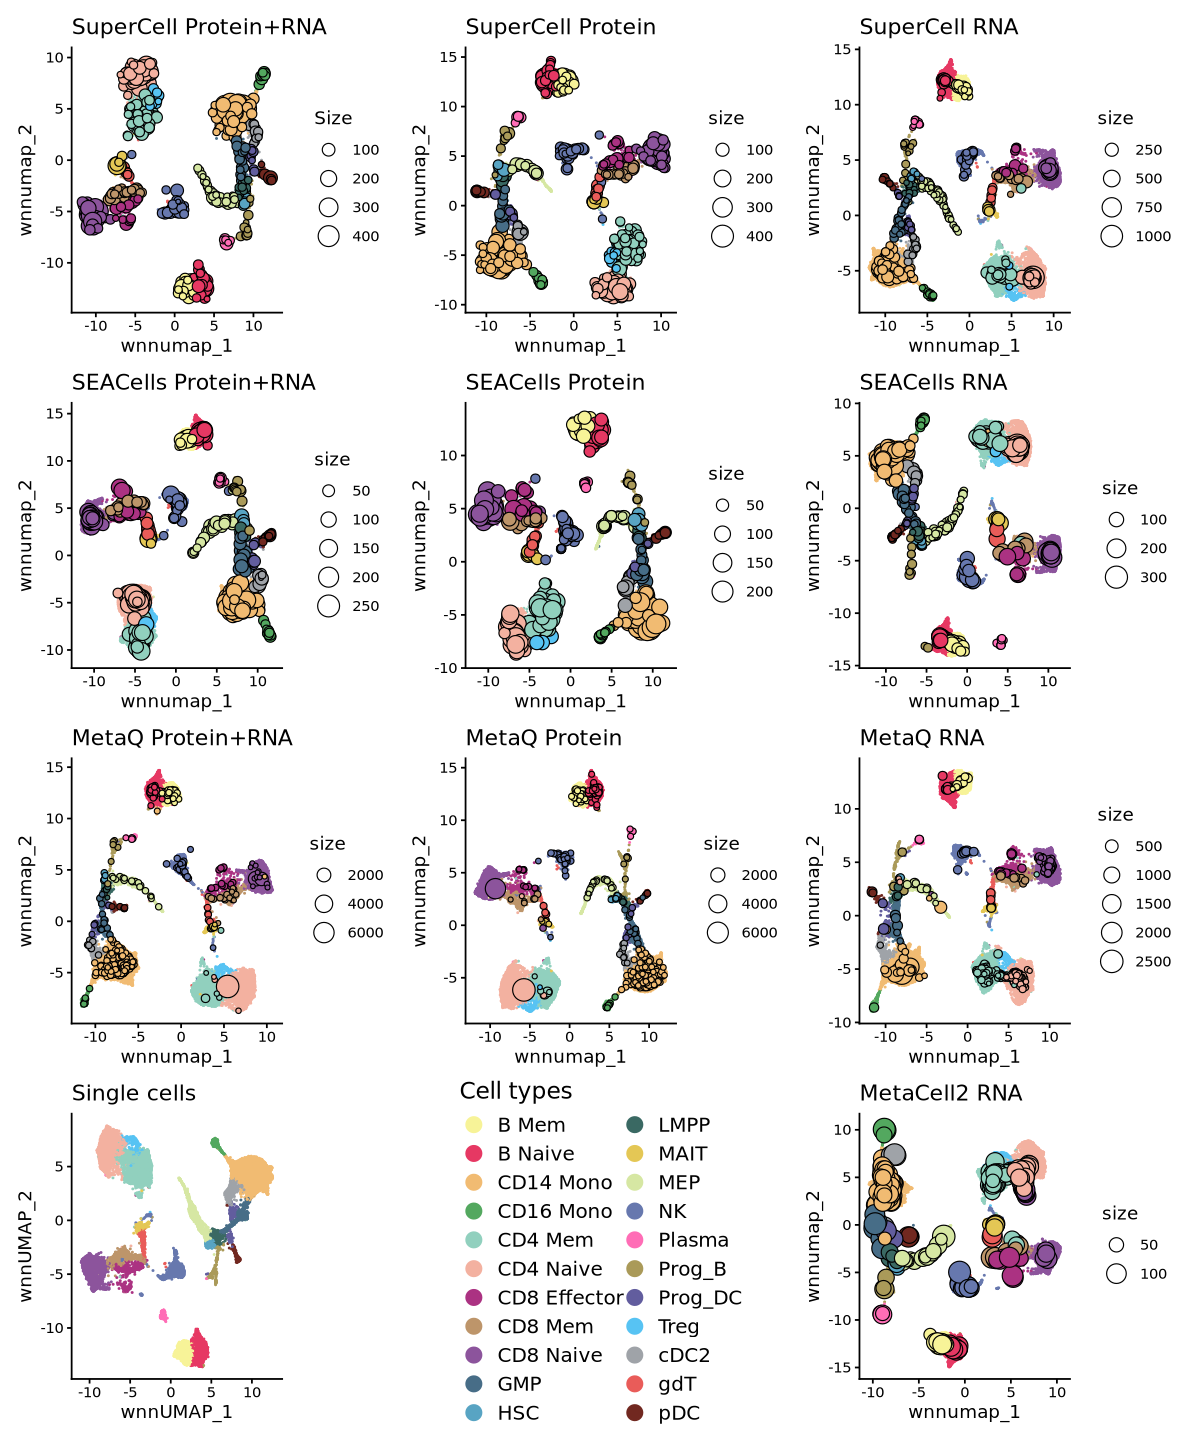

In [16]:
options(repr.plot.width=10, repr.plot.height=12)

legend.celltypes <- cowplot::get_legend(fig1.A +guides(
  colour = guide_legend(ncol =2,title = "Cell types",
                        override.aes = list(size=4)),
  size = "none")+ theme(legend.text = element_text(size=12),
                        legend.title = element_text(size=14))
)

figS2A <-  wrap_plots(umap.sc.multi + ggtitle("SuperCell Protein+RNA"),
                      umap.sc.adt + ggtitle("SuperCell Protein") ,
                      umap.sc.rna + ggtitle("SuperCell RNA"),
                      umap.sea.mofa + ggtitle("SEACells Protein+RNA"),
                      umap.sea.adt + ggtitle("SEACells Protein"),
                      umap.sea.rna + ggtitle("SEACells RNA"),
                      umap.metaq.multi + ggtitle("MetaQ Protein+RNA"),
                      umap.metaq.adt + ggtitle("MetaQ Protein"),
                      umap.metaq.rna + ggtitle("MetaQ RNA"),
                      umap.sc, legend.celltypes,
                      umap.mc.rna + ggtitle("MetaCell2 RNA"),
                      ncol = 3
)

figS2A 

same scale for all

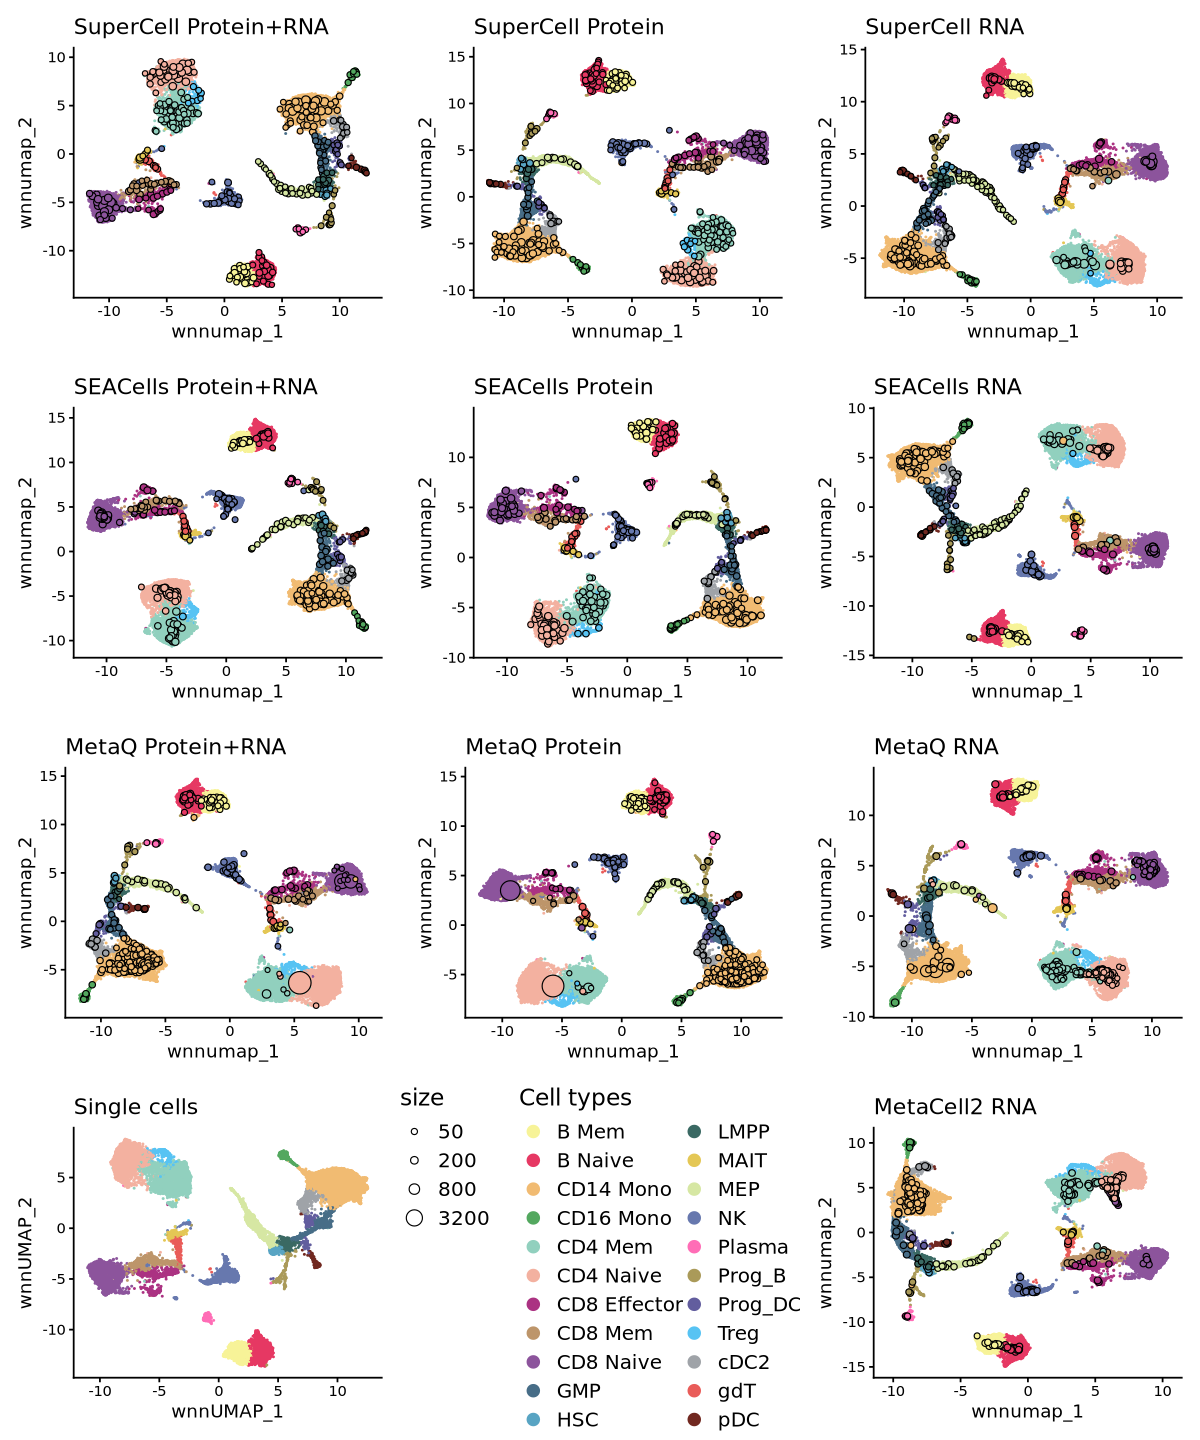

In [17]:
options(repr.plot.width=10, repr.plot.height=12)

legend.celltypes <- cowplot::get_legend(
  fig1.A +
    scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
               breaks = c(50,200,800,3200))  +guides(
                 colour = guide_legend(ncol =2,title = "Cell types",
                                       override.aes = list(size=3)),  # One column for colors
                 size = guide_legend(ncol = 1)
               )+ theme(legend.text = element_text(size=12),
                        legend.title = element_text(size=14),
                        legend.box = "horizontal") # One column for shapes
)

figS2A <-  cowplot::plot_grid(umap.sc.multi + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks = c(50,200,800,3200))+ ggtitle("SuperCell Protein+RNA"),
                              umap.sc.adt  + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks = c(50,200,800,3200)) +
                                ggtitle("SuperCell Protein") ,
                              umap.sc.rna + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks = c(50,200,800,3200)) + ggtitle("SuperCell RNA"),
                              umap.sea.mofa + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks = c(50,200,800,3200)) + ggtitle("SEACells Protein+RNA"),
                              umap.sea.adt + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks = c(50,200,800,3200)) + ggtitle("SEACells Protein"),
                              umap.sea.rna + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks = c(50,200,800,3200)) + ggtitle("SEACells RNA"),
                              umap.metaq.multi + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks = c(50,200,800,3200)) + ggtitle("MetaQ Protein+RNA"),
                              umap.metaq.adt + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks = c(50,200,800,3200)) + ggtitle("MetaQ Protein"),
                              umap.metaq.rna + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks = c(50,200,800,3200)) + ggtitle("MetaQ RNA"),
                              umap.sc,legend.celltypes,
                              umap.mc.rna + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks = c(50,200,800,3200)) + ggtitle("MetaCell2 RNA"),
                              ncol = 3
)

figS2A 

In [ ]:
# umap.sc <- DimPlot(pbmc,group.by = "celltype",cols = color.celltypes.pbmc,reduction = "wnn.umap") + theme_classic() + ggtitle("Single cells") + NoLegend()
# umap.sc

# umap.sc <- umap.sc.multi
# umap.sc$layers[[2]] <- NULL
# 
# legend.celltypes <- ggpubr::get_legend(fig1.A +scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
#                                                           breaks = c(50,100,200,400)) + theme(
#                                                             # legend.position = "bottom",        # Position legend at the bottom
#                                                             legend.box = "horizontal"# One column for shapes
#                                                           ) +guides(
#                                                             fill = guide_legend(ncol =2,title = "Cell types",
#                                                                                 override.aes = list(size=4)),  # One column for colors
#                                                             size = guide_legend(ncol = 1)
#                                                           ))
# 
# figS2A <- cowplot::plot_grid(umap.sc.multi + ggtitle("SuperCell Protein+RNA"),
#                              umap.sc.adt + ggtitle("SuperCell Protein") ,
#                              umap.sc.rna + ggtitle("SuperCell RNA"),
#                              umap.sc + ggtitle("Single-cells"),
#                              umap.sea.adt + ggtitle("SEACells Protein"), 
#                              umap.sea.rna + ggtitle("SEACells RNA"),
#                              legend.celltypes,blank,
#                              umap.mc.rna + ggtitle("MetaCell2 RNA")
# )
# figS2A

In [18]:
dir.create("../../../pdf_files/FigS2/", recursive = T, showWarnings = F )
pdf(file = "../../../pdf_files/FigS2/figS2A_bm_sup_coembeddings.pdf",height = 12,width=10)
figS2A
dev.off()

agg_record_368585943 
                   2

## Fig 2A benchmark plot

set method color

In [19]:
library(scales)
# library(ggthemes)

input.colors.cite <- c("#E69F00","#56B4E9","#009E73","darkgrey") #colorblind_pal()(8)[2:4]


names(input.colors.cite) <- c("Protein","Protein+RNA","RNA","None")

In [20]:
#Set compactness to 0 (best score) for metacell of size 1
table(metrics[is.na(metrics$compactness_apca),"gamma"])
table(metrics[is.na(metrics$compactness_pca),"input"])


#metrics$compactness_lsi[is.na(metrics$compactness_lsi)] <- 0

#metrics$compactness_pca[is.na(metrics$compactness_pca)] <- 0


metrics$gamma <- factor(as.character(metrics$gamma),levels =c(20,50,75,100))

metrics$method <- plyr::mapvalues(x= metrics$input, 
                                  from = c('SuperCellMulti',"seacellsMOFA","metaqMulti","SuperCellADT","seacellsADT","metaqADT",'SuperCellRNA',"seacellsRNA","metaqRNA","MetaCellRNA","randomMetacells"),
                                  to = c('SuperCell Protein+RNA',"SEACells Protein+RNA","MetaQ Protein+RNA",
                                         "SuperCell Protein","SEACells Protein","MetaQ Protein",
                                         'SuperCell RNA',"SEACells RNA","MetaQ RNA","MetaCell2 RNA","Random None"))

metrics$tool <- stringr::str_split_fixed(metrics$method,pattern = " ",n = 2)[,1]
metrics$input <- stringr::str_split_fixed(metrics$method,pattern = " ",n = 2)[,2]


metrics$input <- factor(as.character(metrics$input),levels = c("RNA","Protein","Protein+RNA","None"))

method.levels <- c('SuperCell Protein+RNA',"SEACells Protein+RNA","MetaQ Protein+RNA",
                   "SuperCell Protein","SEACells Protein","MetaQ Protein",
                   'SuperCell RNA',"SEACells RNA","MetaQ RNA","MetaCell2 RNA","Random None")

metrics$method <- factor(metrics$method,
                         levels = method.levels)
# 


 20  50  75 100 
189  22  16  11 


  SuperCellADT SuperCellMulti   SuperCellRNA       metaqADT     metaqMulti 
             2             14             11             61             57 
      metaqRNA    seacellsADT   seacellsMOFA    seacellsRNA 
            12             24             25             32 

The following `from` values were not present in `x`: randomMetacells



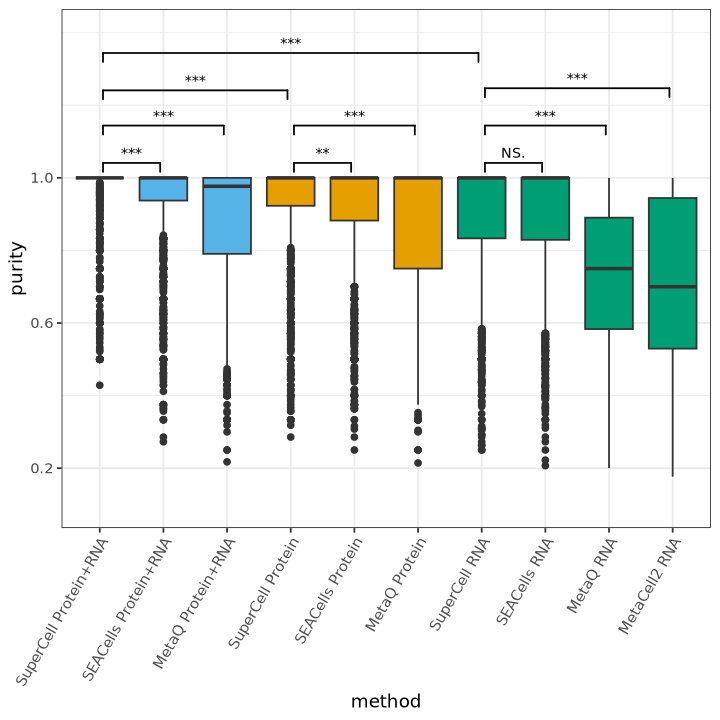

In [27]:
options(repr.plot.width=6, repr.plot.height=6)

comparisons.multi <- list(
  c('SuperCell Protein+RNA',"SEACells Protein+RNA"),
  c('SuperCell Protein+RNA','MetaQ Protein+RNA'))

comparisons.protein <- list(c('SuperCell Protein',"SEACells Protein"),
                            c('SuperCell Protein','MetaQ Protein'))

comparisons.rna <- list(c('SuperCell RNA',"SEACells RNA"),
                        c('SuperCell RNA','MetaQ RNA'),
                        c('SuperCell RNA','MetaCell2 RNA'))

comparison.inter.modality <- list(c('SuperCell Protein+RNA',"SuperCell Protein"),
                                  c('SuperCell Protein+RNA','SuperCell RNA')
)

library(ggsignif)
metrics$purity <- metrics$celltype.l2_purity
purity.bmc.cite.g20 <- ggplot(metrics[metrics$gamma %in% c(20),],aes(y=purity,x = method,fill = input)) +
  geom_boxplot() + theme_bw() +
  #facet_wrap("gamma",nrow = 1) + 
  scale_y_continuous(limits = c(0.1,1.4),breaks = c(0.2,0.6,1)) + 
  geom_signif(comparisons = comparisons.multi,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.protein,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.rna,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparison.inter.modality,y_position =1.2, ,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  scale_x_discrete(guide = guide_axis(angle = 60)) + 
  theme(legend.position = "bottom") + scale_fill_manual(values = input.colors.cite)

purity.bmc.cite.g20 + NoLegend()

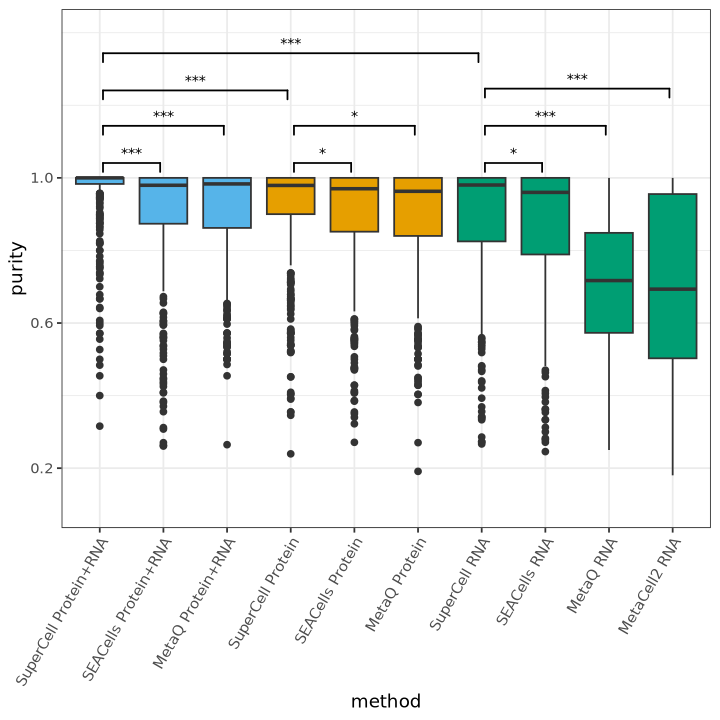

In [28]:
options(repr.plot.width=6, repr.plot.height=6)

purity.bmc.cite.g75 <- ggplot(metrics[metrics$gamma %in% c(75),],aes(y=purity,x = method,fill = input)) + 
  geom_boxplot() + theme_bw() +
  #facet_wrap("gamma",nrow = 1) + 
  scale_y_continuous(limits = c(0.1,1.4),breaks = c(0.2,0.6,1)) +
  geom_signif(comparisons = comparisons.multi,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.protein,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.rna,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparison.inter.modality,y_position =1.2, ,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  scale_x_discrete(guide = guide_axis(angle = 60)) + 
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite)


purity.bmc.cite.g75 + NoLegend()

In [ ]:
# #load(file ="draft_review_fig2_bm.Rdata")

# 
# comp <- c("SuperCell Protein+RNA", "SEACells Protein+RNA")
# run_a <- metrics[metrics$gamma %in% c(75)&metrics$method == comp[1],]$purity
# run_b <- metrics[metrics$gamma %in% c(75)&metrics$method == comp[2],]$purity
# wilcox.test(x=run_b,y=run_a)
# 
# library(effectsize)
# 
# res <- rank_biserial(x=run_b,y=run_a)
# 
# res$r_rank_biserial

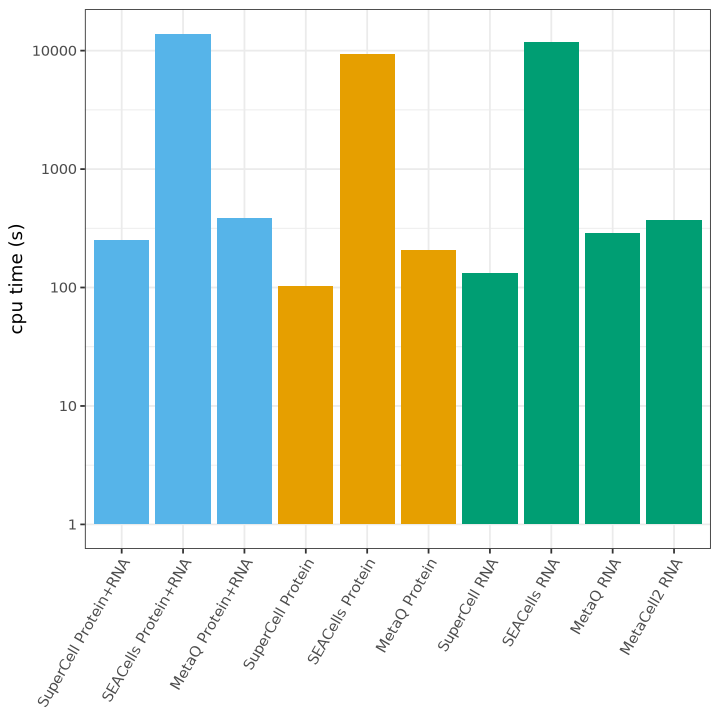

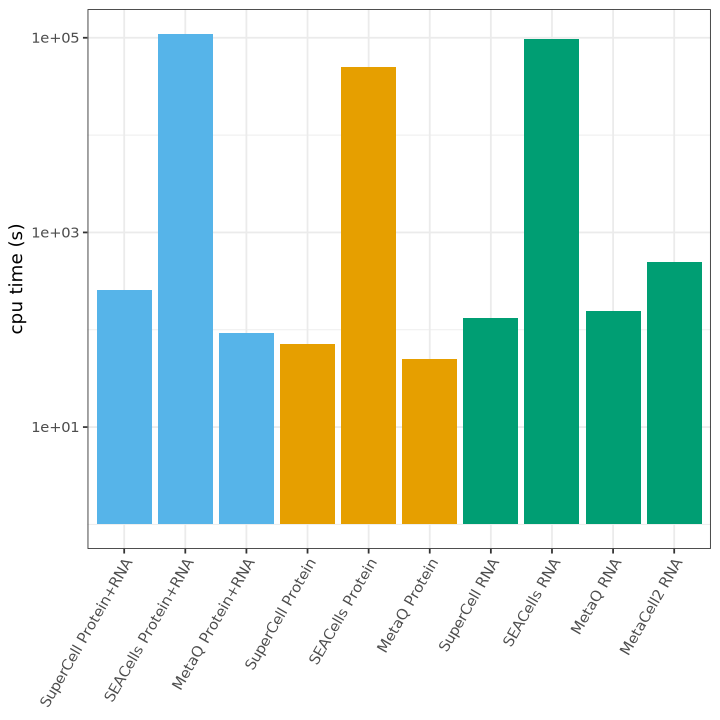

In [29]:
use.gamma = c(20,75) 

benchTable <- data.frame()
methodToBenchFiles <- c('seurat.cite.mc.txt','seurat.cite.mc.txt','seurat.cite.mc.txt',
                        'seacellMemberships.txt','seacellMemberships.txt',"seacellMemberships.txt",
                        "metaqMemberships.txt","metaqMemberships.txt","metaqMemberships.txt",
                        "MetaCellMemberships.txt")
methodToTools <- c('SuperCell','SuperCell','SuperCell',
                   "SEACells",'SEACells',"SEACells",
                   "MetaQ","MetaQ","MetaQ",
                   "MetaCell")
names(methodToBenchFiles) <- c('SuperCellMulti','SuperCellADT',"SuperCellRNA",
                               "seacellsMOFA","seacellsADT","seacellsRNA",
                               "metaqMulti","metaqADT","metaqRNA",
                               "MetaCellRNA")

for (g in c(use.gamma)){
  for (i in names(methodToBenchFiles) ){
    bench <- read.table(paste0(datadir,"/benchmark/bmCiteSeq/",
                               i,"/g",
                               g,"/",
                               "/benchIdentification.txt"),
                        sep = "\t",header = T)
    
    bench$method <- i
    bench$gamma <- g
    benchTable <- rbind(benchTable,bench)
    
  }}

# ggplot(benchTable,aes(x = method,y = cpu_time, fill= method)) + geom_bar(stat = "identity") +
#   scale_x_discrete(guide = guide_axis(angle = 60))+ ylab("cpu time (s)")+ NoLegend() +
#   ggplot(benchTable,aes(x = method,y = max_pss/1024, fill= method)) + geom_bar(stat = "identity") + ylab("memory (GB)") +
#   scale_x_discrete(guide = guide_axis(angle = 60))
# 
# 
#  +
#   ggplot(benchTable,aes(x = method,y = s, fill= method)) + geom_bar(stat = "identity") +
#   scale_x_discrete(guide = guide_axis(angle = 60))+ ylab("Runtime (s)")+ NoLegend()

benchTable$gamma <- factor(benchTable$gamma)
#benchTable <-  rbind(benchTable,c(rep(1,10),"Random","20"))
#benchTable <-  rbind(benchTable,c(rep(1,10),"Random","75"))

benchTable$method <- plyr::mapvalues(x= benchTable$method, 
                                     from = c('SuperCellMulti','SuperCellRNA',"SuperCellADT",
                                              #"Random",
                                              "seacellsMOFA","seacellsRNA","seacellsADT",
                                              "metaqMulti","metaqRNA","metaqADT",
                                              "MetaCellRNA"),
                                     to = c('SuperCell Protein+RNA','SuperCell RNA',"SuperCell Protein",
                                            #"Random None",
                                            "SEACells Protein+RNA","SEACells RNA","SEACells Protein",
                                            "MetaQ Protein+RNA","MetaQ RNA", "MetaQ Protein",
                                            "MetaCell2 RNA"))

benchTable$input <- stringr::str_split_fixed(benchTable$method,pattern = " ",n=2)[,2]

benchTable$input <- factor(as.character(benchTable$input),levels = c('Protein+RNA',"Protein","RNA"))


benchTable$method <- factor(benchTable$method,
                            levels = method.levels)

benchTable$cpu_time <- as.numeric(benchTable$cpu_time )


cpu.time.plot.g75 <- ggplot(benchTable[benchTable$gamma == 75 & benchTable$method != "Random None",],aes(x = method,y = cpu_time,fill = input)) + 
  geom_bar(stat = "identity", position="dodge") + theme_bw() +
  scale_x_discrete(guide = guide_axis(angle = 60)) + scale_y_log10()  +
  ylab("cpu time (s)") + 
  scale_fill_manual(values = input.colors.cite) + theme(axis.title.x = element_blank())


cpu.time.plot.g20 <- ggplot(benchTable[ benchTable$gamma == 20 & benchTable$method != "Random None",],aes(x = method,y = cpu_time,fill = input)) + 
  geom_bar(stat = "identity", position="dodge") + theme_bw() +
  scale_x_discrete(guide = guide_axis(angle = 60)) + scale_y_log10()   +
  ylab("cpu time (s)") + 
  scale_fill_manual(values = input.colors.cite)+ theme(axis.title.x = element_blank())

# cpu.time.plot <- ggplot(benchTable[benchTable$method != "Random None" & g == 75,],aes(x = method,y = cpu_time,fill = input)) + 
#   geom_bar(stat = "identity", position="dodge") +
#   scale_x_discrete(guide = guide_axis(angle = 60)) +
#   ylab("cpu time (s)") + 
#   theme(legend.position = c(0.8,0.6),
#         axis.title.x = element_blank(),
#         axis.text.x = element_blank()) + 
#   scale_fill_manual(values = input.colors.cite)

cpu.time.plot.g75 + NoLegend()

cpu.time.plot.g20 + NoLegend()


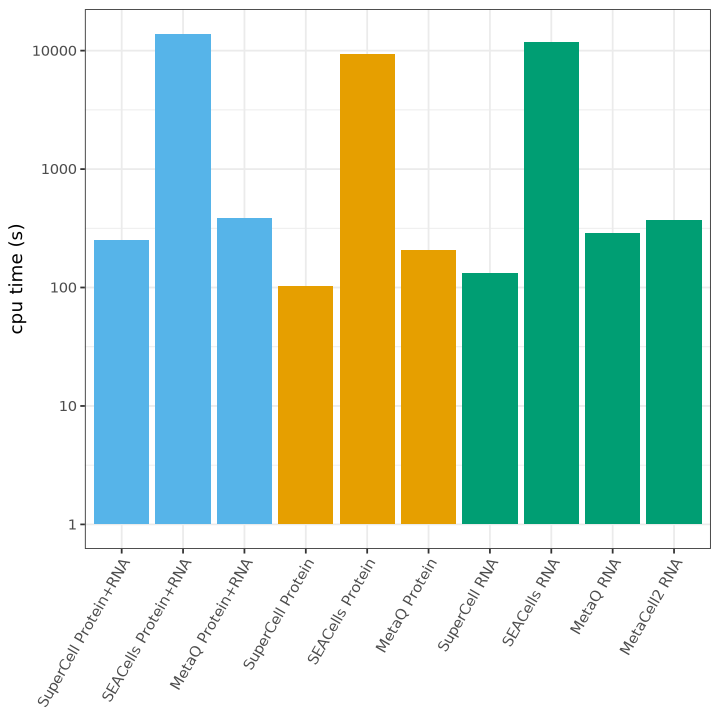

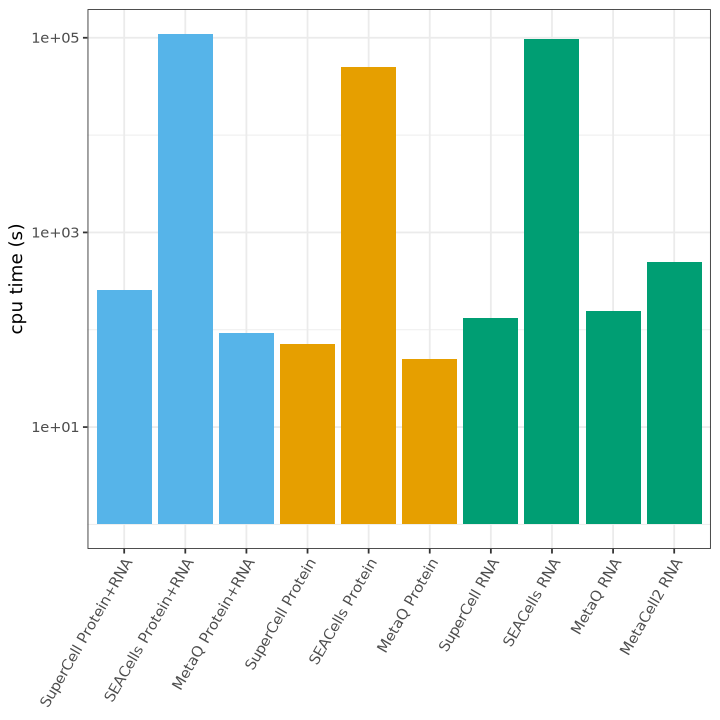

In [30]:


cpu.time.plot.g75 <- ggplot(benchTable[benchTable$gamma == 75 & benchTable$method != "Random None",],aes(x = method,y = cpu_time,fill = input)) + 
  geom_bar(stat = "identity", position="dodge") + theme_bw() +
  scale_x_discrete(guide = guide_axis(angle = 60)) + scale_y_log10()  +
  ylab("cpu time (s)") + 
  scale_fill_manual(values = input.colors.cite) + theme(axis.title.x = element_blank())


cpu.time.plot.g20 <- ggplot(benchTable[ benchTable$gamma == 20 & benchTable$method != "Random None",],aes(x = method,y = cpu_time,fill = input)) + 
  geom_bar(stat = "identity", position="dodge") + theme_bw() +
  scale_x_discrete(guide = guide_axis(angle = 60)) + scale_y_log10()   +
  ylab("cpu time (s)") + 
  scale_fill_manual(values = input.colors.cite)+ theme(axis.title.x = element_blank())



cpu.time.plot.g75 + NoLegend()

cpu.time.plot.g20 + NoLegend()

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


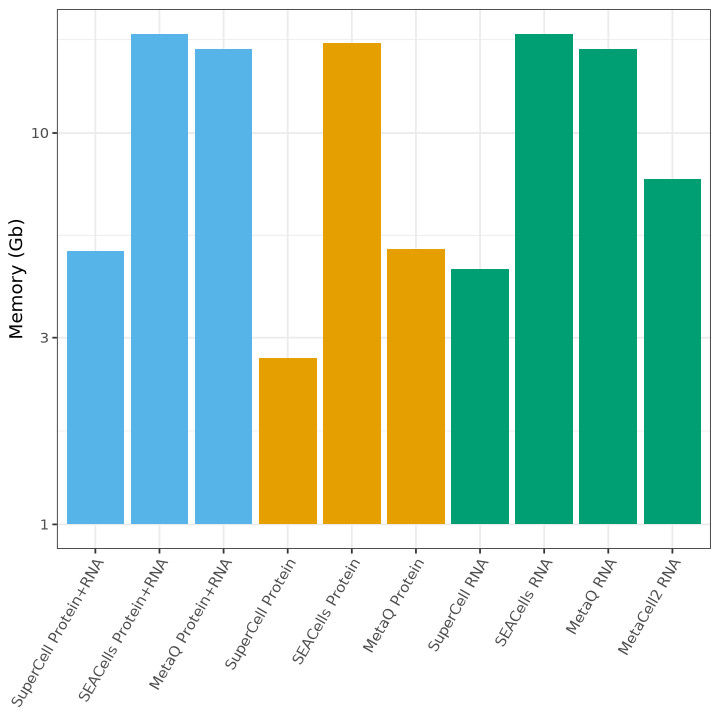

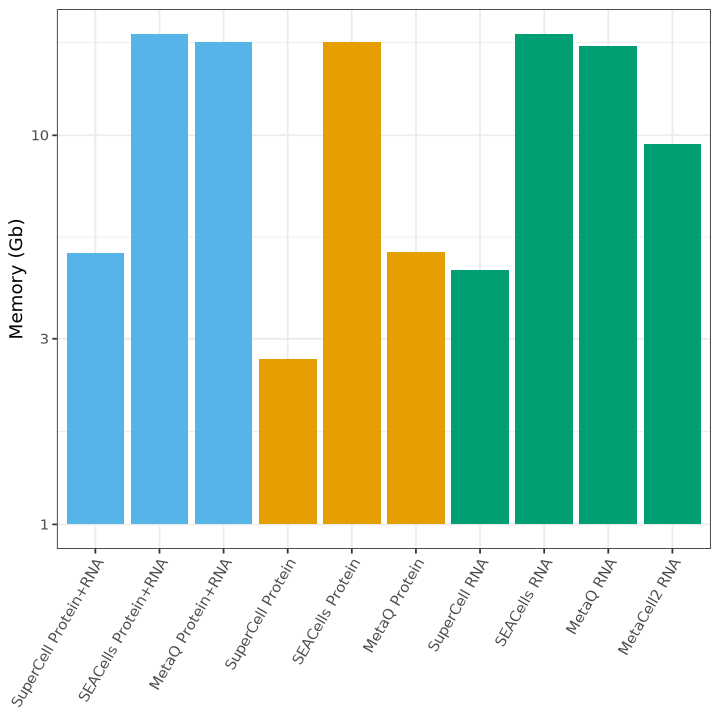

In [31]:


mem.plot.g75 <- ggplot(benchTable[benchTable$gamma == 75 & benchTable$method != "Random None",],aes(x = method,y = as.numeric(max_rss)/1024,fill = input)) + 
  geom_bar(stat = "identity", position="dodge") + theme_bw() +
  scale_x_discrete(guide = guide_axis(angle = 60)) + scale_y_log10()  +
  ylab("Memory (Gb)") + 
  scale_fill_manual(values = input.colors.cite) + theme(axis.title.x = element_blank())


mem.plot.g20 <- ggplot(benchTable[ benchTable$gamma == 20 & benchTable$method != "Random None",],aes(x = method,y = as.numeric(max_rss)/1024,fill = input)) + 
  geom_bar(stat = "identity", position="dodge") + theme_bw() +
  scale_x_discrete(guide = guide_axis(angle = 60)) + scale_y_log10()   +
  ylab("Memory (Gb)") + 
  scale_fill_manual(values = input.colors.cite) + 
  scale_fill_manual(values = input.colors.cite)+ theme(axis.title.x = element_blank())


mem.plot.g75 + NoLegend()

mem.plot.g20 + NoLegend()

## With preprocessing

In [33]:
use.gamma = c(20,75) 

benchTable <- data.frame()
benchTable2 <- data.frame()


methodToBenchFiles <- c('benchIdentification.txt','benchIdentification.txt','benchIdentification.txt',
                        'benchIdentification.txt',"benchIdentification.txt","benchIdentification.txt",
                        'benchIdentification.txt',"benchIdentification.txt","benchIdentification.txt",
                        'benchIdentification.txt')
methodToTools <- c('SuperCell','SuperCell','SuperCell','SEACells','SEACells',"SEACells",
                   "MetaQ","MetaQ","MetaQ",
                   "MetaCell")
names(methodToBenchFiles) <- c('SuperCellMulti','SuperCellRNA','SuperCellADT',
                               "seacellsMOFA","seacellsADT","seacellsRNA",
                               "metaqMulti","metaqADT","metaqRNA",
                               "MetaCellRNA")

preprocess.bench.rna <- read.table(paste0(datadir,"/benchmark/bmCiteSeq/singlecells_analysis/seurat.RNA.txt"),header = T)

preprocess.bench.adt <- read.table(paste0(datadir,"/benchmark/bmCiteSeq/singlecells_analysis/seurat.ADT.txt"),header = T) 

preprocess.bench.multi <- read.table(paste0(datadir,"/benchmark/bmCiteSeq/singlecells_analysis/seurat_multimodal.txt"),header = T)

## TO DO update with correct bench file for mofa preprocessing
preprocess.bench.mofa <- read.table(paste0(datadir,"/benchmark/bmCiteSeq/singlecells_analysis/seurat_multimodal.txt"),header = T)




for (g in c(use.gamma)){
  for (i in names(methodToBenchFiles) ){
    
    bench <- read.table(paste0(datadir,"/benchmark/bmCiteSeq/",
                               i,"/g",
                               g,"/",
                               methodToBenchFiles[i]),header = T,sep = "\t")
    
    
    bench2 <- bench[c("s","max_rss","max_pss","cpu_time")]
    if (i != "MetaCellRNA" & !startsWith(x=i,prefix = "metaq")) {
      print(i)
      if(endsWith(x = i,suffix = "RNA")) {
        preprocess <- preprocess.bench.rna
      }
      if(endsWith(x = i,suffix = "ADT")) {
        preprocess <- preprocess.bench.adt
      }
      if(endsWith(x = i,suffix = "Multi")) {
        preprocess <- preprocess.bench.multi
      }
      
      if(endsWith(x = i,suffix = "MOFA")) {
        preprocess <- preprocess.bench.mofa
      }
      
      bench2 <- colSums(rbind(bench2[c("s","cpu_time")],
                              preprocess[c("s","cpu_time")]))
      
      bench2$max_rss <- max(unlist(c(bench["max_rss"],preprocess["max_rss"])))
      bench2$max_rss <- max(unlist(c(bench["max_rss"],preprocess["max_rss"])))
    } else {
      bench2 <- bench[c("s","cpu_time","max_rss")]
    }
    bench$method <- i
    bench$gamma <- g
    bench2$method <- i
    bench2$gamma <- g
    
    benchTable <- rbind(benchTable,bench)
    benchTable2 <- rbind(benchTable2,bench2)
    
  }}

getBenchTable <- function(benchTable) {
  benchTable$gamma <- factor(benchTable$gamma)
  # benchTable <-  rbind(benchTable,c(rep(1,10),"Random","20"))
  # benchTable <-  rbind(benchTable,c(rep(1,10),"Random","75"))
  
  benchTable$method <- 
    plyr::mapvalues(x= benchTable$method, 
                    from = c('SuperCellMulti','SuperCellRNA',"SuperCellADT",
                             "seacellsMOFA","seacellsRNA","seacellsADT",
                             "metaqMulti","metaqRNA","metaqADT",
                             "MetaCellRNA"),
                    to = c('SuperCell Protein+RNA','SuperCell RNA',"SuperCell Protein",
                           "SEACells Protein+RNA","SEACells RNA","SEACells Protein",
                           "MetaQ Protein+RNA","MetaQ RNA","MetaQ Protein",
                           "MetaCell2 RNA"))
  
  benchTable$input <- stringr::str_split_fixed(benchTable$method,pattern = " ",n=2)[,2]
  
  benchTable$input <- factor(as.character(benchTable$input),levels = c('Protein+RNA',"Protein","RNA"))
  benchTable$method <- factor(benchTable$method,
                              levels = method.levels)
  
  benchTable$cpu_time <- as.numeric(benchTable$cpu_time )
  benchTable$s <- as.numeric(benchTable$s )
  benchTable$max_rss <- as.numeric(benchTable$max_rss )
  
  return(benchTable)
}

benchTable <- getBenchTable(benchTable)
benchTable2 <- getBenchTable(benchTable2)



cite.cpu.time.plot.g75.id <- ggplot(benchTable[benchTable$gamma == 75,],aes(x = method,y = cpu_time/60,fill = input)) + 
  geom_bar(stat = "identity", position="dodge") + theme_bw() +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("cpu time (min)") +  scale_y_log10() +
  scale_fill_manual(values = input.colors.cite)


cite.run.time.plot.g75.id <- ggplot(benchTable[benchTable$gamma == 75,],aes(x = method,y = s/60,fill = input)) + 
  geom_bar(stat = "identity", position="dodge") + theme_bw() +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("Runtime (min)") + 
  scale_fill_manual(values = input.colors.cite)


cite.cpu.time.plot.g20.id <- ggplot(benchTable[ benchTable$gamma == 20,],aes(x = method,y = cpu_time/60,fill = input)) + 
  geom_bar(stat = "identity", position="dodge") + theme_bw() +
  scale_x_discrete(guide = guide_axis(angle = 60)) + scale_y_log10()   +
  ylab("cpu time (min)") +
  scale_fill_manual(values = input.colors.cite)

cite.run.time.plot.g20.id <- ggplot(benchTable[benchTable$gamma == 20,],aes(x = method,y = s,fill = input)) + 
  geom_bar(stat = "identity", position="dodge") + theme_bw() +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("Runtime (s)") + 
  scale_fill_manual(values = input.colors.cite)




[1] "SuperCellMulti"


Warning message in bench2$max_rss <- max(unlist(c(bench["max_rss"], preprocess["max_rss"]))):
“Coercing LHS to a list”


[1] "SuperCellRNA"


Warning message in bench2$max_rss <- max(unlist(c(bench["max_rss"], preprocess["max_rss"]))):
“Coercing LHS to a list”


[1] "SuperCellADT"


...

Warning message in bench2$max_rss <- max(unlist(c(bench["max_rss"], preprocess["max_rss"]))):
“Coercing LHS to a list”


[1] "seacellsADT"


Warning message in bench2$max_rss <- max(unlist(c(bench["max_rss"], preprocess["max_rss"]))):
“Coercing LHS to a list”


[1] "seacellsRNA"


Warning message in bench2$max_rss <- max(unlist(c(bench["max_rss"], preprocess["max_rss"]))):
“Coercing LHS to a list”


With preprocessing for SuperCell and SEACells

Protein Protein+RNA         RNA        None 
  "#E69F00"   "#56B4E9"   "#009E73"  "darkgrey"

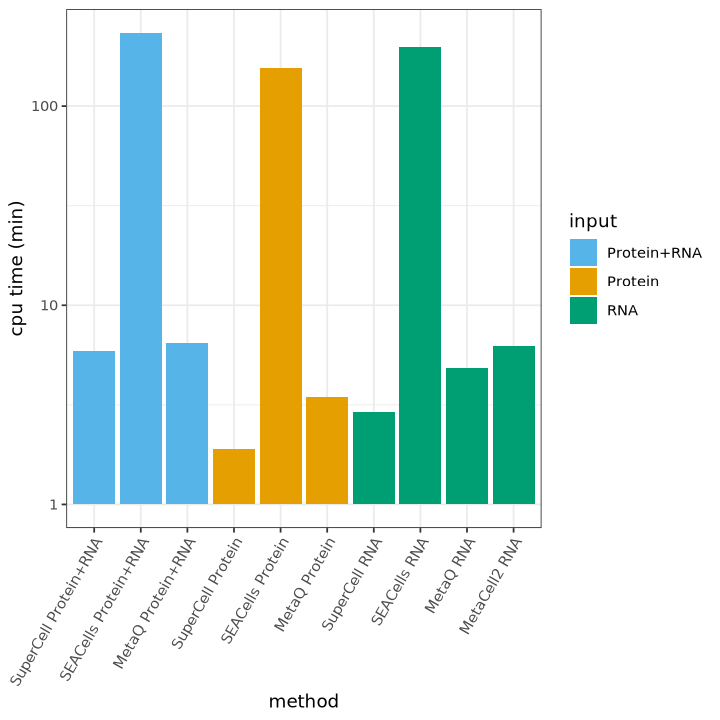

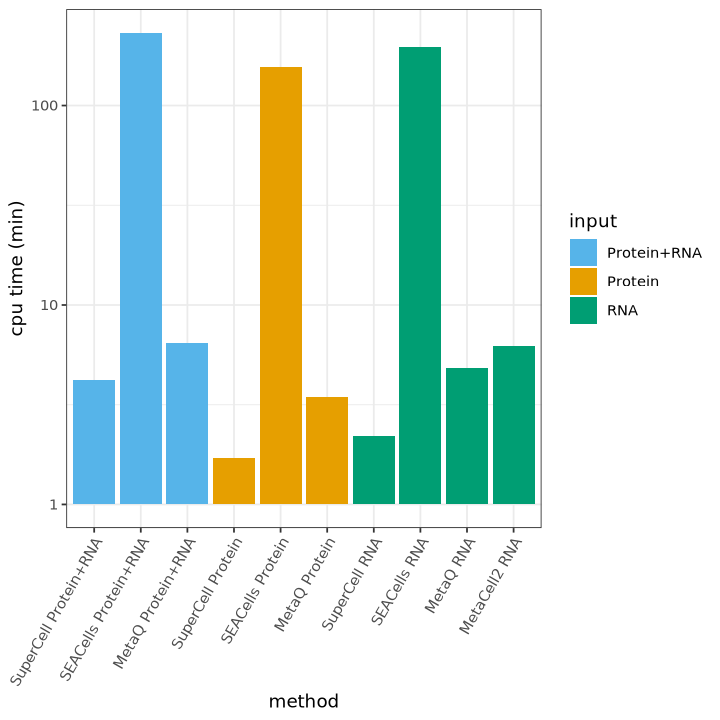

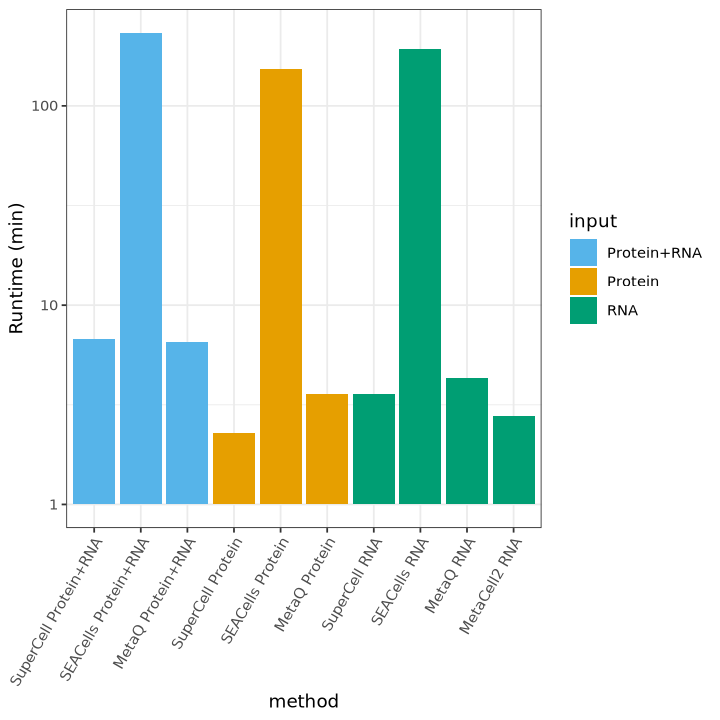

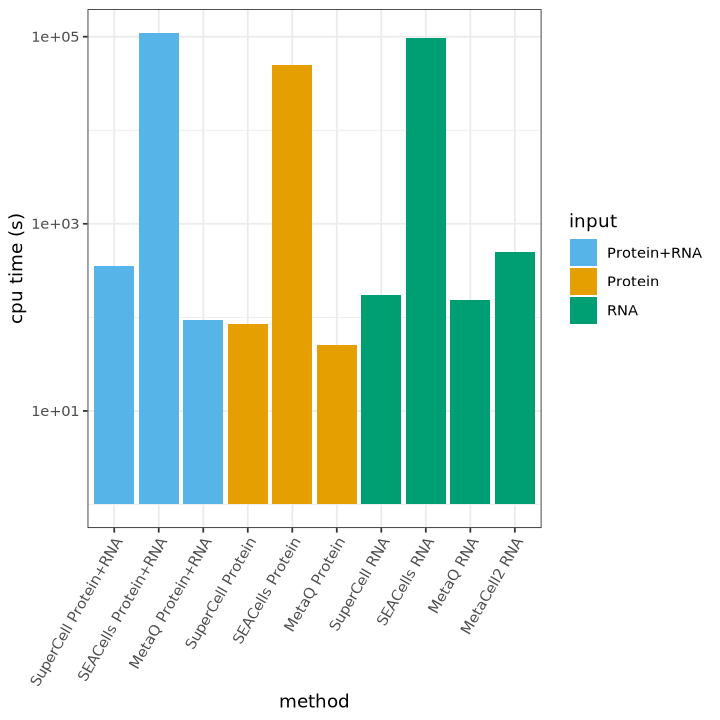

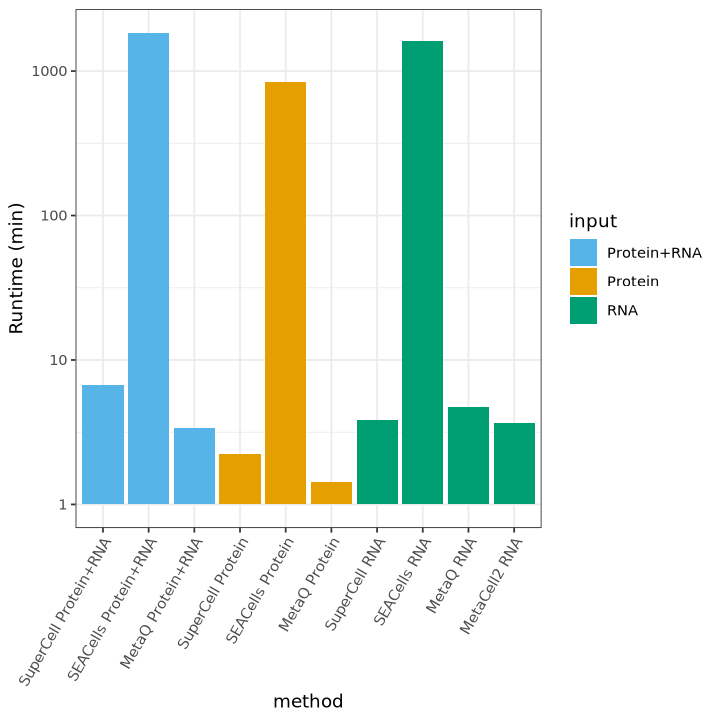

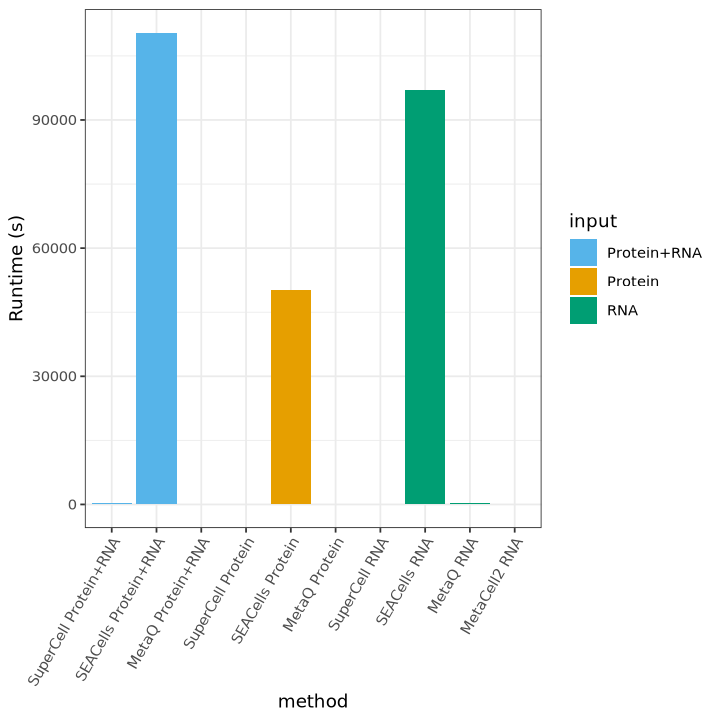

In [34]:
cite.cpu.time.plot.g75 <- ggplot(benchTable2[benchTable2$gamma == 75,],aes(x = method,y = cpu_time/60,fill = input)) + 
  geom_bar(stat = "identity", position="dodge") + theme_bw() +
  scale_x_discrete(guide = guide_axis(angle = 60))  + scale_y_log10()   +
  ylab("cpu time (min)") + 
  scale_fill_manual(values = input.colors.cite)


cite.run.time.plot.g75 <- ggplot(benchTable2[benchTable2$gamma == 75,],aes(x = method,y = s/60,fill = input)) + 
  geom_bar(stat = "identity", position="dodge") + theme_bw() +
  scale_x_discrete(guide = guide_axis(angle = 60))  + scale_y_log10()   +
  ylab("Runtime (min)") + 
  scale_fill_manual(values = input.colors.cite)


cite.cpu.time.plot.g20 <- ggplot(benchTable2[ benchTable2$gamma == 20,],aes(x = method,y = cpu_time,fill = input)) + 
  geom_bar(stat = "identity", position="dodge") + theme_bw() +
  scale_x_discrete(guide = guide_axis(angle = 60)) + scale_y_log10()   +
  ylab("cpu time (s)") + 
  scale_fill_manual(values = input.colors.cite)

cite.run.time.plot.g20 <- ggplot(benchTable2[benchTable2$gamma == 20,],aes(x = method,y = s/60,fill = input)) + 
  geom_bar(stat = "identity", position="dodge") + theme_bw() + scale_y_log10()   +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("Runtime (min)") + 
  scale_fill_manual(values = input.colors.cite)

input.colors.cite

cite.cpu.time.plot.g75
cite.cpu.time.plot.g75.id
cite.run.time.plot.g75

cite.cpu.time.plot.g20
cite.run.time.plot.g20
cite.run.time.plot.g20.id

Memory with preprocessing

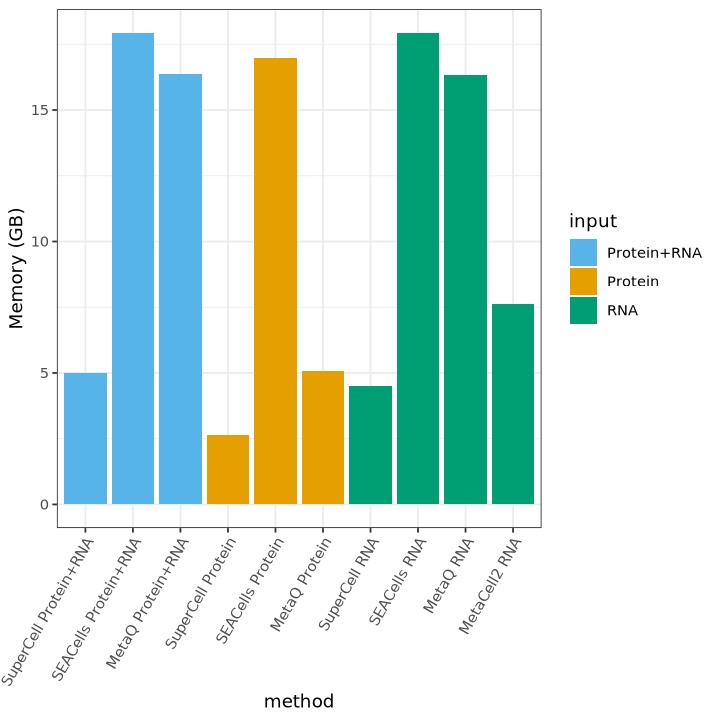

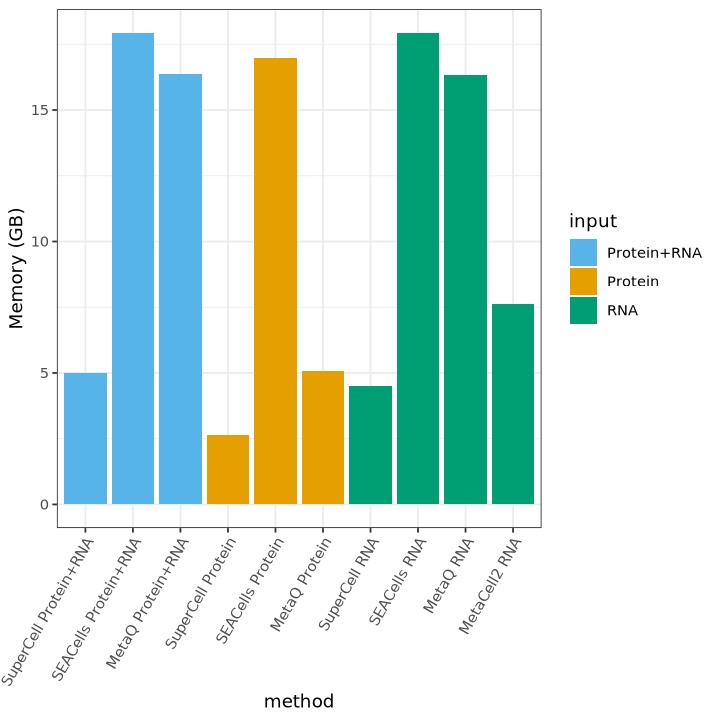

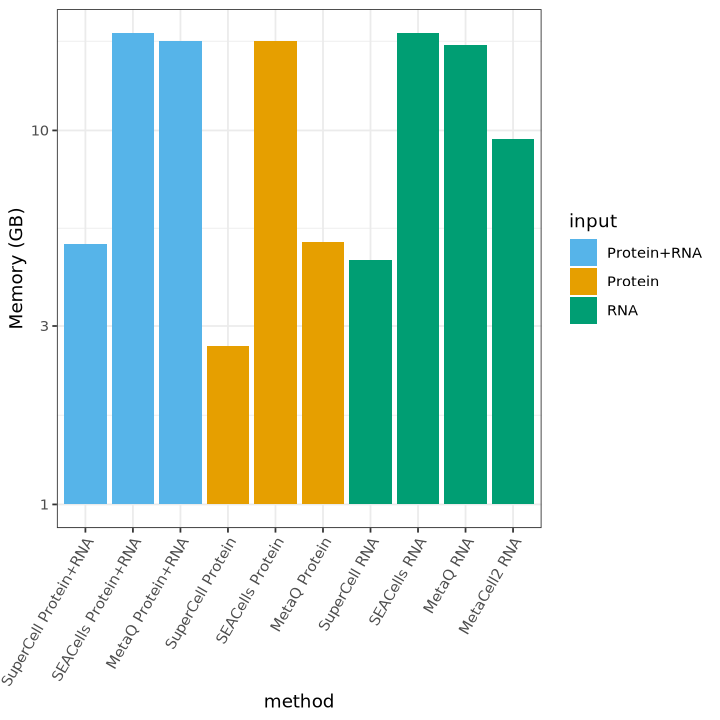

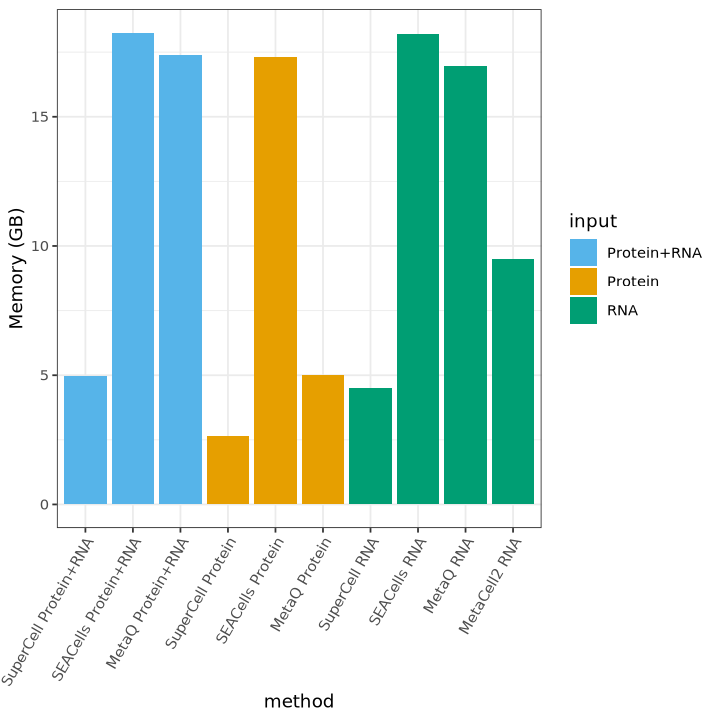

In [35]:
cite.memory.plot.g75 <- ggplot(benchTable2[benchTable2$gamma == 75,],aes(x = method,y = max_rss/1024,fill = input)) + 
  geom_bar(stat = "identity", position="dodge") + theme_bw() +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("Memory (GB)") + 
  scale_fill_manual(values = input.colors.cite)


cite.memory.plot.g75.id <- ggplot(benchTable[benchTable$gamma == 75,],aes(x = method,y = max_rss/1024,fill = input)) + 
  geom_bar(stat = "identity", position="dodge") + theme_bw() +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("Memory (GB)") + 
  scale_fill_manual(values = input.colors.cite)


cite.memory.plot.g20 <- ggplot(benchTable2[ benchTable2$gamma == 20,],aes(x = method,y = max_rss/1024,fill = input)) + 
  geom_bar(stat = "identity", position="dodge") + theme_bw() +
  scale_x_discrete(guide = guide_axis(angle = 60)) + scale_y_log10()   +
  ylab("Memory (GB)") + 
  scale_fill_manual(values = input.colors.cite)

cite.memory.plot.g20.id <- ggplot(benchTable[benchTable$gamma == 20,],aes(x = method,y = max_rss/1024,fill = input)) + 
  geom_bar(stat = "identity", position="dodge") + theme_bw() +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("Memory (GB)") + 
  scale_fill_manual(values = input.colors.cite)



cite.memory.plot.g75
cite.memory.plot.g75.id

cite.memory.plot.g20
cite.memory.plot.g20.id

Combined scalability plot g20

In [ ]:
# benchTable2$workflow <- "with preprocessing"
# benchTable$workflow <- "identification only"
# 
# 
# 
# 
# 
# benchTable2$workflow <- factor(benchTable2$workflow,levels = c("with preprocessing","identification only"))
# 
# cite.memory.plot.g20 <- ggplot(benchTable2[benchTable2$gamma == 20,],
#                                aes(x = method,y = max_rss/1024,fill = input)) + 
#   geom_bar(stat = "identity",col = "black",position = "dodge") + theme_bw() +
#   scale_x_discrete(guide = guide_axis(angle = 60))  +
#   ylab("Memory (GB)") + 
#   
#   scale_fill_manual(values = input.colors.cite) + theme(axis.title.x = element_blank())
# 
# cite.cpu.time.plot.g20 <- ggplot(benchTable2[ benchTable2$gamma == 20,],
#                                  aes(x = method,y = cpu_time/60,fill = input)) + 
#   geom_bar(stat = "identity",col = "black",position = "dodge") + theme_bw() +
#   scale_x_discrete(guide = guide_axis(angle = 60)) + scale_y_log10()   +
#   ylab("cpu time (min)") + 
#   
#   scale_fill_manual(values = input.colors.cite)  + theme(axis.title.x = element_blank())
# 
# cite.run.time.plot.g20 <- ggplot(benchTable2[benchTable2$gamma == 20,],
#                                  aes(x = method,y = s/60,fill = input)) + 
#   geom_bar(stat = "identity",col = "black",position = "dodge") + theme_bw() + scale_y_log10()   +
#   scale_x_discrete(guide = guide_axis(angle = 60))  +
#   ylab("Runtime (min)") + 
#   
#   scale_fill_manual(values = input.colors.cite) + theme(axis.title.x = element_blank())
# 
# cite.cpu.time.plot.g20
# cite.run.time.plot.g20
# 
# cite.memory.plot.g20


at gamma 75

In [ ]:
# benchTable2$workflow <- "with preprocessing"
# benchTable$workflow <- "identification only"
# 
# 
# 
# benchTable2$workflow <- factor(benchTable2$workflow,levels = c("with preprocessing","identification only"))
# 
# cite.memory.plot.g75 <- ggplot(benchTable2[benchTable2$gamma == 75,],
#                                aes(x = method,y = max_rss/1024,fill = input)) + 
#   geom_bar(stat = "identity",col = "black",position = "dodge") + theme_bw() +
#   scale_x_discrete(guide = guide_axis(angle = 60))  +
#   ylab("Memory (GB)") + 
#   
#   scale_fill_manual(values = input.colors.cite) + theme(axis.title.x = element_blank())
# 
# cite.cpu.time.plot.g75 <- ggplot(benchTable2[ benchTable2$gamma == 75,],
#                                  aes(x = method,y = cpu_time/60,fill = input)) + 
#   geom_bar(stat = "identity",col = "black",position = "dodge") + theme_bw() +
#   scale_x_discrete(guide = guide_axis(angle = 60)) + scale_y_log10()   +
#   ylab("cpu time (min)") + 
#   
#   scale_fill_manual(values = input.colors.cite)  + theme(axis.title.x = element_blank())
# 
# cite.run.time.plot.g75 <- ggplot(benchTable2[benchTable2$gamma == 75,],
#                                  aes(x = method,y = s/60,fill = input)) + 
#   geom_bar(stat = "identity",col = "black",position = "dodge") + theme_bw() +
#   scale_x_discrete(guide = guide_axis(angle = 60))  + scale_y_log10()   +
#   ylab("Runtime (min)") + 
#   
#   scale_fill_manual(values = input.colors.cite) + theme(axis.title.x = element_blank())
# 
# cite.cpu.time.plot.g75
# cite.run.time.plot.g75
# 
# cite.memory.plot.g75


Warning message:
“Removed 17 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 17 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 17 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 17 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 17 rows containing non-finite outside the scale range
(`stat_signif()`).”


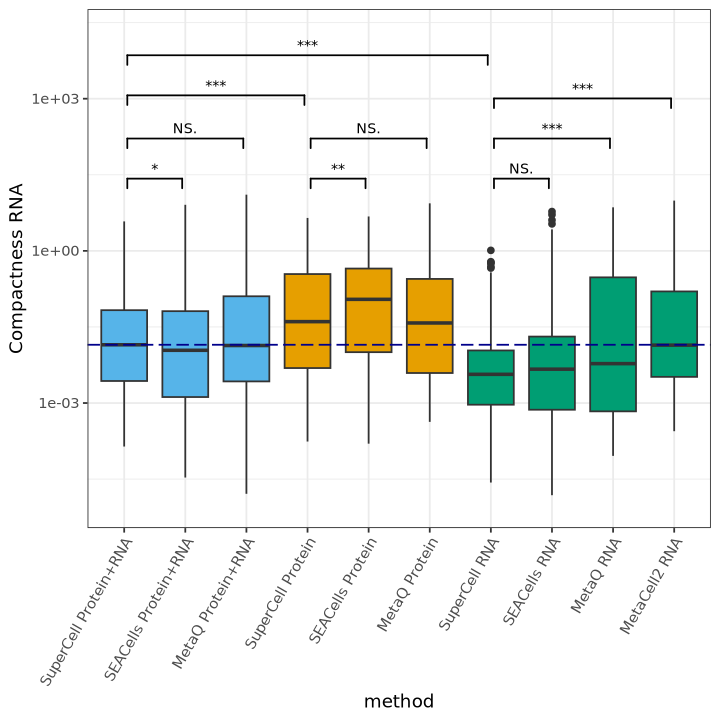

In [91]:

options(repr.plot.width=6, repr.plot.height=6)



hline <- median(metrics[metrics$gamma %in% c(75) & metrics$method == "SuperCell Protein+RNA","compactness_pca"])
compactness_pca.bmc.cite.g75 <- ggplot(metrics[metrics$gamma %in% c(75),],aes(y=compactness_pca,x = method,fill = input)) + 
  geom_boxplot() + theme_bw() + 
  scale_y_log10(limits = c(0.00001,20000))+  geom_hline(yintercept =hline,color = "darkblue",linetype = "longdash")  +
  geom_signif(comparisons = comparisons.multi,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.protein,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.rna,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparison.inter.modality,y_position =2.75, ,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  scale_x_discrete(guide = guide_axis(angle = 60)) + 
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Compactness RNA")


compactness_pca.bmc.cite.g75 + NoLegend()

Warning message:
“Removed 16 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 16 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 16 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 16 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 16 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 16 rows containing non-finite outside the scale range
(`stat_signif()`).”


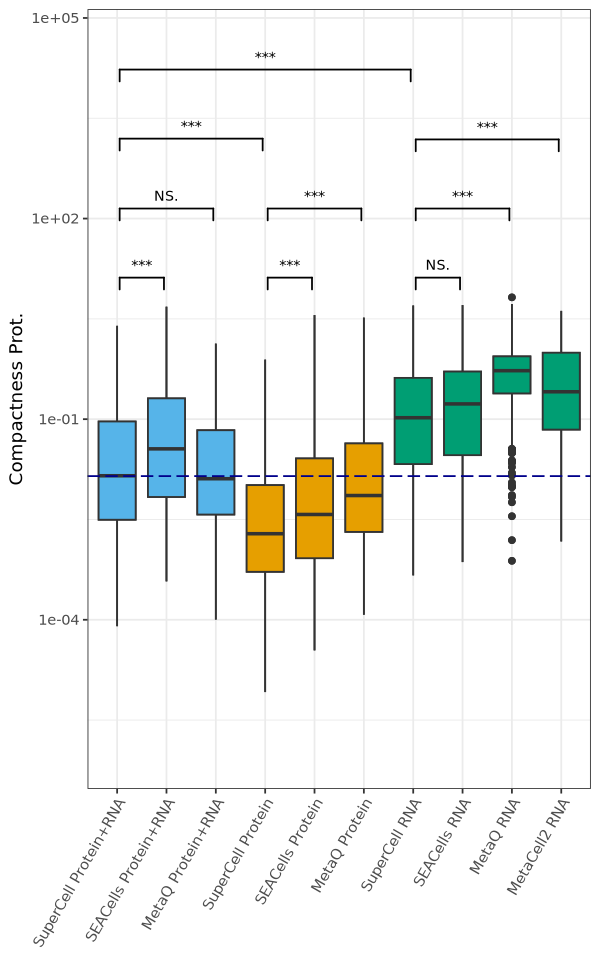

In [129]:
hline <- median(metrics[metrics$gamma %in% c(75) & metrics$method == "SuperCell Protein+RNA","compactness_pca"])

compactness_apca.bmc.cite.g75 <- ggplot(metrics[metrics$gamma %in% c(75),],aes(y=compactness_apca,x = method,fill = input)) + 
  geom_boxplot() +theme_bw()+
  geom_boxplot() + scale_y_log10(limits = c(0.000001,40000))+  geom_hline(yintercept =hline,color = "darkblue",linetype = "longdash") +
  geom_signif(comparisons = comparisons.multi,step_increase=0.175,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.protein,step_increase=0.175,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.rna,step_increase=0.175,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparison.inter.modality,y_position =2.9 ,step_increase=0.175,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  scale_x_discrete(guide = guide_axis(angle = 60)) + 
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Compactness Prot.") + theme(axis.title.x = element_blank())


compactness_apca.bmc.cite.g75 + NoLegend()

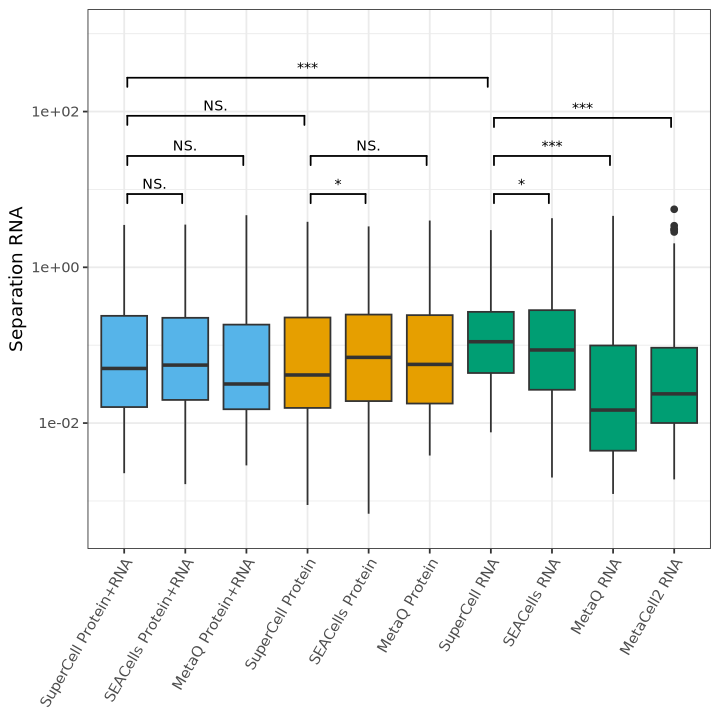

In [93]:
separation_pca.g75 <- ggplot(metrics[metrics$gamma %in% c(75),],aes(y=separation_pca,x = method,fill = input)) + 
  geom_boxplot() + theme_bw() + scale_y_log10(limits = c(0.0005,1000)) +
  geom_signif(comparisons = comparisons.multi,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.protein,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.rna,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparison.inter.modality,y_position =1.75, ,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  scale_x_discrete(guide = guide_axis(angle = 60)) + 
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Separation RNA") + theme(axis.title.x = element_blank())


separation_pca.g75 + NoLegend()

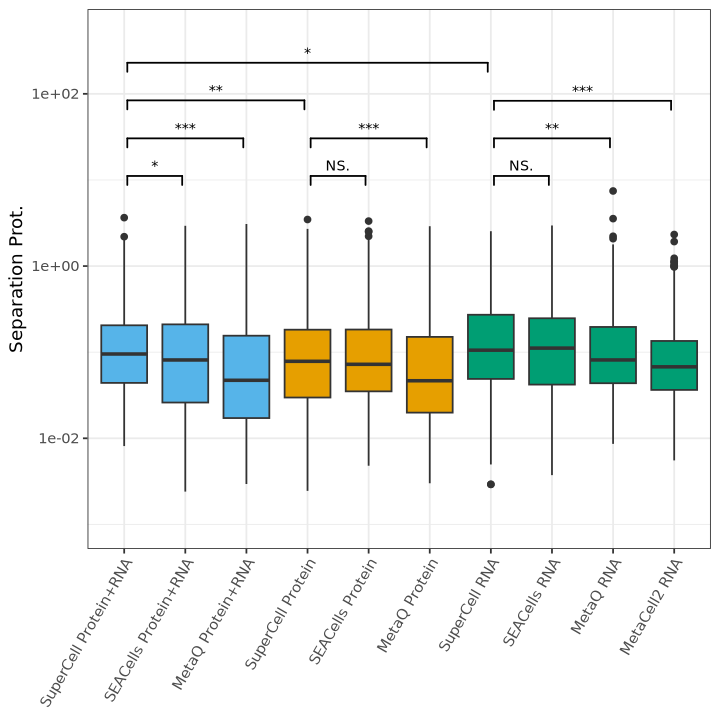

In [94]:
separation_apca.g75 <- ggplot(metrics[metrics$gamma %in% c(75),],aes(y=separation_apca,x = method,fill = input)) + 
  geom_boxplot() + theme_bw() +  scale_y_log10(limits = c(0.001,500))+
  
  geom_signif(comparisons = comparisons.multi,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.protein,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.rna,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparison.inter.modality,y_position =1.75, ,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  scale_x_discrete(guide = guide_axis(angle = 60)) + 
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Separation Prot.") + theme(axis.title.x = element_blank())


separation_apca.g75 + NoLegend()

New version no reversed, scaling without random but with semi sup, noisy sup and test knn, singleton compactness set to 0

In [145]:
library(dplyr)
bench.75.no.random <- metrics[metrics$gamma %in% c(75) & metrics$method != "Random None",]
bench.75.no.random$pct_known <- 0
bench.75.no.random$k_nn <- 30

bench.75.no.random[bench.75.no.random$size == 1,]



bench.75.no.random$pct_known <- 0
bench.75.no.random$guiding_labels <- NA

# add semi sup tests for scaling comp/sep
semi.sup.multi <- read.csv(paste0(datadir,
                                  "/output/bmCiteSeq//SuperCellMulti/testSemiSup/g75/results_test_semisup.csv"),
                           row.names = 1)
semi.sup.multi$gamma <- 75
semi.sup.multi$input <- "Protein+RNA" 
semi.sup.multi$tool <- "ssSuperCell" 
semi.sup.multi$method <- "SuperCell Protein+RNA" 
semi.sup.multi$guiding_labels <- NA
semi.sup.multi$k_nn <- 30


semi.sup.rna <- read.csv(paste0(datadir,
                                  "/output/bmCiteSeq//SuperCellRNA/testSemiSup/g75/results_test_semisup.csv"),
                           row.names = 1)
semi.sup.rna$gamma <- 75
semi.sup.rna$input <- "RNA" 
semi.sup.rna$tool <- "ssSuperCell" 
semi.sup.rna$method <- "SuperCell RNA" 
semi.sup.rna$guiding_labels <- NA
semi.sup.rna$k_nn <- 30







keep.shuffling <-c("guiding_label_0_pct_shuffled",
                   "guiding_label_1_pct_shuffled",
                   "guiding_label_5_pct_shuffled",
                   "guiding_label_10_pct_shuffled",
                   "guiding_label_20_pct_shuffled",
                   "unsupervised")

sup.multi <- read.csv(paste0(datadir,
                             "/output/bmCiteSeq/SuperCellMulti/testShufflingSup/g75/results_test_shuffle_closest.csv"),
                      row.names = 1)
sup.multi <- sup.multi[sup.multi$guiding_labels %in% keep.shuffling,]
sup.multi$gamma <- 75
sup.multi$input <- "Protein+RNA" 
sup.multi$tool <- "supSuperCell" 
sup.multi$method <- "SuperCell Protein+RNA" 
sup.multi$pct_known <- 100
sup.multi$k_nn <- 30

sup.rna <- read.csv(paste0(datadir,
                             "/output/bmCiteSeq/SuperCellRNA/testShufflingSup/g75/results_test_shuffle_closest.csv"),
                      row.names = 1)
sup.rna <- sup.rna[sup.rna$guiding_labels %in% keep.shuffling,]
sup.rna$gamma <- 75
sup.rna$input <- "RNA" 
sup.rna$tool <- "supSuperCell" 
sup.rna$method <- "SuperCell RNA" 
sup.rna$pct_known <- 100
sup.rna$k_nn <- 30


## add test KNN





unsup_knn_g75 <- read.csv(paste0(datadir,"/output/bmCiteSeq/SuperCellMulti/testKNN/g75/results_test_k_nn.csv"))
unsup_knn_g75$gamma <- 75
unsup_knn_g75$input <- "Protein+RNA" 
unsup_knn_g75$tool <- "SuperCell_testKNN" 
unsup_knn_g75$method <- "SuperCell Protein+RNA" 
unsup_knn_g75$pct_known <- 0




sup_knn_g75 <- read.csv(paste0(datadir,"/output/bmCiteSeq/SuperCellMulti/testKNN_sup/g75/results_test_k_nn.csv"))
sup_knn_g75$gamma <- 75
sup_knn_g75$input <- "Protein+RNA" 
sup_knn_g75$tool <- "supSuperCell_testKNN" 
sup_knn_g75$method <- "SuperCell Protein+RNA" 
sup_knn_g75$pct_known <- 100

test_knn <- rbind(unsup_knn_g75,
                  sup_knn_g75[,colnames(unsup_knn_g75)])
test_knn$guiding_labels <- NA



cn <- colnames(bench.75.no.random)[colnames(bench.75.no.random) %in% colnames(sup.multi)]

bench.75.no.random <- rbind(bench.75.no.random[,cn],semi.sup.multi[,cn],semi.sup.rna[,cn],
                            sup.multi[,cn],sup.rna[,cn],test_knn[,cn])

#bench.75.no.random <- bench.75.no.random[bench.75.no.random$size > 1,]
bench.75.no.random$compactness_apca[bench.75.no.random$size == 1] <- 0
bench.75.no.random$compactness_pca[bench.75.no.random$size == 1] <- 0

,orig.ident,nCount_RNA,nFeature_RNA,nCount_ADT,nFeature_ADT,orig.ident_purity,lane,lane_purity,donor,donor_purity,⋯,separation_apca,asw_apca_diffusion,asw_pca_diffusion,input,gamma,method,tool,purity,pct_known,k_nn
,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<chr>,<dbl>,<dbl>,<dbl>
Metacell_64106,bmcite,1223,501,2264,25,1,HumanHTO6,1,batch1,1,⋯,0.15431605,0,0,Protein+RNA,75,MetaQ Protein+RNA,MetaQ,1,0,30
Metacell_25922,bmcite,1229,483,2913,24,1,HumanHTO6,1,batch1,1,⋯,0.09345700,0,0,Protein+RNA,75,MetaQ Protein+RNA,MetaQ,1,0,30
Metacell_32022,bmcite,22071,3898,11153,25,1,HumanHTO8,1,batch1,1,⋯,0.73241524,0,0,Protein+RNA,75,MetaQ Protein+RNA,MetaQ,1,0,30
Metacell_33322,bmcite,1434,611,7411,25,1,HumanHTO8,1,batch1,1,⋯,0.01817412,0,0,Protein+RNA,75,MetaQ Protein+RNA,MetaQ,1,0,30
Metacell_35022,bmcite,1057,458,1435,25,1,HumanHTO8,1,batch1,1,⋯,0.11870273,0,0,Protein+RNA,75,MetaQ Protein+RNA,MetaQ,1,0,30
Metacell_35722,bmcite,1616,536,3597,22,1,HumanHTO7,1,batch1,1,⋯,0.04926688,0,0,Protein+RNA,75,MetaQ Protein+RNA,MetaQ,1,0,30
Metacell_35822,bmcite,2065,697,878,24,1,HumanHTO3,1,batch2,1,⋯,0.19046692,0,0,Protein+RNA,75,MetaQ Protein+RNA,MetaQ,1,0,30
Metacell_35922,bmcite,1381,583,3494,24,1,HumanHTO10,1,batch2,1,⋯,0.22899265,0,0,Protein+RNA,75,MetaQ Protein+RNA,MetaQ,1,0,30
Metacell_36022,bmcite,2638,763,8044,25,1,HumanHTO2,1,batch2,1,⋯,0.05703862,0,0,Protein+RNA,75,MetaQ Protein+RNA,MetaQ,1,0,30


In [146]:
table(bench.75.no.random$method,bench.75.no.random$tool)
table(bench.75.no.random[bench.75.no.random$tool %in% c("SuperCell_testKNN","supSuperCell_testKNN"),"tool"],
     bench.75.no.random[bench.75.no.random$tool %in% c("SuperCell_testKNN","supSuperCell_testKNN"),"k_nn"])

table(bench.75.no.random[bench.75.no.random$tool %in% c("ssSuperCell"),"pct_known"])
table(bench.75.no.random[bench.75.no.random$tool %in% c("supSuperCell"),"guiding_labels"])

                       
                        MetaCell2 MetaQ SEACells SuperCell SuperCell_testKNN
  SuperCell Protein+RNA         0     0        0       408              2856
  SEACells Protein+RNA          0     0      408         0                 0
  MetaQ Protein+RNA             0   360        0         0                 0
  SuperCell Protein             0     0        0       408                 0
  SEACells Protein              0     0      408         0                 0
  MetaQ Protein                 0   369        0         0                 0
  SuperCell RNA                 0     0        0       408                 0
  SEACells RNA                  0     0      408         0                 0
  MetaQ RNA                     0   407        0         0                 0
  MetaCell2 RNA               419     0        0         0                 0
  Random None                   0     0        0         0                 0
                       
                        ssSu

                      
                        10  20  30  40  60  80 100
  SuperCell_testKNN    408 408 408 408 408 408 408
  supSuperCell_testKNN 408 408 408 408 408 408 408


  0  25  50  75 100 
816 816 816 816 816 


 guiding_label_0_pct_shuffled guiding_label_10_pct_shuffled 
                          816                           816 
 guiding_label_1_pct_shuffled guiding_label_20_pct_shuffled 
                          816                           816 
 guiding_label_5_pct_shuffled                  unsupervised 
                          816                           816 

In [149]:



minMaxScaling <- function(x) {
  y <- (x-min(x))/(max(x)-min(x))
  return(y)
}



bench.75.no.random$compactness_pca_scaled <- minMaxScaling(bench.75.no.random$compactness_pca)
bench.75.no.random$compactness_apca_scaled <- minMaxScaling(bench.75.no.random$compactness_apca)

bench.75.no.random$multimodal_compactness <- (bench.75.no.random$compactness_pca_scaled + bench.75.no.random$compactness_apca_scaled) / 2


bench.75.no.random$separation_pca_norm <- (bench.75.no.random$separation_pca)
bench.75.no.random$separation_apca_norm <- (bench.75.no.random$separation_apca)

bench.75.no.random$separation_pca_scaled <- minMaxScaling(bench.75.no.random$separation_pca_norm)
bench.75.no.random$separation_apca_scaled <- minMaxScaling(bench.75.no.random$separation_apca_norm)

bench.75.no.random$multimodal_separation <- (bench.75.no.random$separation_pca_scaled + bench.75.no.random$separation_apca_scaled) / 2

#check min max used for scaling
bench.75.no.random[which.min(bench.75.no.random$compactness_apca),c("method","tool")]
bench.75.no.random[which.max(bench.75.no.random$compactness_apca),c("method","tool")]

bench.75.no.random[which.min(bench.75.no.random$compactness_pca),c("method","tool")]
bench.75.no.random[which.max(bench.75.no.random$compactness_pca),c("method","tool")]

bench.75.no.random[which.min(bench.75.no.random$separation_apca),c("method","tool")]
bench.75.no.random[which.max(bench.75.no.random$separation_apca),c("method","tool")]

bench.75.no.random[which.min(bench.75.no.random$separation_pca),c("method","tool")]
bench.75.no.random[which.max(bench.75.no.random$separation_pca),c("method","tool")]

bench.75.unsup <- bench.75.no.random[!bench.75.no.random$tool %in% 
                                     c("ssSuperCell","supSuperCell",
                                       "supSuperCell_testKNN","SuperCell_testKNN"),]

table(bench.75.unsup$method,bench.75.unsup$tool)


,method,tool
,<fct>,<chr>
Metacell_64106,MetaQ Protein+RNA,MetaQ


,method,tool
,<fct>,<chr>
Metacell_40133,MetaQ RNA,MetaQ


,method,tool
,<fct>,<chr>
Metacell_64106,MetaQ Protein+RNA,MetaQ


,method,tool
,<fct>,<chr>
Metacell_35422,MetaQ Protein+RNA,MetaQ


,method,tool
,<fct>,<chr>
1268,SuperCell Protein+RNA,SuperCell_testKNN


,method,tool
,<fct>,<chr>
Metacell_31138,MetaQ RNA,MetaQ


,method,tool
,<fct>,<chr>
Metacell_571,SuperCell Protein+RNA,ssSuperCell


,method,tool
,<fct>,<chr>
Metacell_41920,MetaCell2 RNA,MetaCell2


                       
                        MetaCell2 MetaQ SEACells SuperCell
  SuperCell Protein+RNA         0     0        0       408
  SEACells Protein+RNA          0     0      408         0
  MetaQ Protein+RNA             0   360        0         0
  SuperCell Protein             0     0        0       408
  SEACells Protein              0     0      408         0
  MetaQ Protein                 0   369        0         0
  SuperCell RNA                 0     0        0       408
  SEACells RNA                  0     0      408         0
  MetaQ RNA                     0   407        0         0
  MetaCell2 RNA               419     0        0         0
  Random None                   0     0        0         0

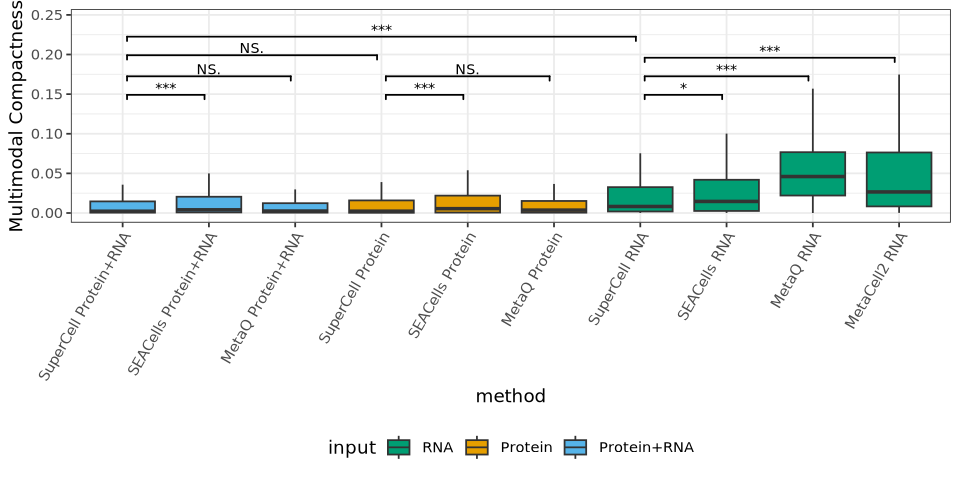

In [150]:
bench.75.unsup <- bench.75.no.random[!bench.75.no.random$tool %in% c("ssSuperCell","supSuperCell","SuperCell_testKNN"),]

sig.multimodal.compactness.g75  <- ggplot(bench.75.unsup,aes(y=multimodal_compactness,x = method,fill = input)) +
  geom_boxplot(outlier.shape = NA) + theme_bw() +
  #facet_wrap("gamma",nrow = 1) +
  #ylim(c(0,1.425)) +
  # geom_signif(comparisons = comparisons,
  #             y_position = 0.08,
  #             step_increase=0.03,
  #             tip_length = 0.007,
  #             map_signif_level=T,
  #             extend_line = -0.005,
  #             textsize = 3)+
  # geom_signif(comparisons = comparison.inter.modality,
  #             y_position = 0.08,
  #             step_increase=0.03,
  #             tip_length = 0.007,
  #             map_signif_level=T,
  #             extend_line = -0.005,
  #             textsize = 3) +
  
  geom_signif(comparisons = comparisons.multi,step_increase=0.03,y_position = 0.11,tip_length = 0.007,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.protein,step_increase=0.03,y_position = 0.11,tip_length = 0.007,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.rna,step_increase=0.03,y_position = 0.11,tip_length = 0.007,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparison.inter.modality,y_position =0.16,tip_length = 0.007,step_increase=0.03,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Multimodal Compactness") +  # Hides outliers
  coord_cartesian(ylim = c(0, 0.245))


sig.multimodal.compactness.g75

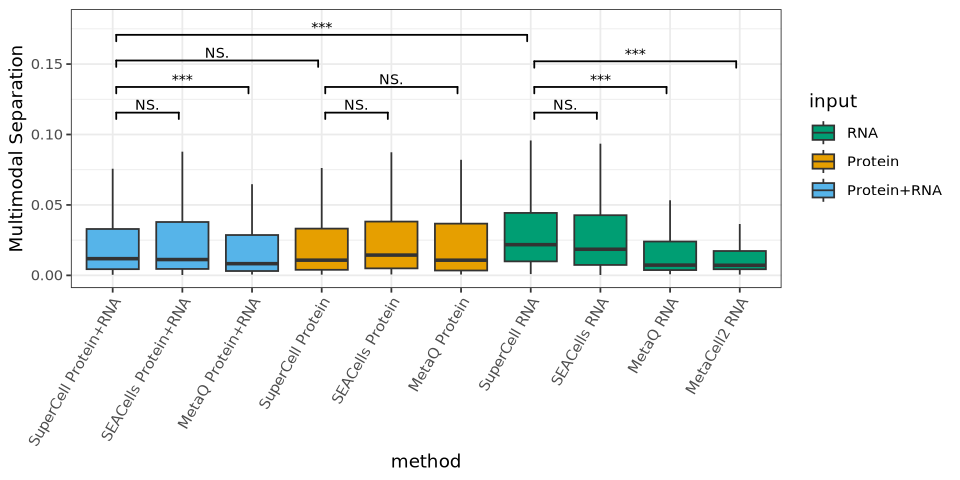

In [151]:



sig.multimodal.separation.g75 <- ggplot(bench.75.unsup,aes(y=multimodal_separation,x = method,fill = input)) + 
  geom_boxplot(outlier.shape = NA)  + theme_bw() +
  
  # geom_signif(comparisons = comparisons,
  #             step_increase=0.03,
  #             tip_length = 0.007,
  #             map_signif_level=T,
  #             extend_line = -0.005,textsize = 3,
  #             y_position = 0.1) +
  # geom_signif(comparisons = comparison.inter.modality,
  #             step_increase=0.03,
  #             tip_length = 0.007,
  #             map_signif_level=T,
  #             extend_line = -0.005,
  #             textsize = 3,
  #             y_position = 0.1) +
  geom_signif(comparisons = comparisons.multi,step_increase=0.02,y_position = 0.07,tip_length = 0.005,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.protein,step_increase=0.02,y_position = 0.07,tip_length = 0.005,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.rna,step_increase=0.02,y_position = 0.07,tip_length = 0.005,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparison.inter.modality,y_position =0.107,tip_length = 0.005,step_increase=0.02,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  scale_x_discrete(guide = guide_axis(angle = 60))  + scale_fill_manual(values = input.colors.cite) + ylab("Multimodal Separation")  +  # Hides outliers
  coord_cartesian(ylim = c(0, 0.18)) 
#coord_cartesian(ylim = c(0.82, 1.23))  + theme_void() + NoLegend()
sig.multimodal.separation.g75

# full.multimodal.separation.g75 <- cowplot::plot_grid(sig.multimodal.separation.g75,multimodal_separation.75+ NoLegend(), rel_heights = c(0.2,0.8),align = "v",ncol = 1)
# 
# full.multimodal.separation.g75

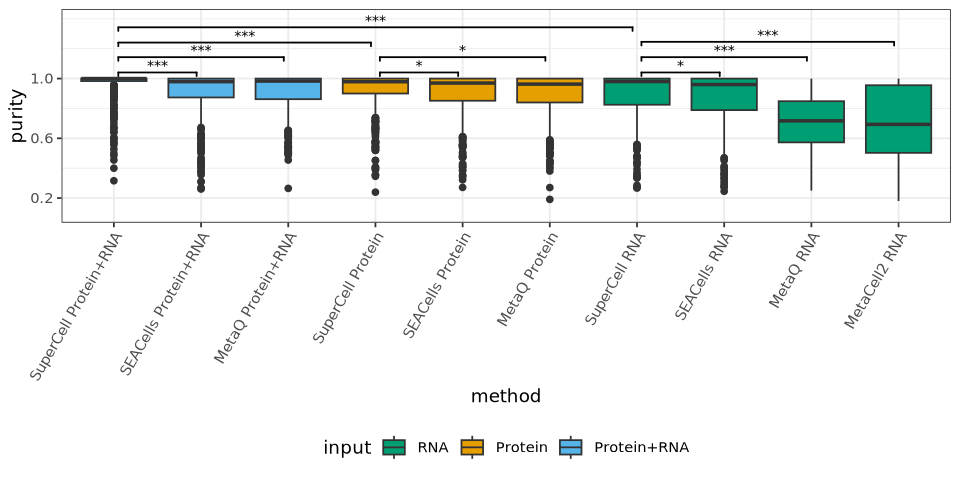

In [152]:




# sig.celltype.l2_purity.g75  <- ggplot(bench.75.unsup,aes(y=celltype.l2_purity,x = method,fill = input)) + 
#   geom_boxplot()  + theme_bw() +
#   #facet_wrap("gamma",nrow = 1) + 
#   #ylim(c(0,1.425)) + 
#   geom_signif(comparisons = comparisons,
#               step_increase=0.2,
#               map_signif_level=T,
#               extend_line = -0.005,
#               textsize = 3)+
#   geom_signif(comparisons = comparison.inter.modality,
#               step_increase=0.2,
#               map_signif_level=T,
#               extend_line = -0.005,
#               textsize = 3) +
#   scale_x_discrete(guide = guide_axis(angle = 60)) + 
#   theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Purity")  +
#   scale_y_continuous(limits = c(0.15,1.75),breaks =c(0.4,0.7,1))

sig.celltype.l2_purity.g75 <- purity.bmc.cite.g75
sig.celltype.l2_purity.g75
# Hides outliers
#coord_cartesian(ylim = c(0, limits$ymax))   # Sets y-axis limits


# full.celltype.l2_purity.g75 <-cowplot::plot_grid(sig.celltype.l2_purity.g75,celltype.l2_purity.g75+ NoLegend(), rel_heights = c(0.2,0.8),align = "v",ncol = 1)
# full.celltype.l2_purity.g75

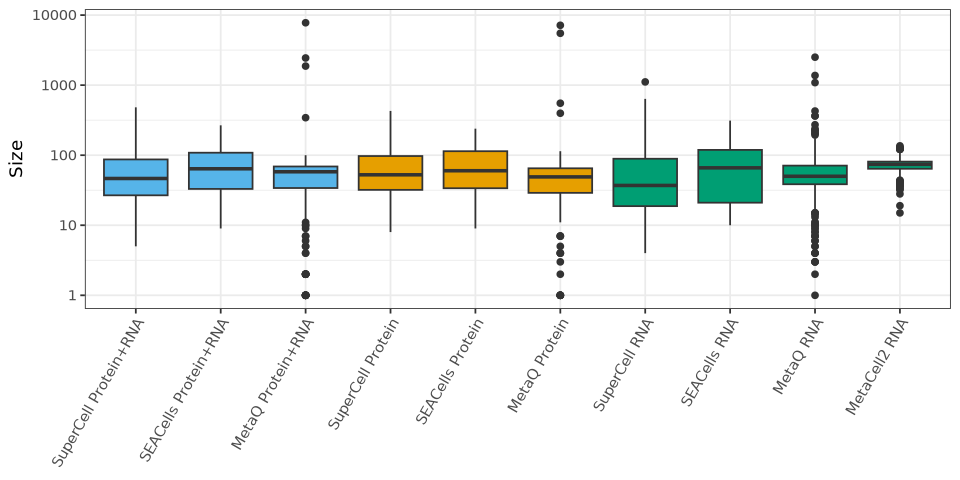

In [153]:
size.g75 <- ggplot(metrics[metrics$gamma == 75,],aes(y=size,x = method,fill = input)) + 
  geom_boxplot()  + theme_bw() +
  scale_x_discrete(guide = guide_axis(angle = 60)) + scale_y_log10() +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Size") + theme(axis.title.x = element_blank()) + NoLegend()
size.g75

gamma 75 whole process

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


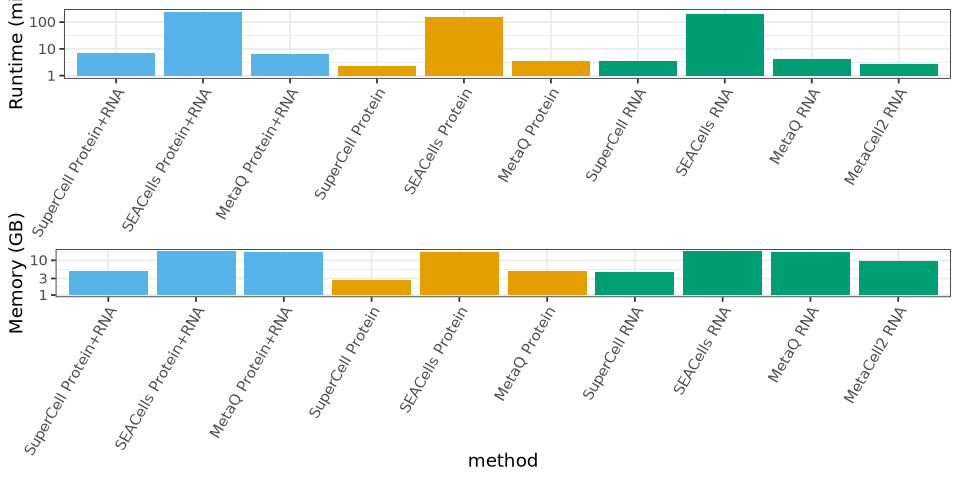

In [154]:
library(patchwork)
cowplot::plot_grid(cite.run.time.plot.g75 + NoLegend(),cite.memory.plot.g20+ NoLegend(),ncol=1)

cite.run.time.plot.g75 <- cite.run.time.plot.g75 + NoLegend() +
  theme(axis.title.x = element_blank()) +
  scale_x_discrete(guide = guide_axis(angle = 60)) # Remove x-axis text/ticks

cite.memory.plot.g75 <- cite.memory.plot.g75 +
  theme(axis.title.x = element_blank())  +
  scale_x_discrete(guide = guide_axis(angle = 60)) 

# Combine plots in a single column with same width
# scalability.g75 <- cite.run.time.plot.g75 / cite.memory.plot.g75 + plot_layout(heights = c(1, 1))
# scalability.g75

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


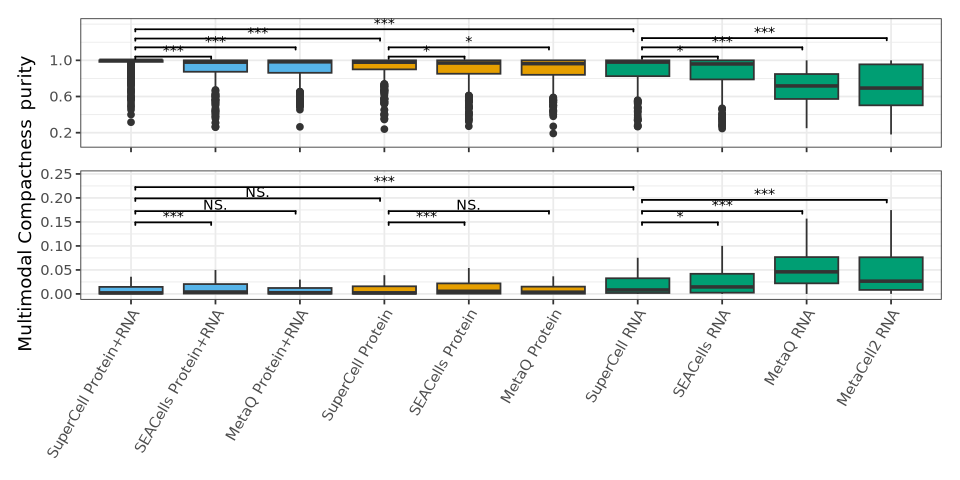

In [155]:
sig.celltype.l2_purity.g75 <- sig.celltype.l2_purity.g75  + NoLegend() +
  theme(axis.text.x = element_blank(),axis.title.x = element_blank()) 

sig.multimodal.compactness.g75 <-  sig.multimodal.compactness.g75 + NoLegend() +
  theme(axis.title.x = element_blank())  +
  scale_x_discrete(guide = guide_axis(angle = 60)) 

comp.pur.g75 <- sig.celltype.l2_purity.g75 / sig.multimodal.compactness.g75 + plot_layout(heights = c(1, 1))

comp.pur.g75

In [156]:

leg.input <- cowplot::get_legend(size.g75 + theme(legend.position = "right"))

sig.multimodal.separation.g75 <- sig.multimodal.separation.g75 + NoLegend() +
  theme(axis.text.x = element_blank(),axis.title.x = element_blank()) 

# sep.g75 <-  sig.multimodal.separation.g75 + NoLegend() +
#   theme(axis.title.x = element_blank())  +
#   scale_x_discrete(guide = guide_axis(angle = 60)) 
# sep.g75<- sep.g75 / leg.input + plot_layout(heights = c(1, 1))
# sep.g75


In [ ]:
# plot.main.g75 <- cowplot::plot_grid(comp.pur.g75,sep.g75,scalability.g75,nrow = 1)
# plot.main.g75

Sparsity reduction

In [157]:
bm$resolution <- "Single-cells"
bm.supercell.multi$resolution <- "Metacells"
meta.sc.mc <- rbind(bm@meta.data[,c("nCount_RNA","nFeature_RNA","nCount_ADT","nFeature_ADT","resolution")],
                    bm.supercell.multi@meta.data[,c("nCount_RNA","nFeature_RNA","nCount_ADT","nFeature_ADT","resolution")])

meta.sc.mc$resolution <- factor(meta.sc.mc$resolution,levels = c("Metacells","Single-cells"))

meta.sc.mc$resolution <- factor(meta.sc.mc$resolution,levels = c("Metacells","Single-cells"))

nFeature_RNA <- ggplot(meta.sc.mc,aes(x=resolution,y=nFeature_RNA,fill = resolution)) + geom_violin(scale = "width") + theme_bw() + theme(axis.title.x = element_blank())  +
  scale_x_discrete(guide = guide_axis(angle = 60)) + 
  scale_fill_manual(values = c("#56B4E9", "#D55E00")) #colorblind_pal()(8)[c(3,7)]


nCount_RNA <- ggplot(meta.sc.mc,aes(x=resolution,y=nCount_RNA,fill = resolution)) + geom_violin(scale = "width") + theme_bw() +  theme(axis.title.x = element_blank())  +
  scale_x_discrete(guide = guide_axis(angle = 60)) + 
  scale_fill_manual(values = c("#56B4E9", "#D55E00")) #colorblind_pal()(8)[c(3,7)]

sparsity.reduction.g75 <- cowplot::plot_grid(nFeature_RNA+ NoLegend(),nCount_RNA+ NoLegend(),ncol = 1)

In [158]:
nFeature_RNA <- nFeature_RNA  + NoLegend() +
  theme(axis.text.x = element_blank(),axis.title.x = element_blank()) + ylab("Detected Genes")

nCount_RNA <-  nCount_RNA + NoLegend() + scale_y_log10() + 
  theme(axis.title.x = element_blank())  +
  scale_x_discrete(guide = guide_axis(angle = 60))+ ylab("RNA Counts (UMI)")

sparsity.reduction.g75 <- nFeature_RNA / nCount_RNA + plot_layout(heights = c(1, 1))


Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


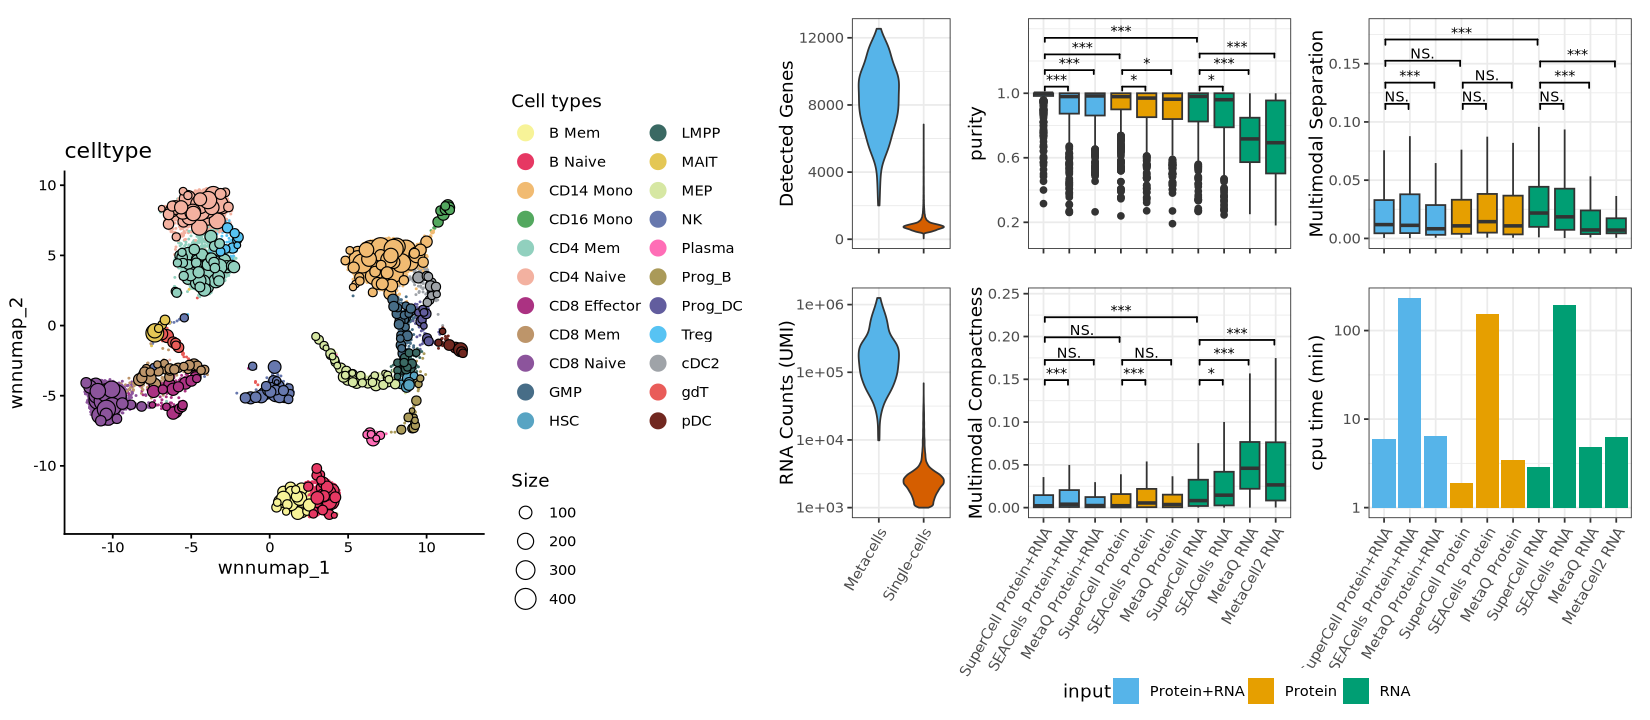

In [159]:
options(repr.plot.width=13.75, repr.plot.height=6)

Fig2DEF <- cowplot::plot_grid(fig1.A+theme(plot.margin = unit(c(80,0,80,0),units = "pt")),
                              wrap_plots(nFeature_RNA, 
                                         sig.celltype.l2_purity.g75 + NoLegend(), 
                                         sig.multimodal.separation.g75+ NoLegend(), 
                                         nCount_RNA,
                                         sig.multimodal.compactness.g75+ NoLegend(),
                                         cite.cpu.time.plot.g75 + 
                                           theme(legend.position = c(-0.5,-0.75),legend.direction = "horizontal",axis.title.x = element_blank()),
                                         nrow = 2,ncol = 3,widths = c(0.75,2,2))&theme(plot.margin = margin(5.5, 5.5, 15, 5.5)),
                              nrow = 1,
                              rel_widths = c(3,3.5))
Fig2DEF



In [160]:
dir.create("../../../pdf_files/Fig2/", recursive = T, showWarnings = F )
pdf("../../../pdf_files/Fig2/fig2DEF.pdf",height = 6,width = 13.75)
Fig2DEF
dev.off()

agg_record_300473553 
                   2

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Warning message:
“Removed 17 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 17 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 17 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 17 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 17 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 16 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 16 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 16 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 16 rows containing non-finite outside the scale range
(`stat_signif()`).

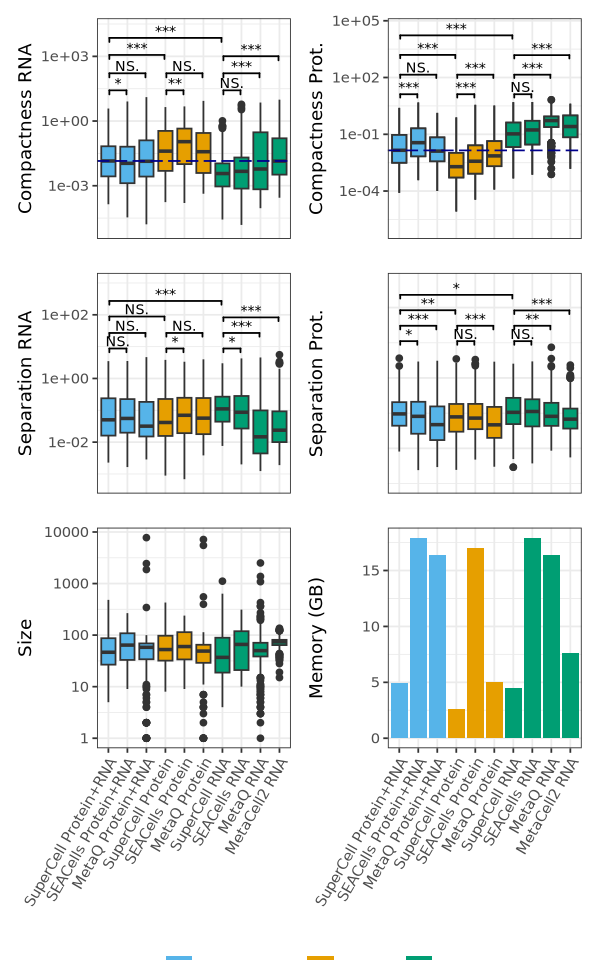

In [161]:
options(repr.plot.width=5, repr.plot.height=8)

# metacell of size 1 don't have a compactness and trigger  warnings

figS2B <- wrap_plots(compactness_pca.bmc.cite.g75+ NoLegend() + 
                       theme(axis.title.x = element_blank()),
                     compactness_apca.bmc.cite.g75 + 
                       NoLegend() + 
                       theme(axis.title.x = element_blank()),
                     separation_pca.g75 + 
                       NoLegend() + 
                       theme(axis.title.x = element_blank()),
                     separation_apca.g75 + 
                       NoLegend() + 
                       theme(axis.title.x = element_blank()), 
                     
                     size.g75 + NoLegend() + theme(axis.title.x = element_blank()),
                     cite.memory.plot.g75 + 
                       theme(axis.title.x = element_blank(),legend.position = c(-0.5,-1),legend.direction = "horizontal")+
                       scale_x_discrete(guide = guide_axis(angle = 60)),
                     ncol = 2,axes = "collect",axis_titles = "collect") &theme(plot.margin = margin(5.5, 5.5, 15, 5.5))


# figS2B <- cowplot::plot_grid(cowplot::plot_grid(compactness_pca.bmc.cite.g75+ NoLegend() + 
#                                                   theme(axis.title.x = element_blank()),
#                                                 compactness_apca.bmc.cite.g75 + 
#                                                   NoLegend() + 
#                                                   theme(axis.title.x = element_blank()),
#                                                 separation_pca.g75 + 
#                                                   NoLegend() + 
#                                                   theme(axis.title.x = element_blank()),
#                                                 separation_apca.g75 + 
#                                                   NoLegend() + 
#                                                   theme(axis.title.x = element_blank()), 
#                                                 
#                                                 size.g75 + NoLegend() + theme(axis.title.x = element_blank()),
#                                                 cite.memory.plot.g75 + 
#                                                   theme(axis.title.x = element_blank())+
#                                                   scale_x_discrete(guide = guide_axis(angle = 60)),
#                                                 ncol = 2),
#                              get_legend(cite.memory.plot.g75),ncol = 1,rel_heights = c(14,3))

figS2B


In [ ]:
# figS2B <- cowplot::plot_grid(cowplot::plot_grid(compactness_pca.bmc.cite.g75+ 
#                                         NoLegend() + 
#                                         theme(axis.title.x = element_blank()) +
#                                         scale_x_discrete(guide = guide_axis(angle = 60)),
#                                       
#                                       compactness_lsi.bmc.cite. + NoLegend() + theme(axis.title.x = element_blank()) +
#                                         scale_x_discrete(guide = guide_axis(angle = 60)),
#                                       size.g20 + NoLegend() + theme(axis.title.x = element_blank()) +
#                                         scale_x_discrete(guide = guide_axis(angle = 60)),
#                                       separation_pca.g20 + NoLegend() + theme(axis.title.x = element_blank()) +
#                                         scale_x_discrete(guide = guide_axis(angle = 60)),
#                                       separation_lsi.g20 + NoLegend() + theme(axis.title.x = element_blank()) +
#                                         scale_x_discrete(guide = guide_axis(angle = 60)), 
#                                       multiome.cpu.time.plot.g20 + NoLegend() +
#                                         scale_x_discrete(guide = guide_axis(angle = 60)),ncol = 2),get_legend(cite.memory.plot.g75),ncol = 1,rel_heights = c(14,3))
# 
# figS1B

In [162]:
pdf(file = "../../../pdf_files/FigS2/figS2B_g75.pdf",height = 8,width=5)
figS2B
dev.off()

Warning message:
“Removed 17 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 17 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 17 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 17 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 17 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 16 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 16 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 16 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 16 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 16 rows containing non-finite outside the scale range
(`stat_signif()`)

agg_record_70741682 
                  2

## Heatmap of wilcoxon results gamma 75

In [163]:
library(dplyr)
library(purrr)
library(tidyr)
cols <- c("method","purity","multimodal_compactness","multimodal_separation")

bench.75.unsup$purity <- bench.75.unsup$celltype.l2_purity


results <- ComputePairwiseWilcox(bench.results = bench.75.unsup)


#signif(results$RBC,digits = 5) == signif(results$RBC2,digits = 5)

head(results)

metric,group1,group2,n1,n2,W,RBC,p,padj,logP,logFDR
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
multimodal_compactness,SuperCell Protein+RNA,SEACells Protein+RNA,3264,408,594856.0,-0.10662966,4.370143e-04,6.343756e-04,3.3595043,3.1976535
multimodal_compactness,SuperCell Protein+RNA,MetaQ Protein+RNA,3264,360,595914.0,0.01428717,6.559542e-01,6.708623e-01,0.1831265,0.1733666
multimodal_compactness,SuperCell Protein+RNA,SuperCell Protein,3264,408,693357.5,0.04130247,1.731520e-01,1.937460e-01,0.7615725,0.7127673
multimodal_compactness,SuperCell Protein+RNA,SEACells Protein,3264,408,588202.5,-0.11662206,1.199579e-04,1.799368e-04,3.9209713,3.7448800
multimodal_compactness,SuperCell Protein+RNA,MetaQ Protein,3264,369,575194.0,-0.04485825,1.572268e-01,1.814155e-01,0.8034734,0.7413255
multimodal_compactness,SuperCell Protein+RNA,SuperCell RNA,3264,408,461998.0,-0.30615929,5.683200e-24,1.598400e-23,23.2454070,22.7963145


In [164]:
library(dplyr)
library(ggplot2)

# Keep the condition order you want in the plot
condition_order <- rev(c('SuperCell Protein+RNA',"SEACells Protein+RNA","MetaQ Protein+RNA",
                         "SuperCell Protein","SEACells Protein","MetaQ Protein",
                         'SuperCell RNA',"SEACells RNA","MetaQ RNA","MetaCell2 RNA"))


results_plot <- results %>%
  mutate(
    group1 = factor(group1, levels = condition_order),
    group2 = factor(group2, levels = rev(condition_order))
  ) %>%
  filter(
    #as.numeric(group1) > as.numeric(group2),
    p < 0.05
  )

head(results_plot)

metric,group1,group2,n1,n2,W,RBC,p,padj,logP,logFDR
<chr>,<fct>,<fct>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
multimodal_compactness,SuperCell Protein+RNA,SEACells Protein+RNA,3264,408,594856.0,-0.1066297,4.370143e-04,6.343756e-04,3.359504,3.197654
multimodal_compactness,SuperCell Protein+RNA,SEACells Protein,3264,408,588202.5,-0.1166221,1.199579e-04,1.799368e-04,3.920971,3.744880
multimodal_compactness,SuperCell Protein+RNA,SuperCell RNA,3264,408,461998.0,-0.3061593,5.683200e-24,1.598400e-23,23.245407,22.796315
multimodal_compactness,SuperCell Protein+RNA,SEACells RNA,3264,408,418808.0,-0.3710232,1.985256e-34,8.121500e-34,33.702184,33.090364
multimodal_compactness,SuperCell Protein+RNA,MetaQ RNA,3264,407,180510.0,-0.7282393,3.421054e-127,1.539474e-125,126.465840,124.812628
multimodal_compactness,SuperCell Protein+RNA,MetaCell2 RNA,3264,419,304935.0,-0.5540634,2.475945e-76,5.570877e-75,75.606259,74.254076


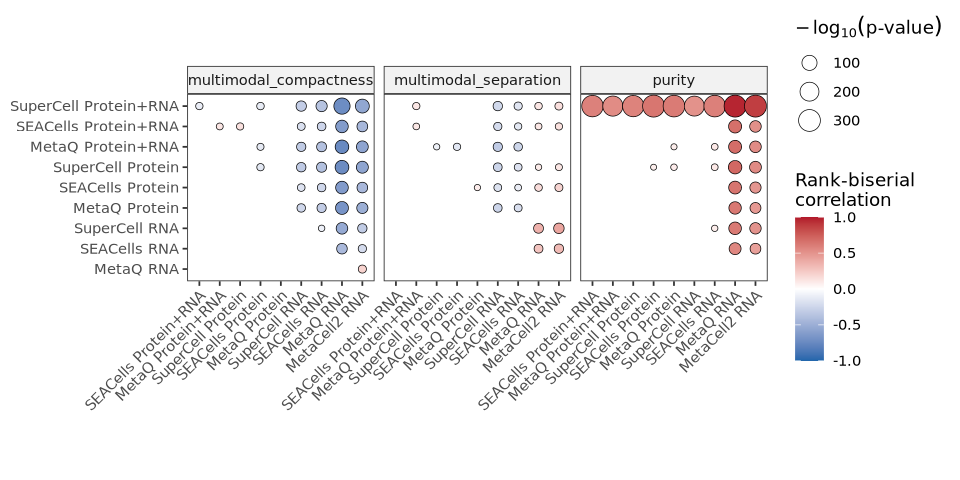

In [135]:
options(repr.plot.width=8, repr.plot.height=4)



heatmap_wilcox <- HeatmapWilcox(results_plot)
heatmap_wilcox

In [165]:
pdf(file = "../../../pdf_files/FigS2/FigS2Anew_WilcoxHeatmap.pdf",height = 4,width=8)
heatmap_wilcox
dev.off()

agg_record_1862820325 
                    2

## Benchmar at gamma 20


In [166]:
bench.20 <- metrics[metrics$gamma %in% c(20),]
table(bench.20$size == 1,bench.20$method)

       
        SuperCell Protein+RNA SEACells Protein+RNA MetaQ Protein+RNA
  FALSE                  1519                 1508              1415
  TRUE                     14                   25                35
       
        SuperCell Protein SEACells Protein MetaQ Protein SuperCell RNA
  FALSE              1531             1509          1399          1522
  TRUE                  2               24            40            11
       
        SEACells RNA MetaQ RNA MetaCell2 RNA Random None
  FALSE         1501      1506          1579           0
  TRUE            32         6             0           0

Set a compactness of 0 for singleton gives
Warning: Removed 79 rows containing non-finite outside the scale range (`stat_signif()`) correspond to singletons when log scale is used

Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 189 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 189 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 189 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 189 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 189 

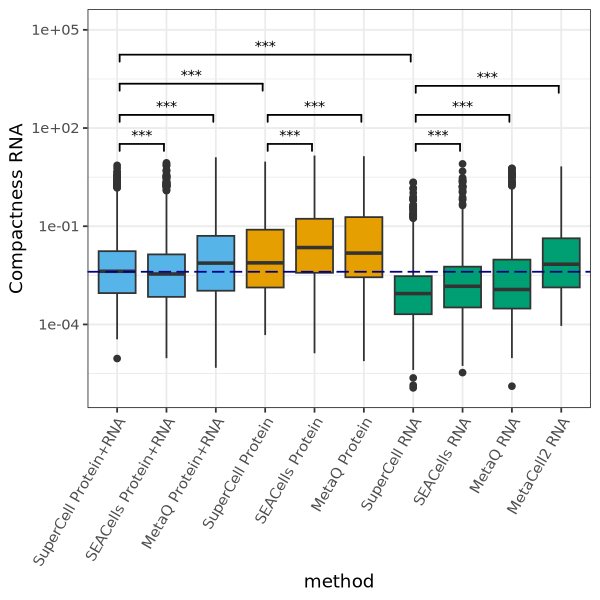

In [169]:
options(repr.plot.width=5, repr.plot.height=5)


bench.20$compactness_apca[bench.20$size == 1] <- 0
bench.20$compactness_pca[bench.20$size == 1] <- 0


hline <- median(bench.20[bench.20$gamma %in% c(20) & bench.20$method == "SuperCell Protein+RNA","compactness_pca"])
compactness_pca.bmc.cite.g20 <- ggplot(bench.20[bench.20$gamma %in% c(20),],aes(y=compactness_pca,x = method,fill = input)) + 
  geom_boxplot() + theme_bw() +
  scale_y_log10(limits =c(0.000001, 120000))+
  geom_hline(yintercept =hline,color = "darkblue",linetype = "longdash") +
  geom_signif(comparisons = comparisons.multi,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.protein,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.rna,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparison.inter.modality,y_position =3, ,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  scale_x_discrete(guide = guide_axis(angle = 60)) + 
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Compactness RNA")


compactness_pca.bmc.cite.g20 + NoLegend()

Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 190 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 190 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 190 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 190 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 190 

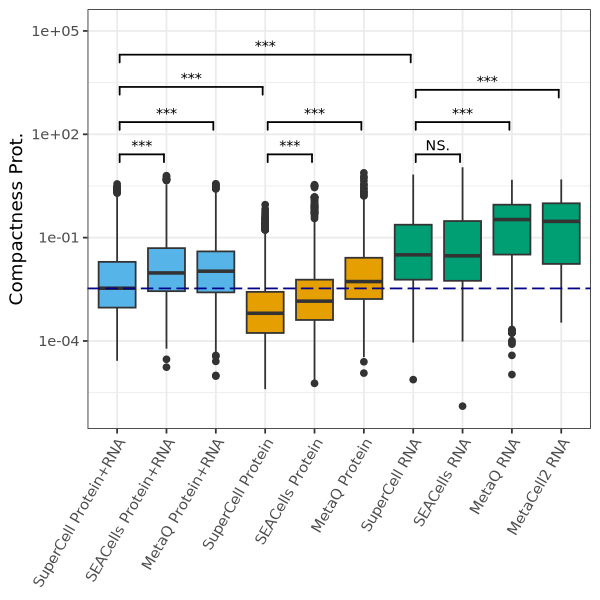

In [170]:
hline <- median(bench.20[(bench.20$gamma %in% c(20) & bench.20$method == "SuperCell Protein+RNA") ,"compactness_apca"])

compactness_apca.bmc.cite.g20 <- ggplot(bench.20[bench.20$gamma %in% c(20),],aes(y=compactness_apca,x = method,fill = input)) + 
  geom_boxplot() + theme_bw() +scale_y_log10(limits =c(0.000001, 120000))+  
  geom_hline(yintercept =hline,color = "darkblue",linetype = "longdash")  +
  geom_signif(comparisons = comparisons.multi,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.protein,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.rna,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparison.inter.modality,y_position =3, ,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  scale_x_discrete(guide = guide_axis(angle = 60)) + 
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Compactness Prot.") + theme(axis.title.x = element_blank())


compactness_apca.bmc.cite.g20 + NoLegend()

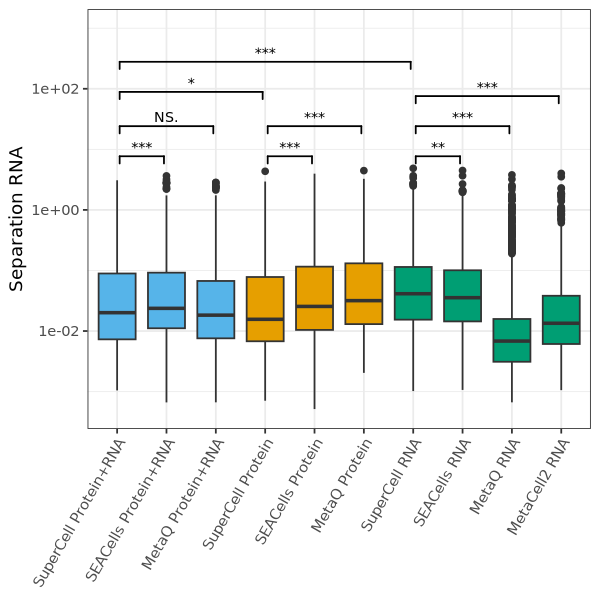

In [171]:
separation_pca.g20 <- ggplot(bench.20[bench.20$gamma %in% c(20),],aes(y=separation_pca,x = method,fill = input)) + 
  geom_boxplot() + theme_bw() + scale_y_log10(limits =c(0.0005, 1000))+
  geom_signif(comparisons = comparisons.multi,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.protein,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.rna,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparison.inter.modality,y_position =1.75, ,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  scale_x_discrete(guide = guide_axis(angle = 60)) + 
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Separation RNA") + theme(axis.title.x = element_blank())


separation_pca.g20 + NoLegend()

Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_signif()`).”


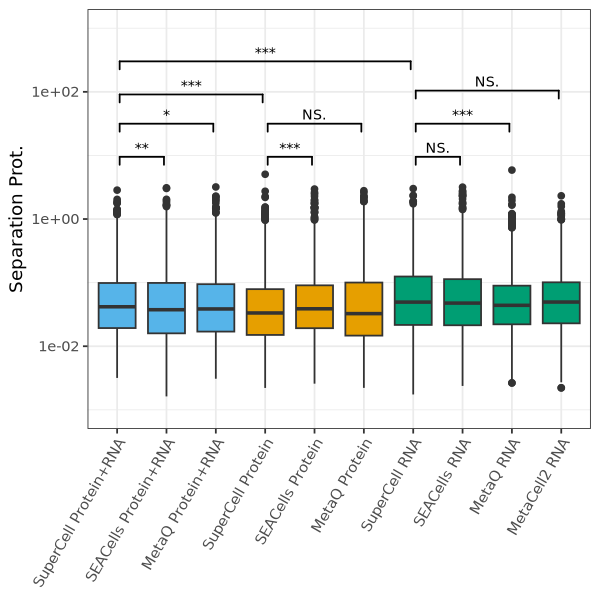

In [172]:
separation_apca.g20 <- ggplot(bench.20[bench.20$gamma %in% c(20),],aes(y=separation_apca,x = method,fill = input)) + 
  geom_boxplot() + theme_bw() + scale_y_log10(limits =c(0.001, 1000))+
  geom_signif(comparisons = comparisons.multi,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.protein,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.rna,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparison.inter.modality,y_position =1.75, ,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  scale_x_discrete(guide = guide_axis(angle = 60)) + 
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Separation Prot.") + theme(axis.title.x = element_blank()) 


separation_apca.g20 + NoLegend()

In [201]:
bench.20.no.random <- bench.20[bench.20$gamma %in% c(20) & bench.20$method != "Random None",]
bench.20.no.random$k_nn <- 30

dim(bench.20.no.random[bench.20.no.random$size == 1,])

## add test KNN

unsup_knn_g20 <- read.csv(paste0(datadir,"/output/bmCiteSeq/SuperCellMulti/testKNN/g20/results_test_k_nn.csv"))
unsup_knn_g20$gamma <- 20
unsup_knn_g20$input <- "Protein+RNA" 
unsup_knn_g20$tool <- "SuperCell_testKNN" 
unsup_knn_g20$method <- "SuperCell Protein+RNA" 




sup_knn_g20 <- read.csv(paste0(datadir,"/output/bmCiteSeq/SuperCellMulti/testKNN_sup/g20/results_test_k_nn.csv"))
sup_knn_g20$gamma <- 20
sup_knn_g20$input <- "Protein+RNA" 
sup_knn_g20$tool <- "supSuperCell_testKNN" 
sup_knn_g20$method <- "SuperCell Protein+RNA" 
sup_knn_g20$pct_known <- 100

test_knn <- rbind(unsup_knn_g20,
                  sup_knn_g20[,colnames(unsup_knn_g20)])



cn <- colnames(bench.20.no.random)[colnames(bench.20.no.random) %in% colnames(test_knn)]

bench.20.no.random <- rbind(bench.20.no.random[,cn],test_knn[,cn])

#bench.75.no.random <- bench.75.no.random[bench.75.no.random$size > 1,]
bench.20.no.random$compactness_apca[bench.20.no.random$size == 1] <- 0
bench.20.no.random$compactness_pca[bench.20.no.random$size == 1] <- 0

[1] 189  27

In [202]:
library(dplyr)

minMaxScaling <- function(x) {
  y <- (x-min(x))/(max(x)-min(x))
  return(y)
}

bench.20.no.random$compactness_pca_scaled <- minMaxScaling(bench.20.no.random$compactness_pca)
bench.20.no.random$compactness_apca_scaled <- minMaxScaling(bench.20.no.random$compactness_apca)

bench.20.no.random$multimodal_compactness <- (bench.20.no.random$compactness_pca_scaled + bench.20.no.random$compactness_apca_scaled) / 2


bench.20.no.random$separation_pca_norm <- (bench.20.no.random$separation_pca)
bench.20.no.random$separation_apca_norm <- (bench.20.no.random$separation_apca)
minMaxScaling <- function(x) {
  y <- (x-min(x))/(max(x)-min(x))
  return(y)
}

bench.20.no.random$separation_pca_scaled <- minMaxScaling(bench.20.no.random$separation_pca_norm)
bench.20.no.random$separation_apca_scaled <- minMaxScaling(bench.20.no.random$separation_apca_norm)

bench.20.no.random$multimodal_separation <- (bench.20.no.random$separation_pca_scaled + bench.20.no.random$separation_apca_scaled) / 2

# multimodal_compactness.20 <- ggplot(bench.20[bench.20$method != "Random None",],aes(y=multimodal_compactness,x = method,fill = input)) + 
#   geom_boxplot(outlier.shape = NA) +
#   scale_x_discrete(guide = guide_axis(angle = 60)) + 
#   theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Multimodal Compactness")  +  # Hides outliers
#   coord_cartesian(ylim = c(limits$ymin,1.001)) + theme(axis.title.x = element_blank())
# 
# multimodal.compactness.g20 <- cowplot::plot_grid(sig,multimodal_compactness.20+ NoLegend(), rel_heights = c(0.2,0.8),align = "v",ncol = 1)
# multimodal.compactness.g20


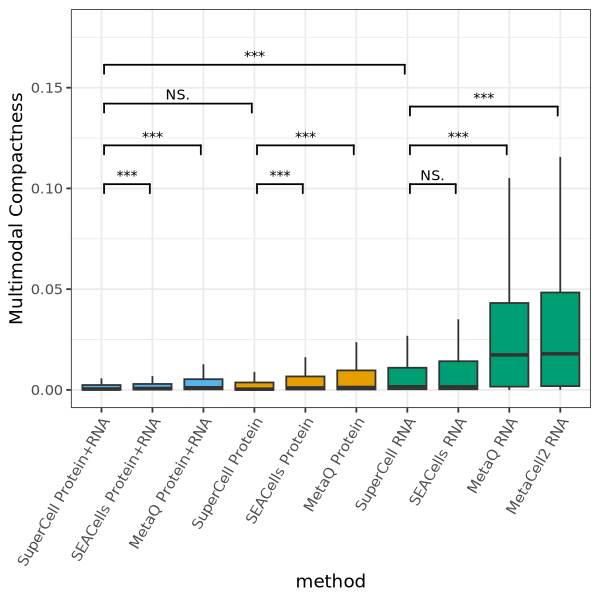

In [206]:
bench.20.unsup <- bench.20.no.random[!bench.20.no.random$tool %in% c("supSuperCell_testKNN","SuperCell_testKNN"),]

options(repr.plot.width=5, repr.plot.height=5)

sig.multimodal.compactness.g20  <- ggplot(bench.20.unsup,aes(y=multimodal_compactness,x = method,fill = input)) + 
  geom_boxplot(outlier.shape = NA) + theme_bw() +
  geom_signif(comparisons = comparisons.multi,step_increase=0.03,y_position = 0.07,tip_length = 0.007,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.protein,step_increase=0.03,y_position = 0.07,tip_length = 0.007,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.rna,step_increase=0.03,y_position = 0.07,tip_length = 0.007,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparison.inter.modality,y_position =0.11,tip_length = 0.007,step_increase=0.03,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  scale_x_discrete(guide = guide_axis(angle = 60)) + 
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Multimodal Compactness")  +  # Hides outliers
  coord_cartesian(ylim = c(0, 0.18))  + NoLegend()
sig.multimodal.compactness.g20

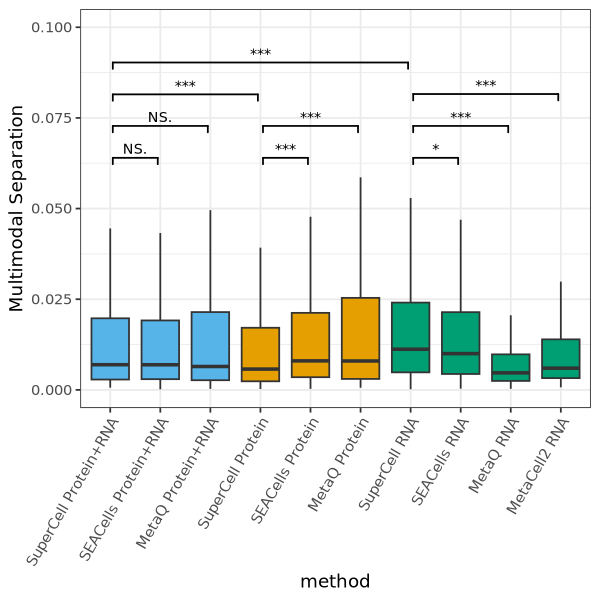

In [207]:
options(repr.plot.width=5, repr.plot.height=5)



sig.multimodal.separation.g20 <- ggplot(bench.20.unsup,aes(y=multimodal_separation,x = method,fill = input)) + 
  geom_boxplot(outlier.shape = NA) + theme_bw() +
  geom_signif(comparisons = comparisons.multi,step_increase=0.01,y_position = 0.02,tip_length = 0.002,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.protein,step_increase=0.01,y_position = 0.02,tip_length = 0.002,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.rna,step_increase=0.01,y_position = 0.02,tip_length = 0.002,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparison.inter.modality,y_position =0.0375,tip_length = 0.002,step_increase=0.01,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  scale_x_discrete(guide = guide_axis(angle = 60)) + 
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Multimodal Separation")  +
  coord_cartesian(ylim = c(0, 0.1))  + NoLegend()
sig.multimodal.separation.g20

# multimodal_separation.20 <- ggplot(bench.20[bench.20$method != "Random None",],aes(y=multimodal_separation,x = method,fill = input)) + 
#   geom_boxplot(outlier.shape = NA) +
#   scale_x_discrete(guide = guide_axis(angle = 60)) + 
#   theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Multimodal Separation")  +  # Hides outliers
#   coord_cartesian(ylim = c(0, limits$ymax)) + theme(axis.title.x = element_blank())  # Sets y-axis limits
# 
# 
# multimodal.separation.g20 <- cowplot::plot_grid(sig,multimodal_separation.20+ NoLegend(), rel_heights = c(0.2,0.8),align = "v",ncol = 1)
# 
# multimodal.separation.g20


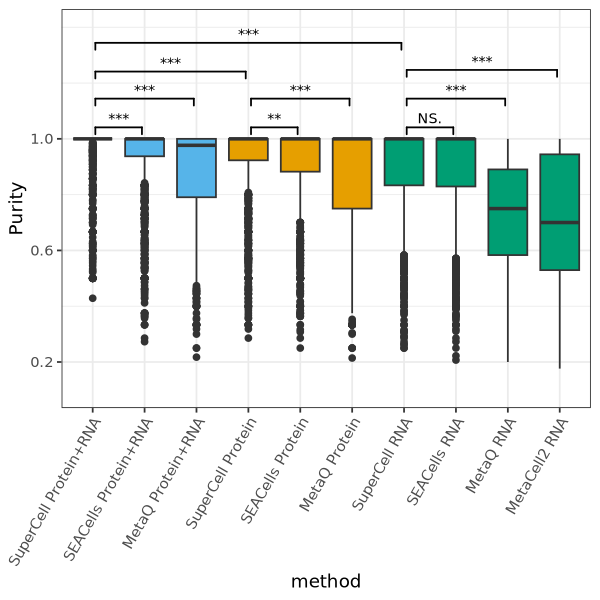

In [208]:
options(repr.plot.width=5, repr.plot.height=5)



# limits <- bench.75[bench.75$method != "Random None",] %>%
#   group_by(method) %>%
#   summarize(
#     ymin = min(celltype.l2_purity),
#     ymax = 1
#   ) %>%
#   ungroup() %>%
#   summarize(
#     ymin = min(ymin),
#     ymax = max(ymax)
#   )
# step_increase <- 0.075*0.25/(limits$ymax-limits$ymin)

# celltype.l2_purity.g20 <- ggplot(bench.20.no.random,aes(y=celltype.l2_purity,x = method,fill = input)) + 
#   geom_boxplot() + theme_bw() +
#   scale_x_discrete(guide = guide_axis(angle = 60)) + 
#   theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Purity") + theme(axis.title.x = element_blank())


# plot_data <- ggplot_build(celltype.l2_purity.g20)
# y_limits <- plot_data$layout$panel_params[[1]]$y.range
# 
# # step_increase <-  (3*0.075*0.25)/(y_limits[2]-y_limits[1])
# step_increase <-  .23*(1.3-1.02)
sig.celltype.l2_purity.g20  <- ggplot(bench.20.unsup,aes(y=celltype.l2_purity,x = method,fill = input)) + 
  geom_boxplot() + theme_bw() +
  #facet_wrap("gamma",nrow = 1) + 
  scale_y_continuous(limits = c(0.1,1.4),breaks = c(0.2,0.6,1)) +
  geom_signif(comparisons = comparisons.multi,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.protein,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.rna,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparison.inter.modality,y_position =1.2, ,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  scale_x_discrete(guide = guide_axis(angle = 60)) + 
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Purity")  +  # Hides outliers
  NoLegend()
sig.celltype.l2_purity.g20

# Hides outliers
#coord_cartesian(ylim = c(0, limits$ymax))   # Sets y-axis limits

# 
# celltype.l2_purity.g20 <-cowplot::plot_grid(sig,celltype.l2_purity.g20+ NoLegend(), rel_heights = c(0.2,0.8),align = "v",ncol = 1)
# celltype.l2_purity.g20

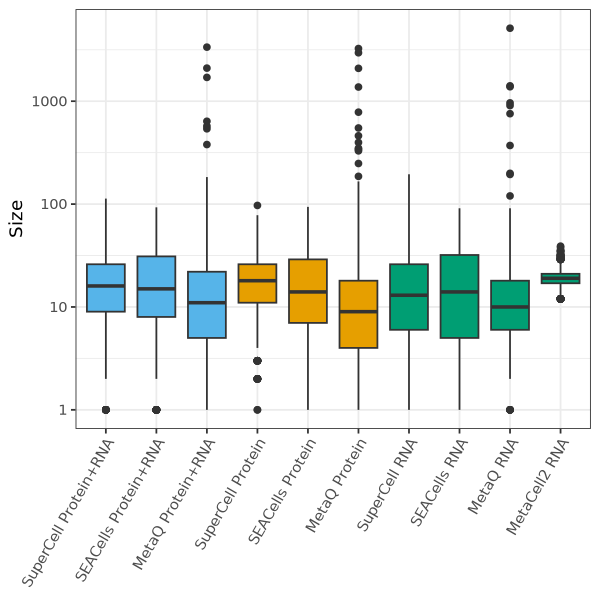

In [209]:
size.g20 <- ggplot(bench.20.unsup,aes(y=size,x = method,fill = input)) + 
  geom_boxplot() + theme_bw() + 
  scale_x_discrete(guide = guide_axis(angle = 60)) + scale_y_log10() +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Size") + theme(axis.title.x = element_blank()) + NoLegend()
size.g20

## Fig

Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 189 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 189 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 189 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 189 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 189 

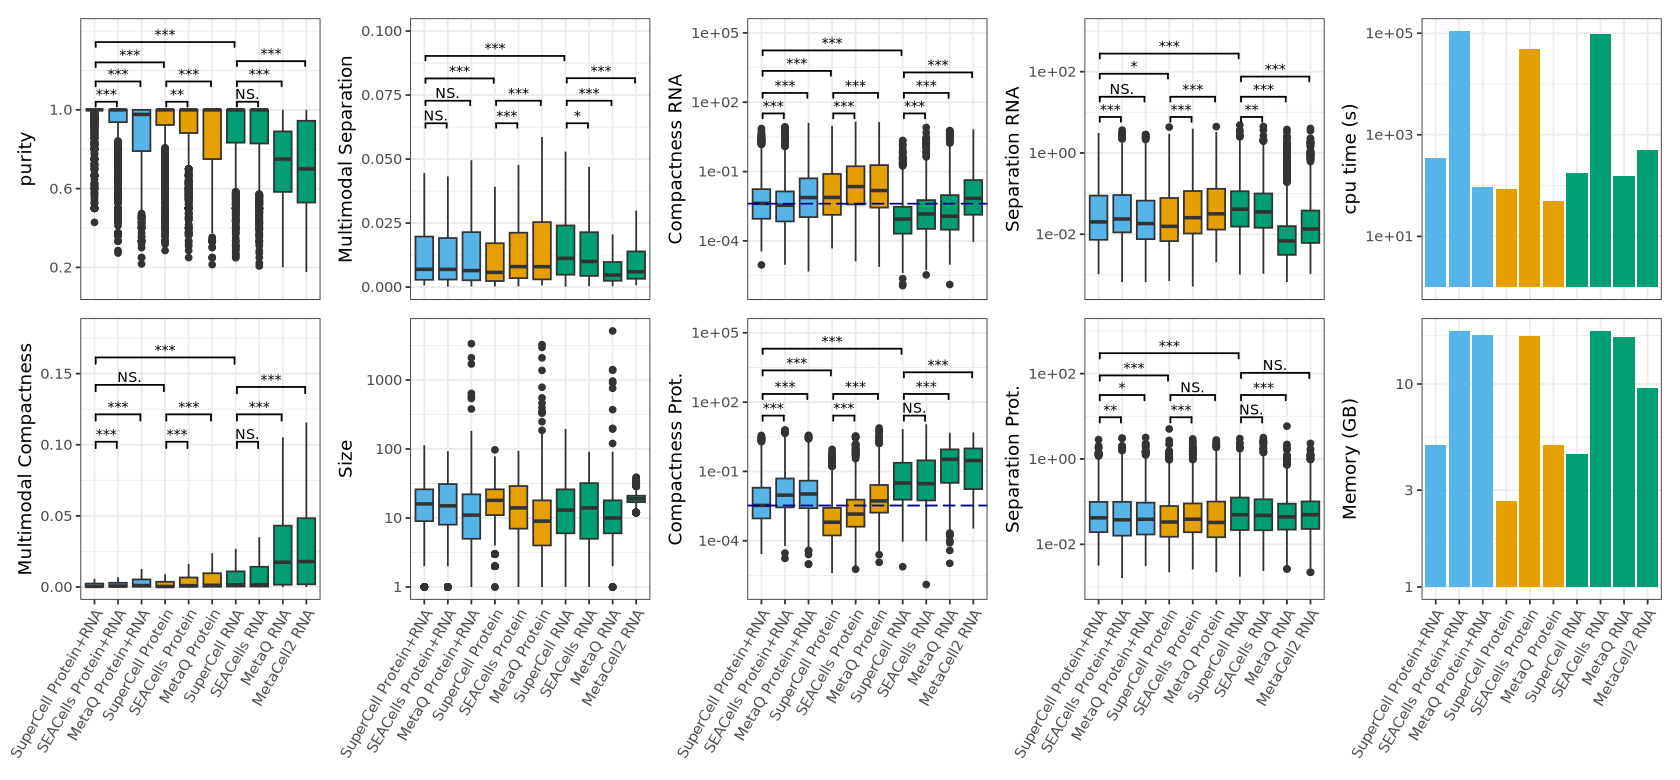

In [210]:
options(repr.plot.width=14, repr.plot.height=6.5)

# figS2EF <- cowplot::plot_grid(purity.bmc.cite.g20+ NoLegend() + theme(axis.title.x = element_blank()),
#                               sig.multimodal.compactness.g20+ NoLegend() + theme(axis.title.x = element_blank()),
#                               sig.multimodal.separation.g20+ NoLegend() + theme(axis.title.x = element_blank()),
#                               size.g20 + NoLegend() + theme(axis.title.x = element_blank()),
#                               compactness_pca.bmc.cite.g20+ NoLegend() + theme(axis.title.x = element_blank()),
#                               compactness_apca.bmc.cite.g20 + NoLegend() + theme(axis.title.x = element_blank()),
#                               separation_pca.g20 + NoLegend() + theme(axis.title.x = element_blank()),
#                               separation_apca.g20 + NoLegend() + theme(axis.title.x = element_blank()),
#                               cite.cpu.time.plot.g20+ theme(axis.title.x = element_blank()) + NoLegend(),
#                               cite.memory.plot.g20+ theme(axis.title.x = element_blank())+ NoLegend(),
#                               leg.input,
#                               byrow = F,nrow = 2)

figS2EF <- wrap_plots(purity.bmc.cite.g20+ NoLegend() + theme(axis.title.x = element_blank()),
                              sig.multimodal.compactness.g20+ NoLegend() + theme(axis.title.x = element_blank()),
                              sig.multimodal.separation.g20+ NoLegend() + theme(axis.title.x = element_blank()),
                              size.g20 + NoLegend() + theme(axis.title.x = element_blank()),
                              compactness_pca.bmc.cite.g20+ NoLegend() + theme(axis.title.x = element_blank()),
                              compactness_apca.bmc.cite.g20 + NoLegend() + theme(axis.title.x = element_blank()),
                              separation_pca.g20 + NoLegend() + theme(axis.title.x = element_blank()),
                              separation_apca.g20 + NoLegend() + theme(axis.title.x = element_blank()),
                              cite.cpu.time.plot.g20+ theme(axis.title.x = element_blank()) + NoLegend(),
                              cite.memory.plot.g20+ theme(axis.title.x = element_blank())+ NoLegend(),axes = "collect",axis_titles = "collect",
                              byrow = F,nrow = 2)
figS2EF

In [211]:
pdf(file = "../../../pdf_files/FigS2/figS2EF_g20.pdf",height = 6.5,width=14)
figS2EF
dev.off()

Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 120000)):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 189 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 189 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 189 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 189 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 189 

agg_record_1235820917 
                    2

Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph

22:47:27 UMAP embedding parameters a = 0.9922 b = 1.112

22:47:28 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 20

22:47:29 Initializing from normalized Laplacian + noise (using RSpectra)

22:47:32 Commencing optimization for 200 epochs, with 1081742 positive edges

22:47:32 Using rng type: pcg

22:47:59 Optimization finished

Warning message:
“No assay specified, setting assay as RNA by default.”
Warning message:
“No assay specified, setting assay as RNA by default.”


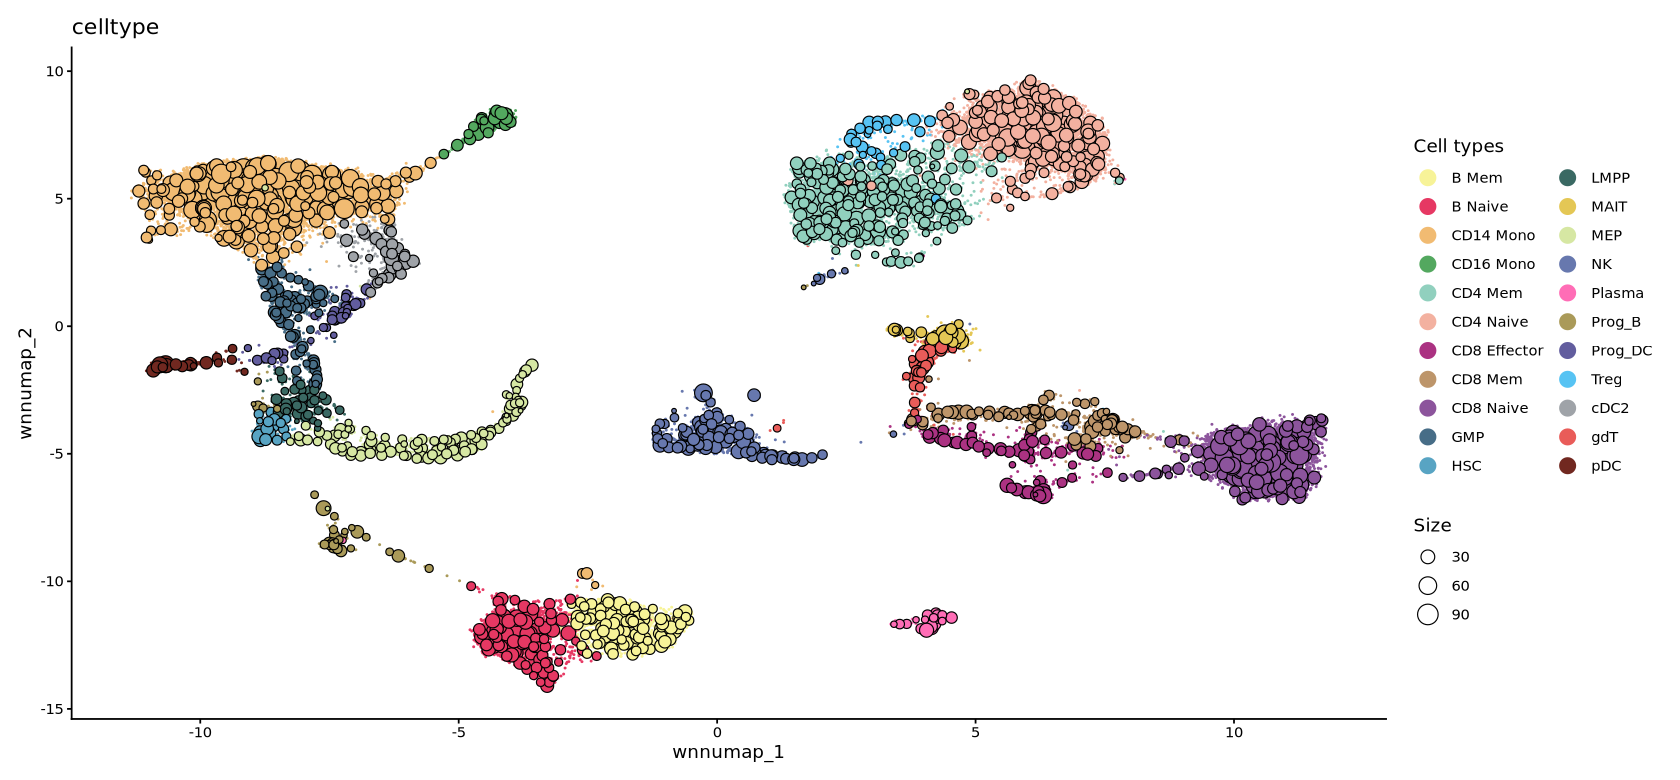

In [182]:
bm.supercell.multi.g20 <- readRDS(paste0(datadir,"/output/bmCiteSeq//SuperCellMulti//g20/seurat.cite.mc.rds"))
bm.supercell.multi.g20 <- addCellType(bm.supercell.multi.g20)
# figSupCov <- DimPlotSC(seurat = bm,
#                        seurat.mc = bm.supercell.multi.g20,
#                        metacell.col = "celltype",
#                        sc.col = "celltype",
#                        mc.color = color.celltypes.bm,
#                        sc.color = color.celltypes.bm) + theme_classic()  +
#   guides(fill=guide_legend(ncol =2,title = "Cell types",
#                            override.aes = list(size=4)),
#          colour = "none",
#          size = guide_legend(title = "Size"))

figSupMcScg20 <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = bm,
  sobj.mc = bm.supercell.multi.g20,
  dimred_1 = "pca",
  dimred_2= "apca",
  dims.list = list(1:30, 1:18),
  cols = color.celltypes.bm,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic()  +
  guides(colour=guide_legend(ncol =2,title = "Cell types",
                             override.aes = list(size=4)),
         size = guide_legend(title = "Size"))

figSupMcScg20

Sparsity reduction g20

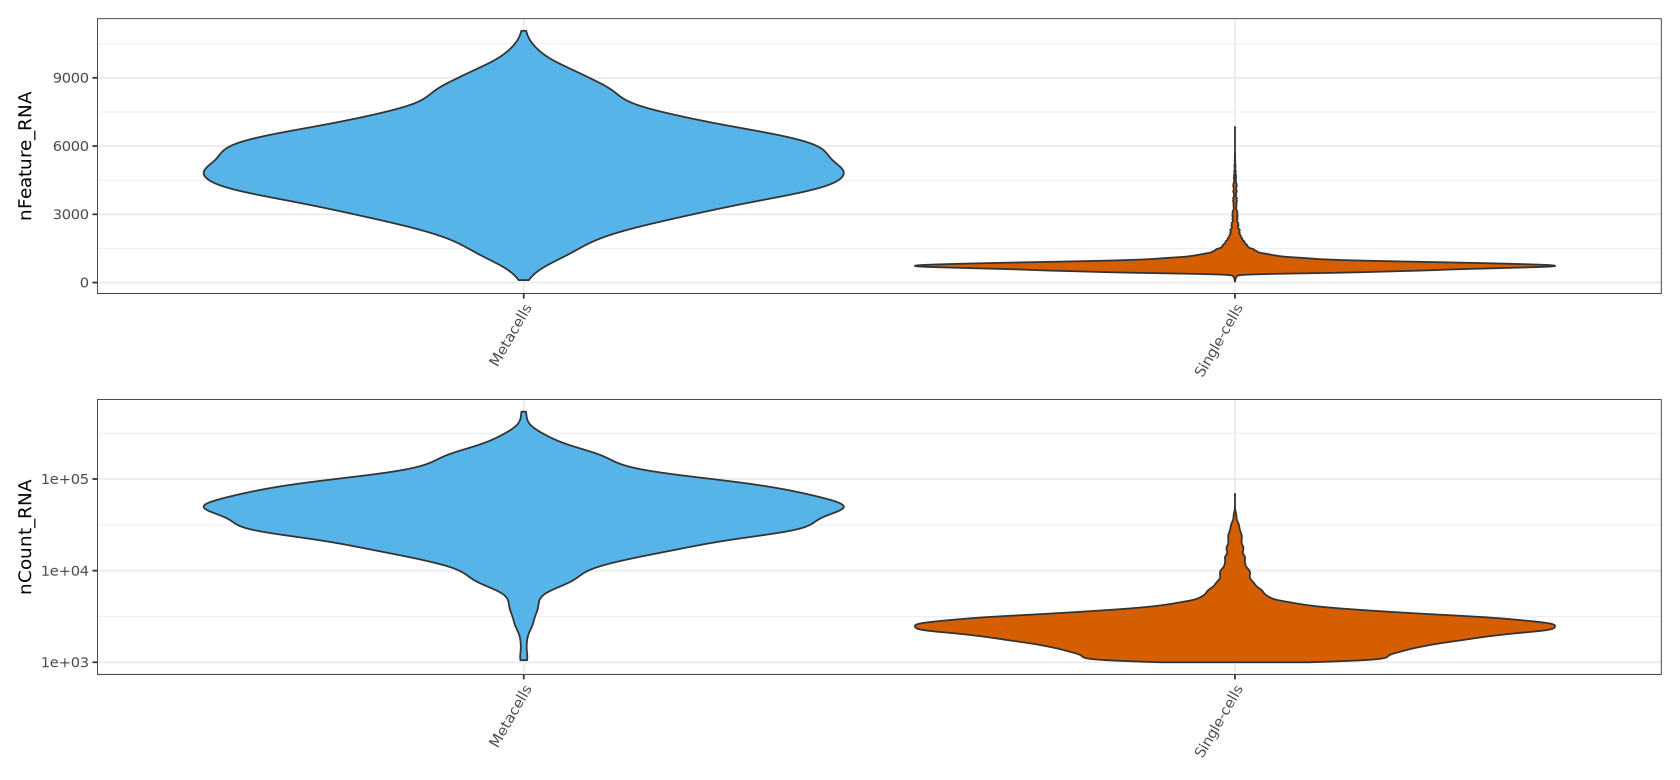

In [183]:
bm$resolution <- "Single-cells"
bm.supercell.multi.g20$resolution <- "Metacells"
meta.sc.mc <- rbind(bm@meta.data[,c("nCount_RNA","nFeature_RNA","resolution")],
                    bm.supercell.multi.g20@meta.data[,c("nCount_RNA","nFeature_RNA","resolution")])

meta.sc.mc$resolution <- factor(meta.sc.mc$resolution,levels = c("Metacells","Single-cells"))

nFeature_RNA <- ggplot(meta.sc.mc,aes(x=resolution,y=nFeature_RNA,fill = resolution)) + geom_violin(scale = "width") + theme_bw() + 
  theme(axis.title.x = element_blank())  +
  scale_x_discrete(guide = guide_axis(angle = 60)) + 
  scale_fill_manual(values = c("#56B4E9", "#D55E00")) #colorblind_pal()(8)[c(3,7)]


nCount_RNA <- ggplot(meta.sc.mc,aes(x=resolution,y=nCount_RNA,fill = resolution)) + geom_violin(scale = "width")  + theme_bw() + 
  theme(axis.title.x = element_blank())  + scale_y_log10() +
  scale_x_discrete(guide = guide_axis(angle = 60)) + 
  scale_fill_manual(values = c("#56B4E9", "#D55E00")) #colorblind_pal()(8)[c(3,7)]


sparsity.reduction.counts.g20 <- wrap_plots(nFeature_RNA+ NoLegend(),nCount_RNA+ NoLegend(),ncol = 1)

sparsity.reduction.counts.g20

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


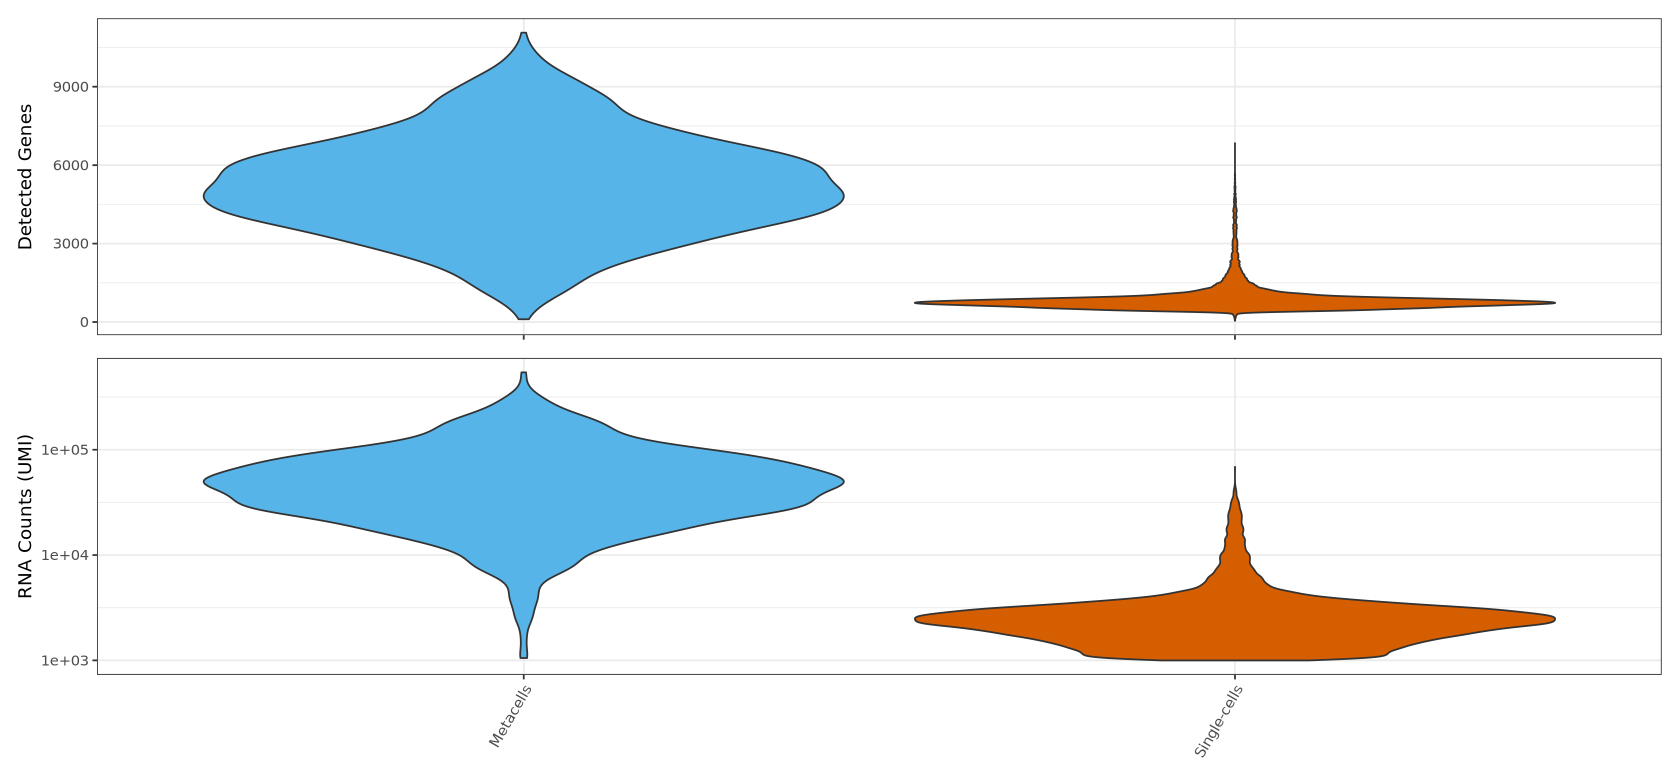

In [184]:
nFeature_RNA <- nFeature_RNA  + NoLegend() +
  theme(axis.text.x = element_blank(),axis.title.x = element_blank()) + ylab("Detected Genes")

nCount_RNA <-  nCount_RNA + NoLegend() +
  theme(axis.title.x = element_blank())  +
  scale_x_discrete(guide = guide_axis(angle = 60))+ ylab("RNA Counts (UMI)")

sparsity.reduction.g20 <- nFeature_RNA / nCount_RNA + plot_layout(heights = c(1, 1))
sparsity.reduction.g20


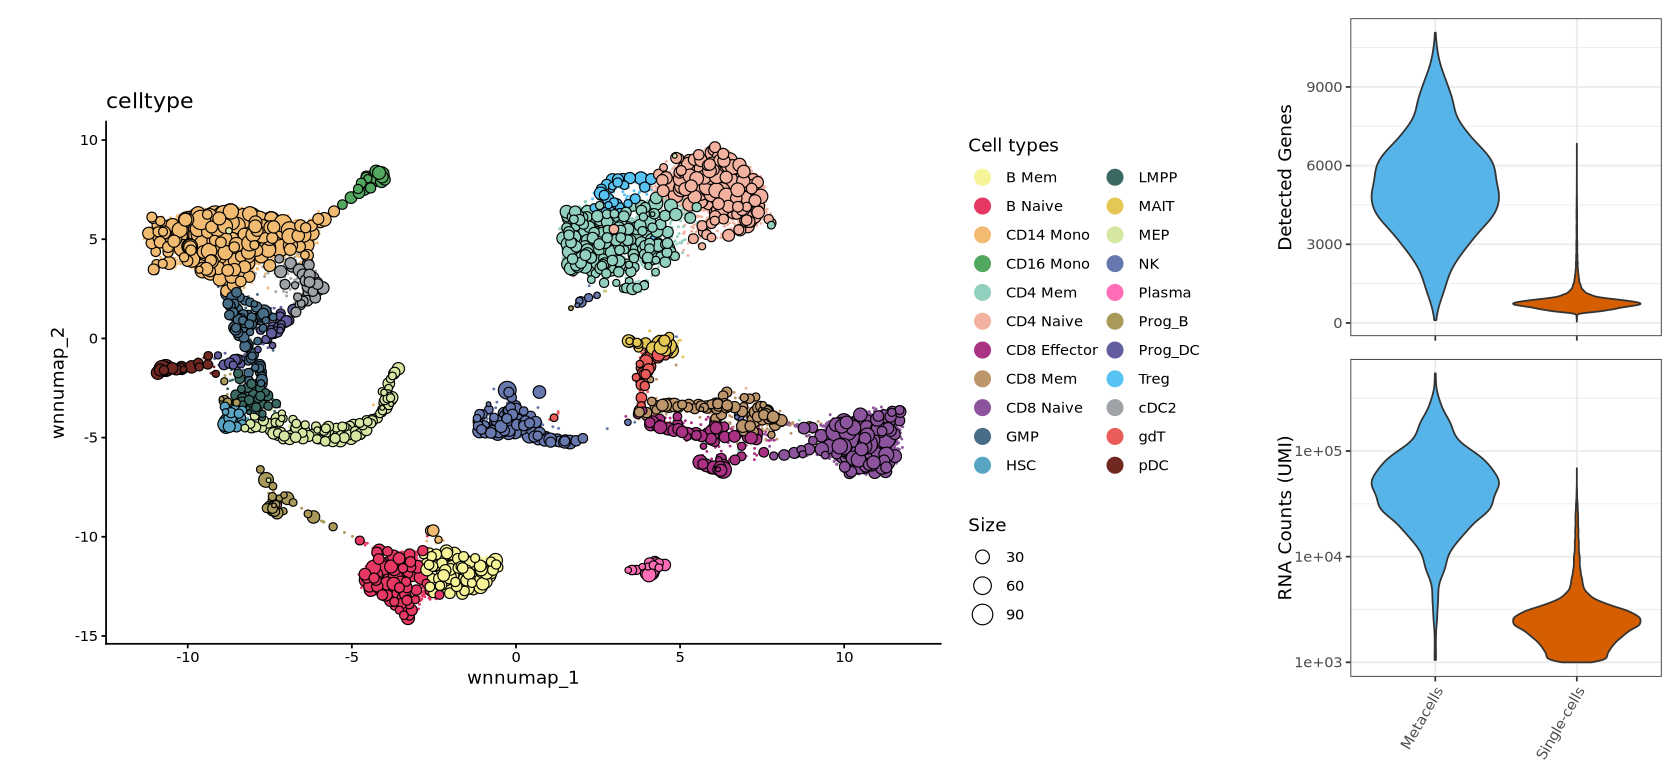

In [185]:
figS2CD <- cowplot::plot_grid(figSupMcScg20+theme(plot.margin = unit(c(50,25,50,25),units = "pt")),
                              wrap_plots(nFeature_RNA, nCount_RNA,ncol = 1),rel_widths = c(3,1))

figS2CD

In [186]:
pdf(file = "../../../pdf_files/FigS2/figS2CD.pdf",height = 5,width=9)
figS2CD
dev.off()

agg_record_1491625056 
                    2

## Heatmap of wilcoxon results gamma 20

In [212]:
library(dplyr)
library(purrr)
library(tidyr)
cols <- c("method","purity","multimodal_compactness","multimodal_separation")

bench.20.no.random$purity <- bench.20.no.random$celltype.l2_purity


results <- ComputePairwiseWilcox(bench.results = bench.20.no.random)


#signif(results$RBC,digits = 5) == signif(results$RBC2,digits = 5)

head(results)

metric,group1,group2,n1,n2,W,RBC,p,padj,logP,logFDR
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
multimodal_compactness,SuperCell Protein+RNA,SEACells Protein+RNA,22995,1533,15098690,-0.143369152,4.785851e-21,8.614532e-21,20.3200408,20.0647683
multimodal_compactness,SuperCell Protein+RNA,MetaQ Protein+RNA,22995,1450,13265182,-0.204313891,4.925647e-39,1.007519e-38,38.3075367,37.9967469
multimodal_compactness,SuperCell Protein+RNA,SuperCell Protein,22995,1533,17769230,0.008145082,5.927787e-01,6.133609e-01,0.2271074,0.2122839
multimodal_compactness,SuperCell Protein+RNA,SEACells Protein,22995,1533,14333132,-0.186803450,1.383562e-34,2.706970e-34,33.8590012,33.5675166
multimodal_compactness,SuperCell Protein+RNA,MetaQ Protein,22995,1439,12619624,-0.237250023,1.160444e-51,2.748420e-51,50.9353758,50.5609169
multimodal_compactness,SuperCell Protein+RNA,SuperCell RNA,22995,1533,12179994,-0.308962653,1.680300e-91,6.301127e-91,90.7746131,90.2005818


In [213]:
library(dplyr)
library(ggplot2)

# Keep the condition order you want in the plot
condition_order <- rev(c('SuperCell Protein+RNA',"SEACells Protein+RNA","MetaQ Protein+RNA",
                         "SuperCell Protein","SEACells Protein","MetaQ Protein",
                         'SuperCell RNA',"SEACells RNA","MetaQ RNA","MetaCell2 RNA"))


results_plot <- results %>%
  mutate(
    group1 = factor(group1, levels = condition_order),
    group2 = factor(group2, levels = rev(condition_order))
  ) %>%
  filter(
    #as.numeric(group1) > as.numeric(group2),
    p < 0.05
  )

head(results_plot)

metric,group1,group2,n1,n2,W,RBC,p,padj,logP,logFDR
<chr>,<fct>,<fct>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
multimodal_compactness,SuperCell Protein+RNA,SEACells Protein+RNA,22995,1533,15098690,-0.1433692,4.785851e-21,8.614532e-21,20.32004,20.06477
multimodal_compactness,SuperCell Protein+RNA,MetaQ Protein+RNA,22995,1450,13265182,-0.2043139,4.925647e-39,1.007519e-38,38.30754,37.99675
multimodal_compactness,SuperCell Protein+RNA,SEACells Protein,22995,1533,14333132,-0.1868035,1.383562e-34,2.706970e-34,33.85900,33.56752
multimodal_compactness,SuperCell Protein+RNA,MetaQ Protein,22995,1439,12619624,-0.2372500,1.160444e-51,2.748420e-51,50.93538,50.56092
multimodal_compactness,SuperCell Protein+RNA,SuperCell RNA,22995,1533,12179994,-0.3089627,1.680300e-91,6.301127e-91,90.77461,90.20058
multimodal_compactness,SuperCell Protein+RNA,SEACells RNA,22995,1533,12166232,-0.3097435,5.915585e-92,2.420012e-91,91.22800,90.61618


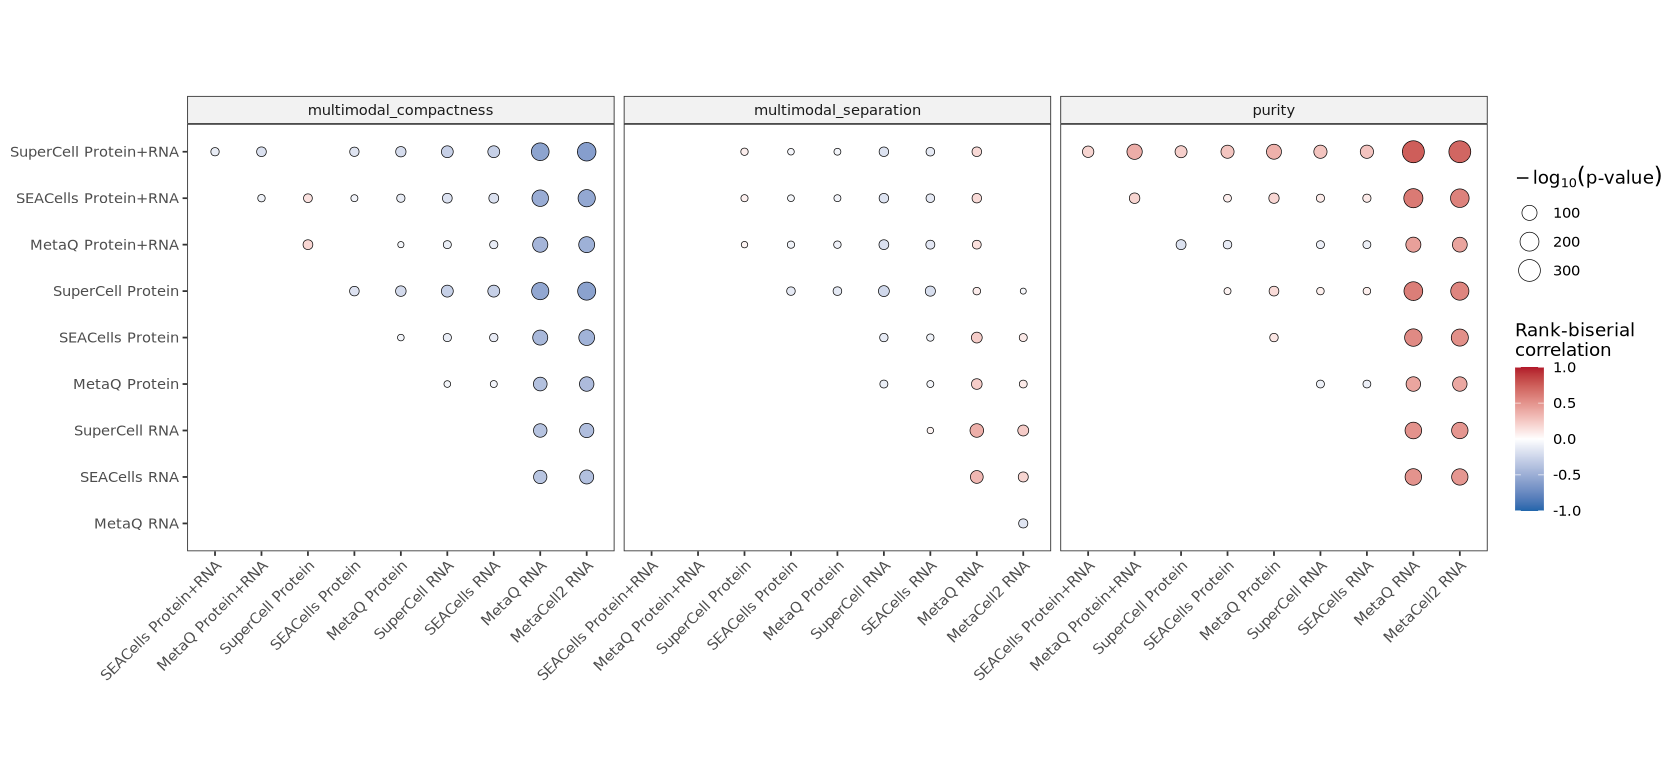

In [189]:



heatmap_wilcox <- HeatmapWilcox(results_plot)
heatmap_wilcox

In [190]:
pdf(file = "../../../pdf_files/FigS2/figSuppHMWilcoxg20.pdf",height=4,width=8)
heatmap_wilcox
dev.off()

agg_record_1436235309 
                    2

## Test k_nn

In [214]:


test_knn <- rbind(bench.20.no.random[bench.20.no.random$tool %in% c("supSuperCell_testKNN","SuperCell_testKNN"),c(cn,"multimodal_compactness","multimodal_separation")],
                  bench.75.no.random[bench.75.no.random$tool %in% c("supSuperCell_testKNN","SuperCell_testKNN"),c(cn,"multimodal_compactness","multimodal_separation")]
                 )
table(test_knn$tool,test_knn$k_nn)

                      
                         10   20   30   40   60   80  100
  SuperCell_testKNN    1941 1941 1941 1941 1941 1941 1941
  supSuperCell_testKNN 1941 1941 1941 1941 1941 1941 1941

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 181 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 181 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


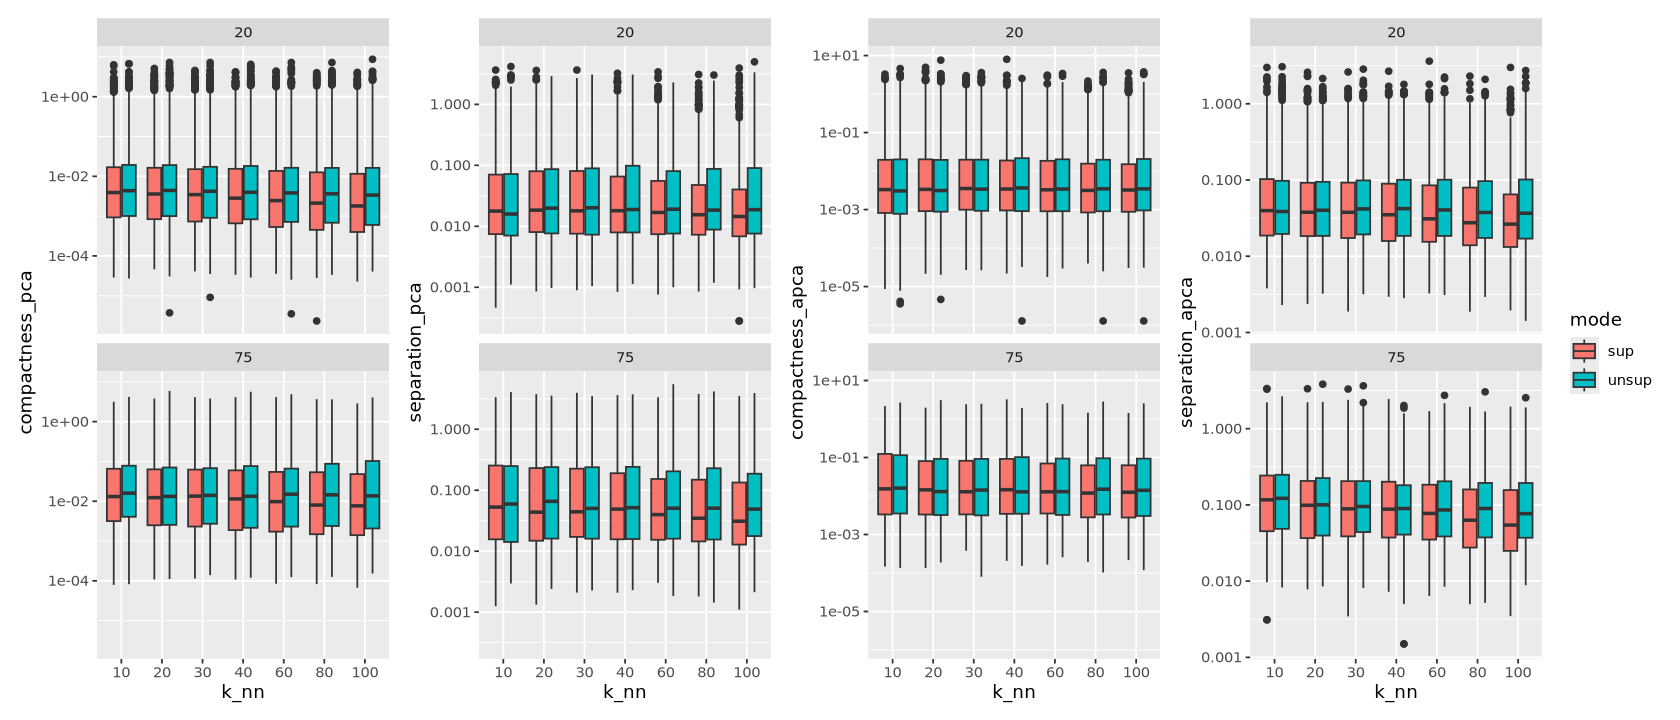

In [218]:

test_knn$k_nn <- as.factor(test_knn$k_nn)
test_knn$mode <- "unsup"
test_knn$mode[test_knn$tool == "supSuperCell_testKNN"] <- "sup"



unsup_knn.purity <- ggplot(test_knn,aes(x = k_nn,y = celltype.l2_purity,fill = mode)) + 
geom_boxplot() + facet_wrap('~gamma',nrow = 2)
unsup_knn.size <- ggplot(test_knn,aes(x = k_nn,y = size,fill = mode)) + geom_boxplot()  + 
facet_wrap('~gamma',nrow = 2)
compactness.pca <- ggplot(test_knn,aes(x = k_nn,y = compactness_pca,fill = mode)) + 
geom_boxplot()  + 
facet_wrap('~gamma',nrow = 2) + 
scale_y_log10()
separation.pca <- ggplot(test_knn,aes(x = k_nn,y = separation_pca,fill = mode)) + 
geom_boxplot()  + 
facet_wrap('~gamma',nrow = 2) + 
scale_y_log10()
compactness.apca <- ggplot(test_knn,aes(x = k_nn,y = compactness_apca,fill = mode)) + 
geom_boxplot()  + 
facet_wrap('~gamma',nrow = 2)  + 
scale_y_log10()
separation.apca <- ggplot(test_knn,aes(x = k_nn,y = separation_apca,fill = mode)) + 
geom_boxplot() + 
facet_wrap('~gamma',nrow = 2)  + 
scale_y_log10()

multimodal_compactness <- ggplot(test_knn,aes(x = k_nn,y = multimodal_compactness,fill = mode)) + 
geom_boxplot()  + 
facet_wrap('~gamma',nrow = 2)  
multimodal_separation <- ggplot(test_knn,aes(x = k_nn,y = multimodal_separation,fill = mode)) + 
geom_boxplot() + 
facet_wrap('~gamma',nrow = 2)  


patchwork::wrap_plots(compactness.pca , separation.pca,
                      compactness.apca , separation.apca,guides = "collect",nrow  = 1)

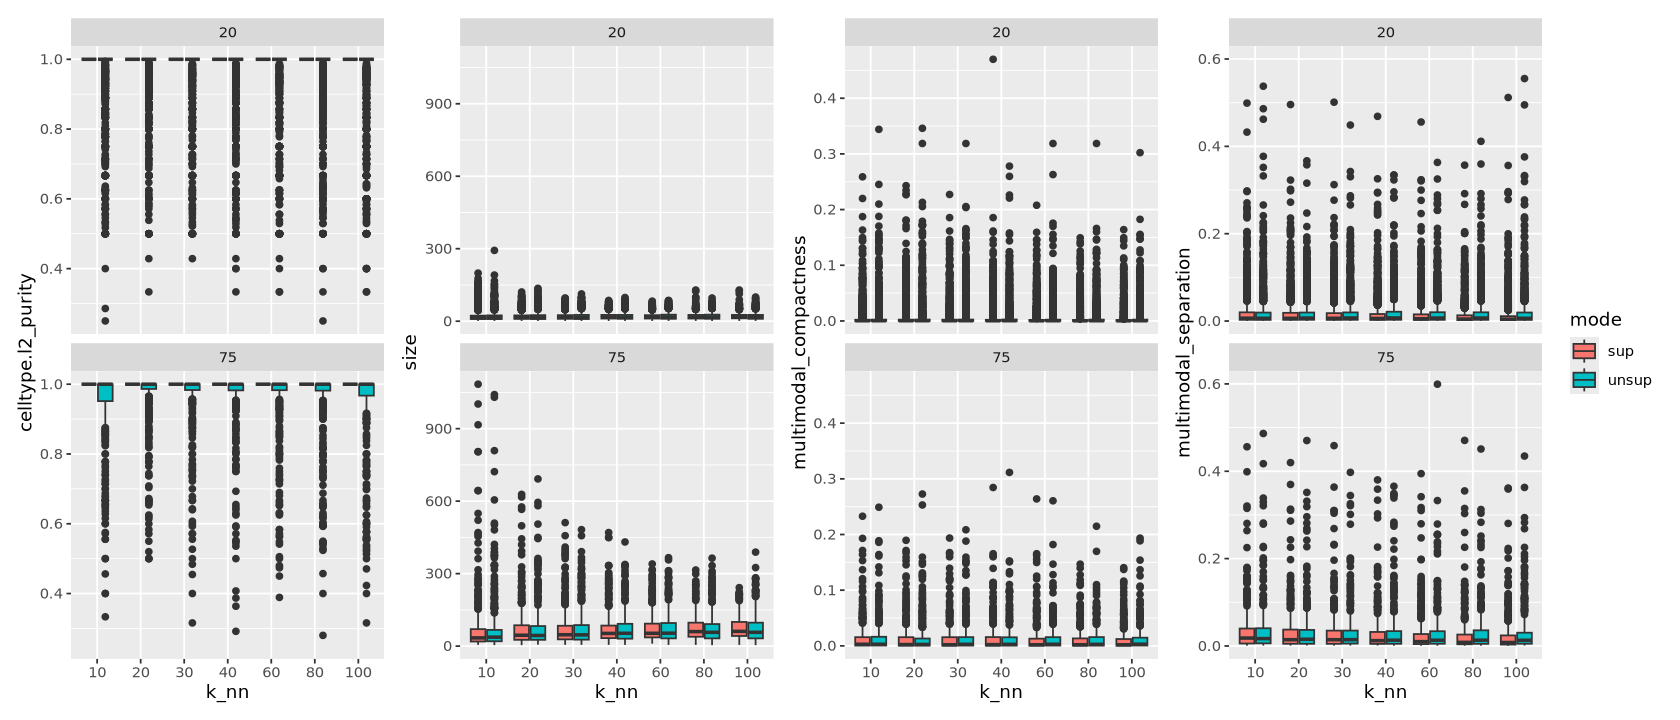

In [219]:
options(repr.plot.width=14, repr.plot.height=6)
patchwork::wrap_plots(unsup_knn.purity , unsup_knn.size,multimodal_compactness,multimodal_separation,guides = "collect",nrow  = 1)

## Anti correlation

Normalizing layer: counts

Normalizing across cells

Normalizing layer: counts

Normalizing across cells

Normalizing layer: counts

Normalizing across cells

Normalizing layer: counts

Normalizing across cells

Normalizing layer: counts

Normalizing across cells

Normalizing layer: counts

Normalizing across cells



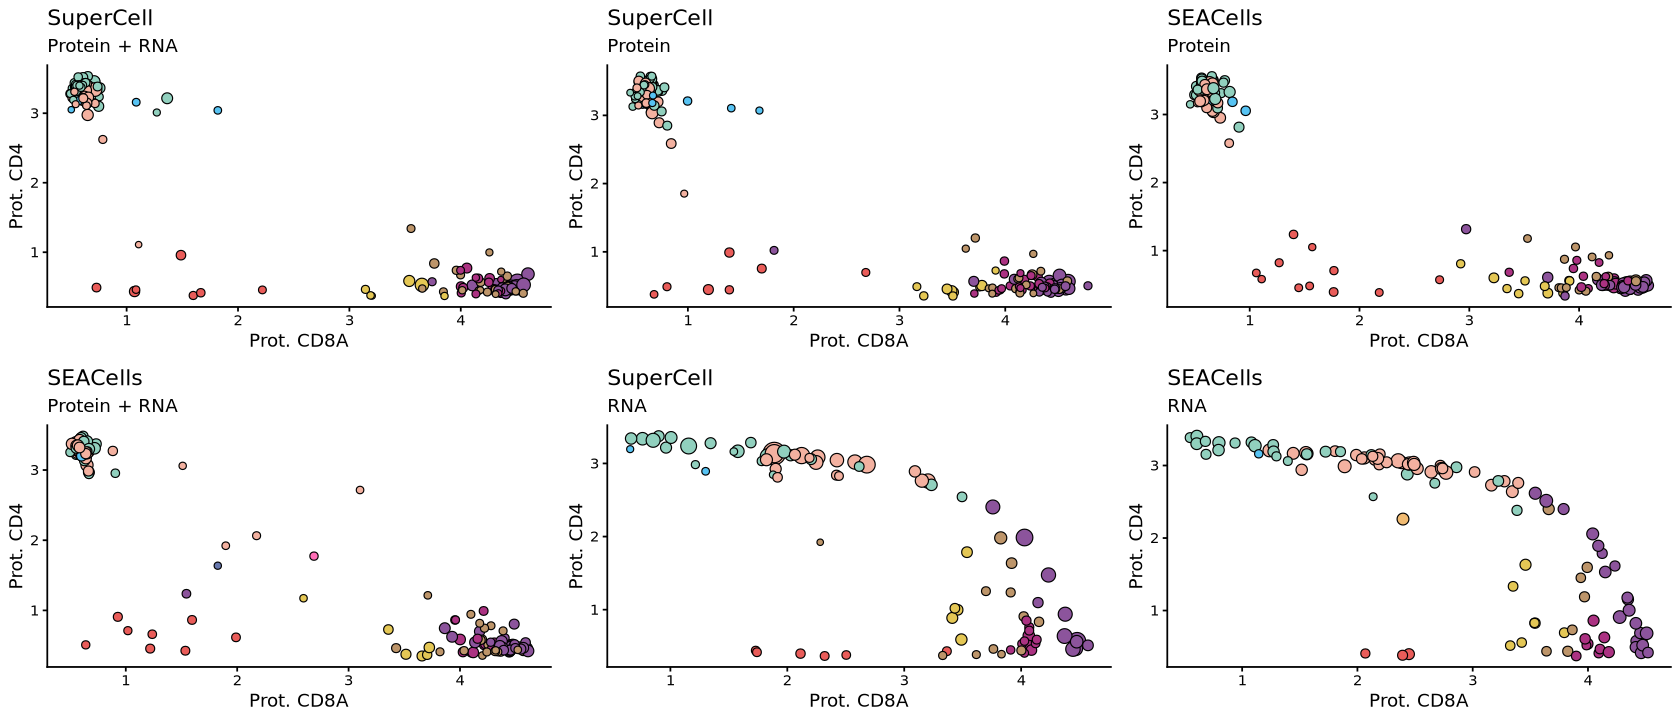

In [220]:
acr.prot.sc <- FeatureScatter(bm[,bm$celltype.l1 %in% "T cell" ],"adt_CD8a","adt_CD4",group.by = "celltype", cols = color.celltypes.bm,plot.cor = F) + xlab("Prot. CD8A") + ylab("Prot. CD4")

DefaultAssay(bm.supercell.multi) <- "ADT"
bm.supercell.multi <- NormalizeData(bm.supercell.multi,normalization.method = "CLR",margin = 2)

max.acr.size.main <- max(bench.75.unsup$size[bench.75.unsup$tool %in% c("SuperCell","SEACells") & bench.75.unsup$celltype.l1 %in% c("T cell","Progenitor cells")])


acr.prot.supercell.multi <- FeatureScatter.SuperCell(bm.supercell.multi[,bm.supercell.multi$celltype.l1 %in% "T cell" ],
                                                     "adt_CD8a","adt_CD4",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("Prot. CD8A") + ylab("Prot. CD4")  + ggtitle(label = "SuperCell",subtitle = "Protein + RNA")  + theme_classic()  +
                                scale_size(limits = c(0,max.acr.size.main),
                                           breaks = c(50,100,200,400))


DefaultAssay(bm.supercell.rna) <- "ADT"
bm.supercell.rna <- NormalizeData(bm.supercell.rna,normalization.method = "CLR",margin = 2)

acr.prot.supercell.rna <- FeatureScatter.SuperCell(bm.supercell.rna[,bm.supercell.rna$celltype.l1 %in% "T cell" ],
                                                   "adt_CD8a","adt_CD4",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("Prot. CD8A") + ylab("Prot. CD4") + ggtitle(label = "SuperCell",subtitle = "RNA")  + theme_classic()  + NoLegend() +
                                scale_size(limits = c(0,max.acr.size.main),
                                           breaks = c(50,100,200,400))


DefaultAssay(bm.supercell.adt) <- "ADT"
bm.supercell.adt <- NormalizeData(bm.supercell.adt,normalization.method = "CLR",margin = 2)

acr.prot.supercell.prot <- FeatureScatter.SuperCell(bm.supercell.adt[,bm.supercell.adt$celltype.l1 %in% "T cell" ],
                                                    "adt_CD8a","adt_CD4",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("Prot. CD8A") + ylab("Prot. CD4") + ggtitle(label = "SuperCell",subtitle = "Protein")  + theme_classic()  + NoLegend() +
                                scale_size(limits = c(0,max.acr.size.main),
                                           breaks = c(50,100,200,400))


DefaultAssay(bm.seacells.mofa) <- "ADT"
bm.seacells.mofa <- NormalizeData(bm.seacells.mofa,normalization.method = "CLR",margin = 2)

acr.prot.seacells.mofa <- FeatureScatter.SuperCell(bm.seacells.mofa[,bm.seacells.mofa$celltype.l1 %in% "T cell" ],
                                                  "adt_CD8a","adt_CD4",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("Prot. CD8A") + ylab("Prot. CD4") + ggtitle(label = "SEACells",subtitle ="Protein + RNA")  + theme_classic()  + NoLegend() +
                                scale_size(limits = c(0,max.acr.size.main),
                                           breaks = c(50,100,200,400))



DefaultAssay(bm.seacells.rna) <- "ADT"
bm.seacells.rna <- NormalizeData(bm.seacells.rna,normalization.method = "CLR",margin = 2)

acr.prot.seacells.rna <- FeatureScatter.SuperCell(bm.seacells.rna[,bm.seacells.rna$celltype.l1 %in% "T cell" ],
                                                  "adt_CD8a","adt_CD4",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("Prot. CD8A") + ylab("Prot. CD4") + ggtitle(label = "SEACells",subtitle = "RNA")  + theme_classic()  + NoLegend() +
                                scale_size(limits = c(0,max.acr.size.main),
                                           breaks = c(50,100,200,400))


DefaultAssay(bm.seacells.adt) <- "ADT"
bm.seacells.adt <- NormalizeData(bm.seacells.adt,normalization.method = "CLR",margin = 2)

acr.prot.seacells.prot <- FeatureScatter.SuperCell(bm.seacells.adt[,bm.seacells.adt$celltype.l1 %in% "T cell" ],
                                                   "adt_CD8a","adt_CD4",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("Prot. CD8A") + ylab("Prot. CD4")  + ggtitle(label = "SEACells",subtitle = "Protein") + theme_classic()  + NoLegend() +
                                scale_size(limits = c(0,max.acr.size.main),
                                           breaks = c(50,100,200,400))





cowplot::plot_grid(acr.prot.supercell.multi + NoLegend(),acr.prot.supercell.prot,acr.prot.seacells.prot,
                   acr.prot.seacells.mofa,acr.prot.supercell.rna,acr.prot.seacells.rna)

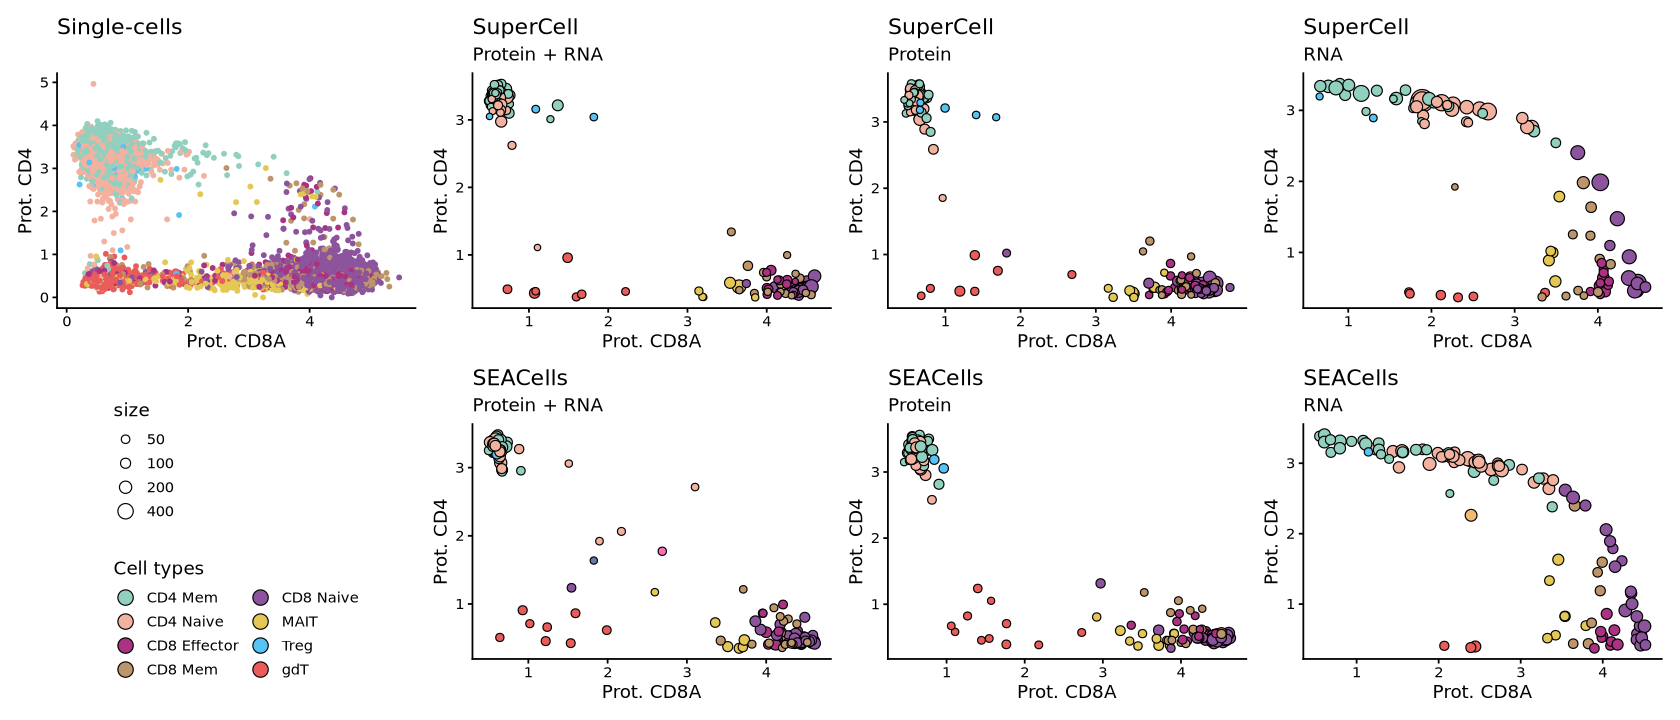

In [221]:


fig2G <- wrap_plots(acr.prot.sc + ggtitle("Single-cells") + theme_classic() + NoLegend(),
                    acr.prot.supercell.multi + 
                      guides( fill = guide_legend(ncol =2,title = "Cell types",
                                                  override.aes = list(size=4))  # One column for colors
                              )+ theme(legend.key.size = unit(1, 'lines')),acr.prot.supercell.prot,acr.prot.supercell.rna,
                    guide_area(),acr.prot.seacells.mofa,acr.prot.seacells.prot,acr.prot.seacells.rna,guides = "collect",nrow = 2)
fig2G

Normalizing layer: counts

Normalizing across cells

Normalizing layer: counts

Normalizing across cells

Normalizing layer: counts

Normalizing across cells

Normalizing layer: counts

Normalizing across cells



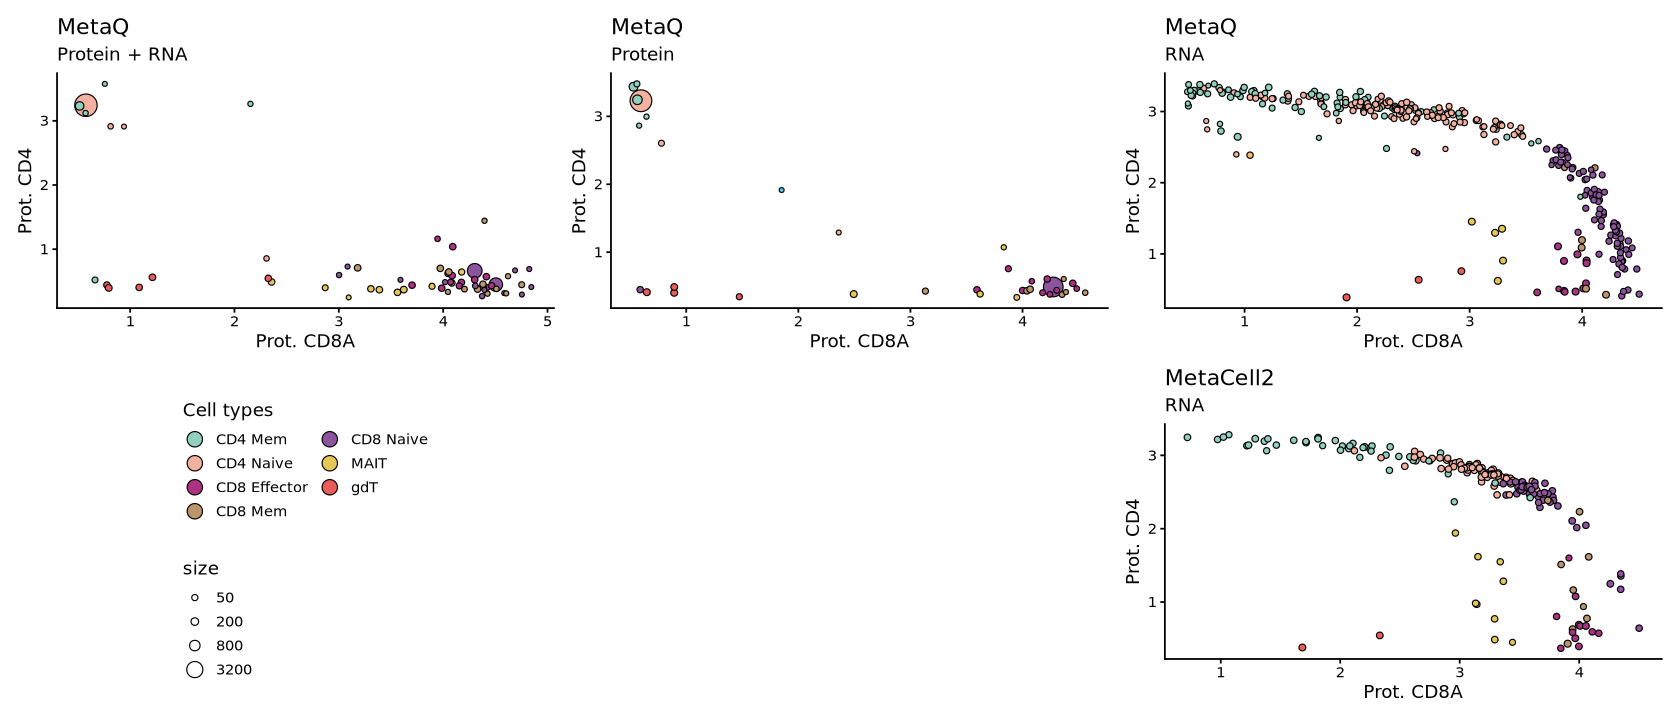

In [222]:
DefaultAssay(bm.metaq.multi) <- "ADT"
bm.metaq.multi <- NormalizeData(bm.metaq.multi,normalization.method = "CLR",margin = 2)
max.acr.size.supp <- max(bench.75.unsup$size[bench.75.unsup$tool %in% c("MetaQ","MetaCell2") & bench.75.unsup$celltype.l1 %in% c("T cell","Progenitor cells")])


acr.prot.metaq.multi <- FeatureScatter.SuperCell(bm.metaq.multi[,bm.metaq.multi$celltype.l1 %in% "T cell" ],
                                                     "adt_CD8a","adt_CD4",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("Prot. CD8A") + ylab("Prot. CD4")  + ggtitle(label = "MetaQ",subtitle = "Protein + RNA")  + theme_classic()  +
                                scale_size(limits = c(0,max.acr.size.supp),
                                           breaks = c(50,200,800,3200))


DefaultAssay(bm.metaq.rna) <- "ADT"
bm.metaq.rna <- NormalizeData(bm.metaq.rna,normalization.method = "CLR",margin = 2)

acr.prot.metaq.rna <- FeatureScatter.SuperCell(bm.metaq.rna[,bm.metaq.rna$celltype.l1 %in% "T cell" ],
                                                   "adt_CD8a","adt_CD4",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("Prot. CD8A") + ylab("Prot. CD4") + ggtitle(label = "MetaQ",subtitle = "RNA")  + theme_classic()  + NoLegend() +
                                scale_size(limits = c(0,max.acr.size.supp),
                                           breaks =c(50,200,800,3200)) 


DefaultAssay(bm.metaq.adt) <- "ADT"
bm.metaq.adt <- NormalizeData(bm.metaq.adt,normalization.method = "CLR",margin = 2)

acr.prot.metaq.prot <- FeatureScatter.SuperCell(bm.metaq.adt[,bm.metaq.adt$celltype.l1 %in% "T cell" ],
                                                    "adt_CD8a","adt_CD4",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("Prot. CD8A") + ylab("Prot. CD4") + ggtitle(label = "MetaQ",subtitle = "Protein")  + theme_classic()  + NoLegend()  +
                                scale_size(limits = c(0,max.acr.size.supp),
                                           breaks = c(50,200,800,3200))


DefaultAssay(bm.metacell.rna) <- "ADT"
bm.metacell.rna <- NormalizeData(bm.metacell.rna,normalization.method = "CLR",margin = 2)

acr.prot.metacell.rna <- FeatureScatter.SuperCell(bm.metacell.rna[,bm.metacell.rna$celltype.l1 %in% "T cell" ],
                                                  "adt_CD8a","adt_CD4",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("Prot. CD8A") + ylab("Prot. CD4")+ ggtitle(label = "MetaCell2",subtitle = "RNA") + theme_classic()  + NoLegend()  +
                                scale_size(limits = c(0,max.acr.size.supp),
                                           breaks = c(50,200,800,3200))

figSuppAcrProt <- wrap_plots(
                    acr.prot.metaq.multi + 
                      guides( fill = guide_legend(ncol =2,title = "Cell types",
                                                  override.aes = list(size=4))  # One column for colors
                              )+ theme(legend.key.size = unit(1, 'lines')),acr.prot.metaq.prot,acr.prot.metaq.rna,
                    guide_area(),plot_spacer(),acr.prot.metacell.rna,guides = "collect",nrow = 2)
figSuppAcrProt


RNA progenitors

Normalizing layer: counts

Normalizing layer: counts

Normalizing layer: counts

Normalizing layer: counts

Normalizing layer: counts

Normalizing layer: counts

Normalizing layer: counts



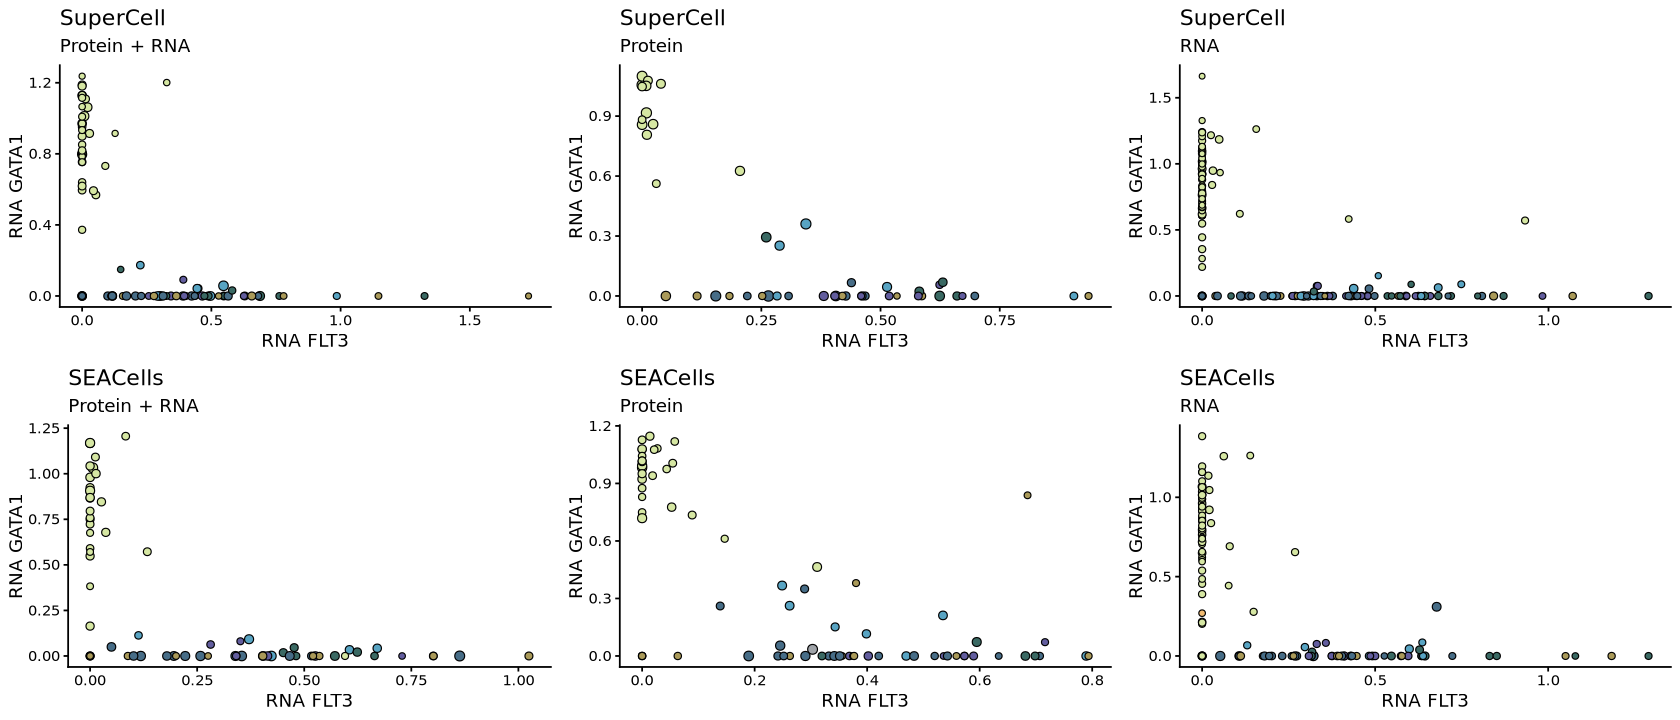

In [223]:

acr.rna.sc <- FeatureScatter(bm[,bm$celltype.l1 %in%  "Progenitor cells" ],"rna_FLT3","rna_GATA1",group.by = "celltype", cols = color.celltypes.bm,plot.cor = F) + xlab("RNA FLT3") + ylab("RNA GATA1") + theme_classic() + ggtitle("Single-cells")

DefaultAssay(bm.supercell.multi) <- "RNA"
bm.supercell.multi <- NormalizeData(bm.supercell.multi)

acr.rna.supercell.multi <- FeatureScatter.SuperCell(bm.supercell.multi[,bm.supercell.multi$celltype.l1 %in%  "Progenitor cells" ],
                                                     "rna_FLT3","rna_GATA1",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("RNA FLT3") + ylab("RNA GATA1")  + ggtitle(label = "SuperCell",subtitle = "Protein + RNA")  + theme_classic()  +
                                scale_size(limits = c(0,max.acr.size.main),
                                           breaks = c(50,100,200,400))


DefaultAssay(bm.supercell.rna) <- "RNA"
bm.supercell.rna <- NormalizeData(bm.supercell.rna)

acr.rna.supercell.rna <- FeatureScatter.SuperCell(bm.supercell.rna[,bm.supercell.rna$celltype.l1 %in%  "Progenitor cells" ],
                                                   "rna_FLT3","rna_GATA1",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("RNA FLT3") + ylab("RNA GATA1") + ggtitle(label = "SuperCell",subtitle = "RNA")  + theme_classic()  + NoLegend() +
                                scale_size(limits = c(0,max.acr.size.main),
                                           breaks = c(50,100,200,400))


DefaultAssay(bm.supercell.adt) <- "RNA"
bm.supercell.adt <- NormalizeData(bm.supercell.adt)

acr.rna.supercell.prot <- FeatureScatter.SuperCell(bm.supercell.adt[,bm.supercell.adt$celltype.l1 %in%  "Progenitor cells" ],
                                                    "rna_FLT3","rna_GATA1",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("RNA FLT3") + ylab("RNA GATA1") + ggtitle(label = "SuperCell",subtitle = "Protein")  + theme_classic()  + NoLegend() +
                                scale_size(limits = c(0,max.acr.size.main),
                                           breaks = c(50,100,200,400))


DefaultAssay(bm.seacells.mofa) <- "RNA"
bm.seacells.mofa <- NormalizeData(bm.seacells.mofa)

acr.rna.seacells.mofa <- FeatureScatter.SuperCell(bm.seacells.mofa[,bm.seacells.mofa$celltype.l1 %in%  "Progenitor cells" ],
                                                  "rna_FLT3","rna_GATA1",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("RNA FLT3") + ylab("RNA GATA1") + ggtitle(label = "SEACells",subtitle = "Protein + RNA")  + theme_classic()  + NoLegend() +
                                scale_size(limits = c(0,max.acr.size.main),
                                           breaks = c(50,100,200,400))



DefaultAssay(bm.seacells.rna) <- "RNA"
bm.seacells.rna <- NormalizeData(bm.seacells.rna)

acr.rna.seacells.rna <- FeatureScatter.SuperCell(bm.seacells.rna[,bm.seacells.rna$celltype.l1 %in%  "Progenitor cells" ],
                                                  "rna_FLT3","rna_GATA1",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("RNA FLT3") + ylab("RNA GATA1") + ggtitle(label = "SEACells",subtitle = "RNA")  + theme_classic()  + NoLegend() +
                                scale_size(limits = c(0,max.acr.size.main),
                                           breaks = c(50,100,200,400))


DefaultAssay(bm.seacells.adt) <- "RNA"
bm.seacells.adt <- NormalizeData(bm.seacells.adt)

acr.rna.seacells.prot <- FeatureScatter.SuperCell(bm.seacells.adt[,bm.seacells.adt$celltype.l1 %in%  "Progenitor cells" ],
                                                   "rna_FLT3","rna_GATA1",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("RNA FLT3") + ylab("RNA GATA1")  + ggtitle(label = "SEACells",subtitle = "Protein") + theme_classic()  + NoLegend() +
                                scale_size(limits = c(0,max.acr.size.main),
                                           breaks = c(50,100,200,400))



DefaultAssay(bm.metacell.rna) <- "RNA"
bm.metacell.rna <- NormalizeData(bm.metacell.rna)

acr.rna.metacell.rna <- FeatureScatter.SuperCell(bm.metacell.rna[,bm.metacell.rna$celltype.l1 %in%  "Progenitor cells" ],
                                                  "rna_FLT3","rna_GATA1",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("RNA FLT3") + ylab("RNA GATA1")+ ggtitle(label = "MetaCell2",subtitle = "RNA") + theme_classic()  + NoLegend() 



cowplot::plot_grid(acr.rna.supercell.multi + NoLegend(),acr.rna.supercell.prot,acr.rna.supercell.rna,
                   acr.rna.seacells.mofa,acr.rna.seacells.prot,
                   acr.rna.seacells.rna)



Warning message in guide_legend(ncol = 2, title = "Cell types", size = "none", override.aes = list(size = 4)):
“Arguments in `...` must be used.
✖ Problematic argument:
• size = "none"
ℹ Did you misspell an argument name?”


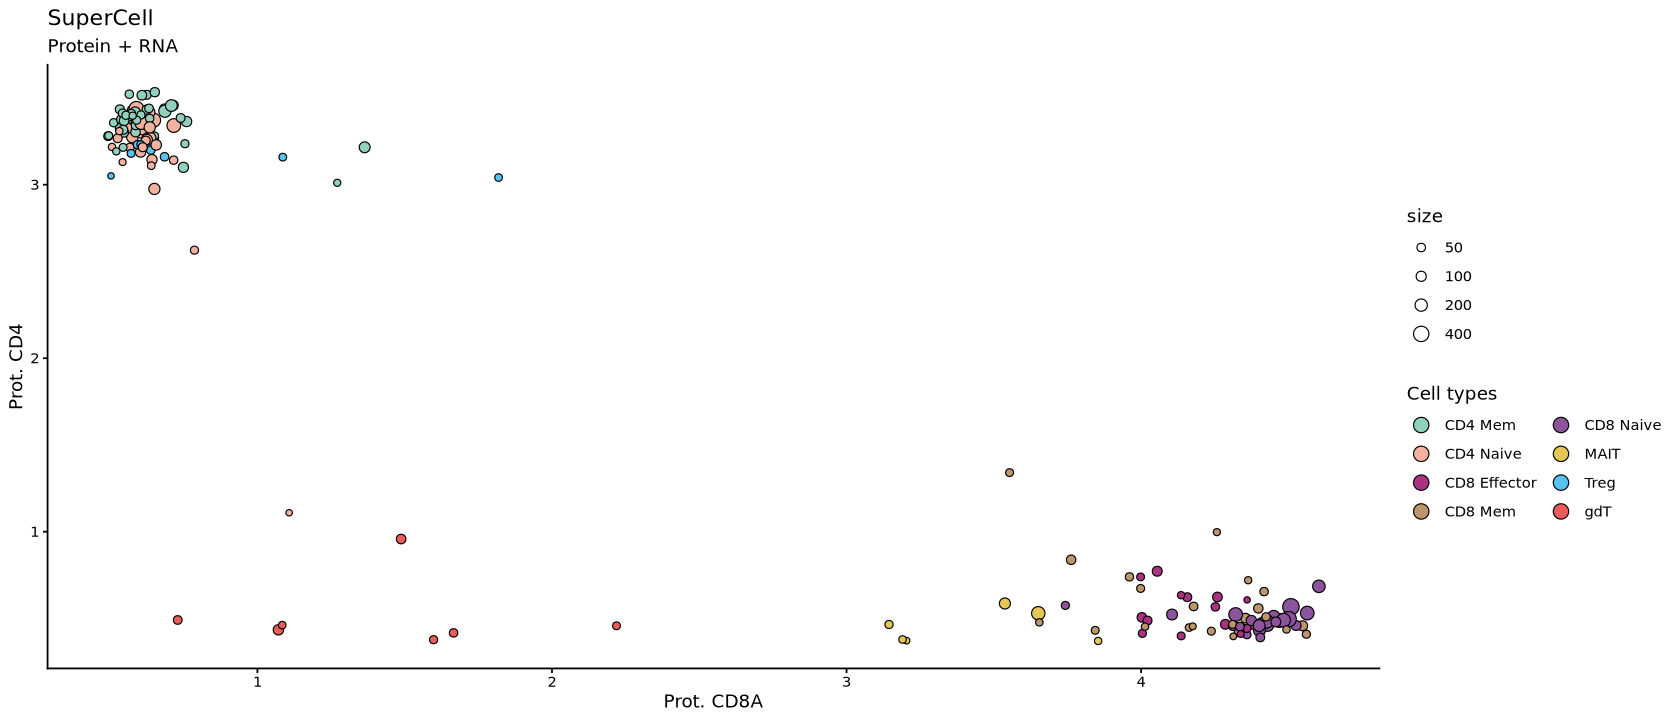

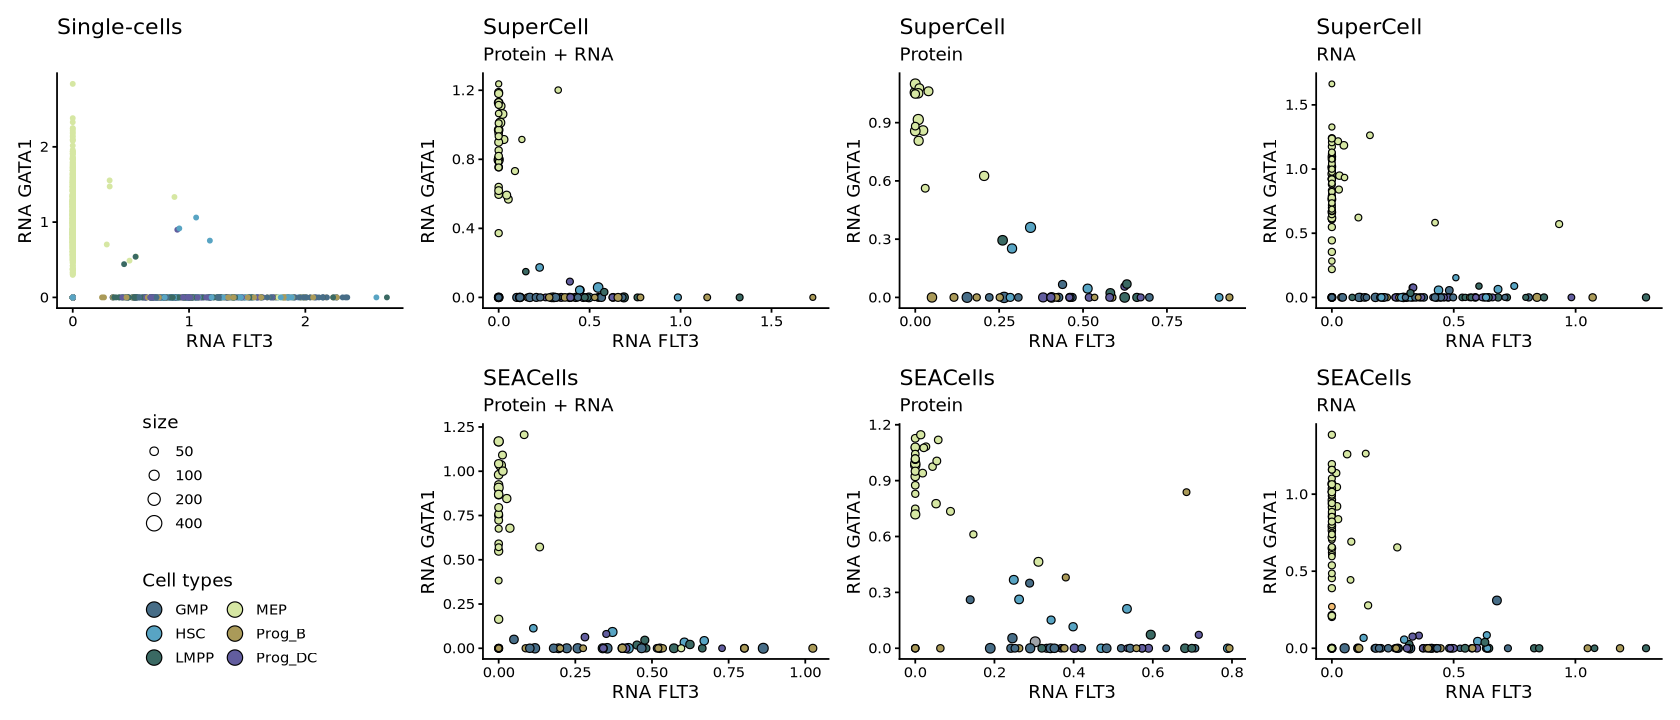

In [224]:
acr.prot.supercell.multi + 
  guides(colour = "none",
         fill = guide_legend(ncol =2,title = "Cell types",
                             override.aes = list(size=4)))

fig2H <- wrap_plots(acr.rna.sc + ggtitle("Single-cells") + theme_classic() + NoLegend(),
                    acr.rna.supercell.multi + 
                      guides( fill = guide_legend(ncol =2,title = "Cell types",size = "none",
                                                  override.aes = list(size=4)))+ theme(legend.key.size = unit(1, 'lines')),acr.rna.supercell.prot,acr.rna.supercell.rna,
                    guide_area(),acr.rna.seacells.mofa,acr.rna.seacells.prot,acr.rna.seacells.rna,guides = "collect",nrow = 2)
fig2H

Normalizing layer: counts

Normalizing layer: counts

Normalizing layer: counts

Normalizing layer: counts



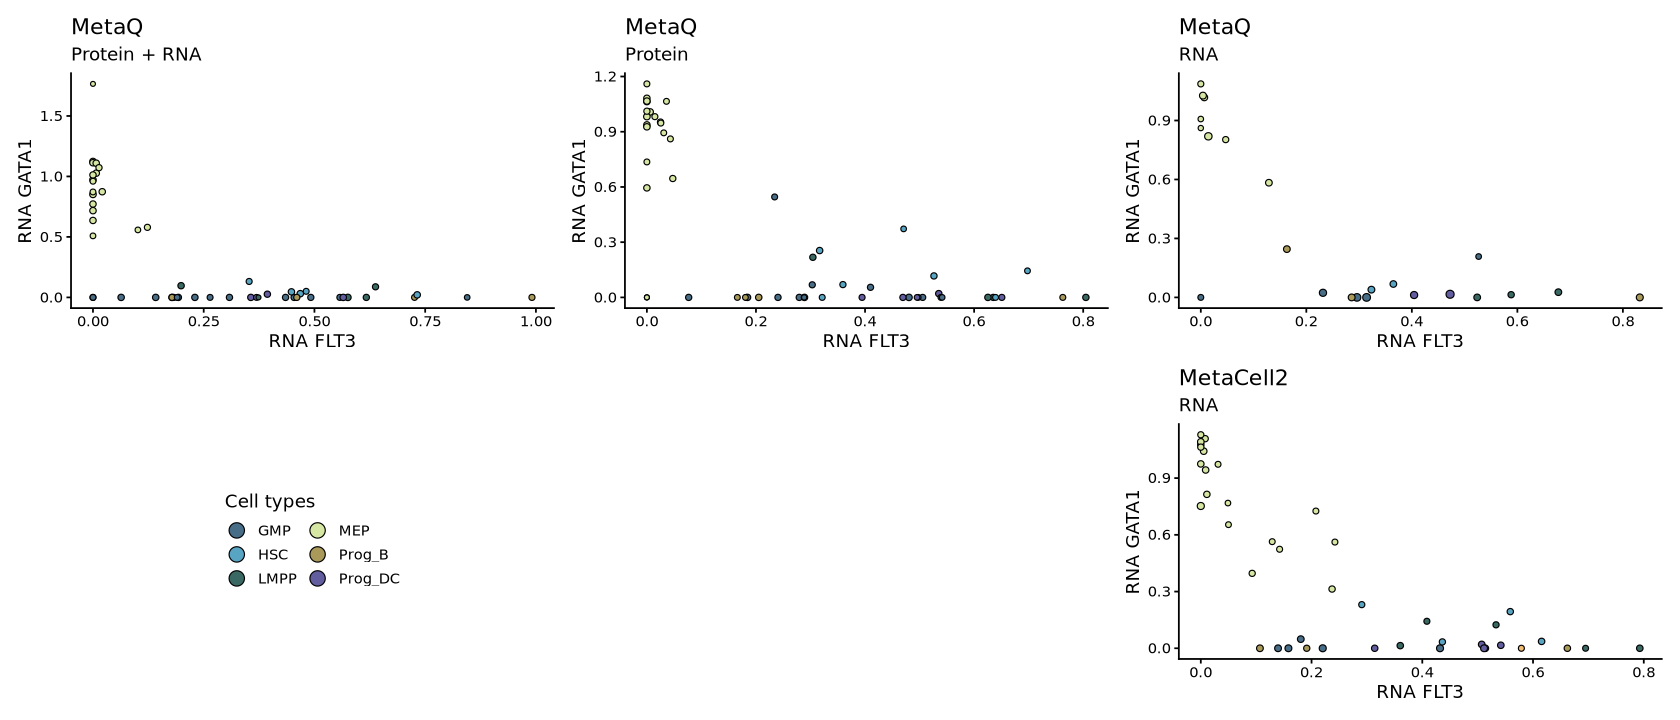

In [225]:


DefaultAssay(bm.metaq.multi) <- "RNA"
bm.metaq.multi <- NormalizeData(bm.metaq.multi)

acr.rna.metaq.multi <- FeatureScatter.SuperCell(bm.metaq.multi[,bm.metaq.multi$celltype.l1 %in%  "Progenitor cells" ],
                                                  "rna_FLT3","rna_GATA1",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("RNA FLT3") + ylab("RNA GATA1")+ ggtitle(label = "MetaQ",subtitle = "Protein + RNA") + theme_classic()  +
                                scale_size(limits = c(0,max.acr.size.supp),
                                           breaks =c(50,200,800,3200))  + 
  guides(size = "none")


DefaultAssay(bm.metaq.rna) <- "RNA"
bm.metaq.rna <- NormalizeData(bm.metaq.rna)

acr.rna.metaq.rna <- FeatureScatter.SuperCell(bm.metaq.rna[,bm.metaq.rna$celltype.l1 %in%  "Progenitor cells"],
                                                    "rna_FLT3","rna_GATA1",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("RNA FLT3") + ylab("RNA GATA1") + ggtitle(label = "MetaQ",subtitle = "RNA")  + theme_classic()  + NoLegend() +
                                scale_size(limits = c(0,max.acr.size.supp),
                                           breaks =c(50,200,800,3200)) 


DefaultAssay(bm.metaq.adt) <- "RNA"
bm.metaq.adt <- NormalizeData(bm.metaq.adt)

acr.rna.metaq.adt <- FeatureScatter.SuperCell(bm.metaq.adt[,bm.metaq.adt$celltype.l1  %in%  "Progenitor cells"],
                                                    "rna_FLT3","rna_GATA1",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("RNA FLT3") + ylab("RNA GATA1") + ggtitle(label = "MetaQ",subtitle = "Protein")  + theme_classic()  + NoLegend()  +
                                scale_size(limits = c(0,max.acr.size.supp),
                                           breaks = c(50,200,800,3200))


DefaultAssay(bm.metacell.rna) <- "ADT"
bm.metacell.rna <- NormalizeData(bm.metacell.rna)

acr.rna.metacell.rna <- FeatureScatter.SuperCell(bm.metacell.rna[,bm.metacell.rna$celltype.l1  %in%  "Progenitor cells"],
                                                  "rna_FLT3","rna_GATA1",group.by = "celltype", cols = color.celltypes.bm) + 
   xlab("RNA FLT3") + ylab("RNA GATA1")+ ggtitle(label = "MetaCell2",subtitle = "RNA") + theme_classic()  + NoLegend()  +
                                scale_size(limits = c(0,max.acr.size.supp),
                                           breaks = c(50,200,800,3200))

figSuppAcrRNA <- wrap_plots(
                    acr.rna.metaq.multi + 
                      guides( fill = guide_legend(ncol =2,title = "Cell types",
                                                  override.aes = list(size=4))  # One column for colors
                              )+ theme(legend.key.size = unit(1, 'lines')),acr.rna.metaq.adt,acr.rna.metaq.rna,
                    guide_area(),plot_spacer(),acr.rna.metacell.rna,guides = "collect",nrow = 2)
figSuppAcrRNA


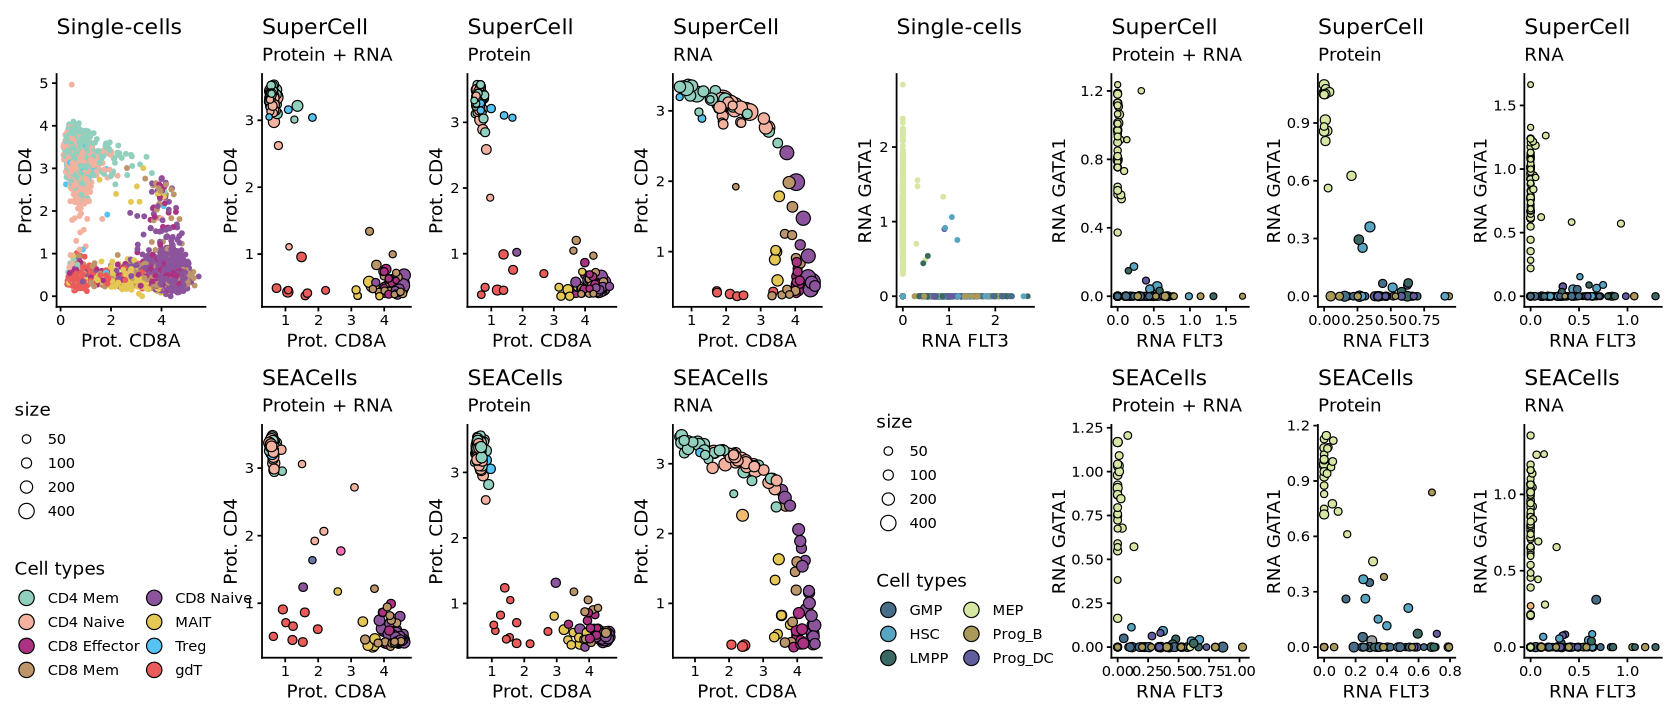

In [226]:
fig2GH <- cowplot::plot_grid(fig2G,fig2H)
fig2GH

In [227]:
pdf("../../../pdf_files/Fig2/fig2GH.pdf",height = 5,width = 17.5)
fig2GH
dev.off()

agg_record_1909893419 
                    2

agg_record_884616499 
                   2

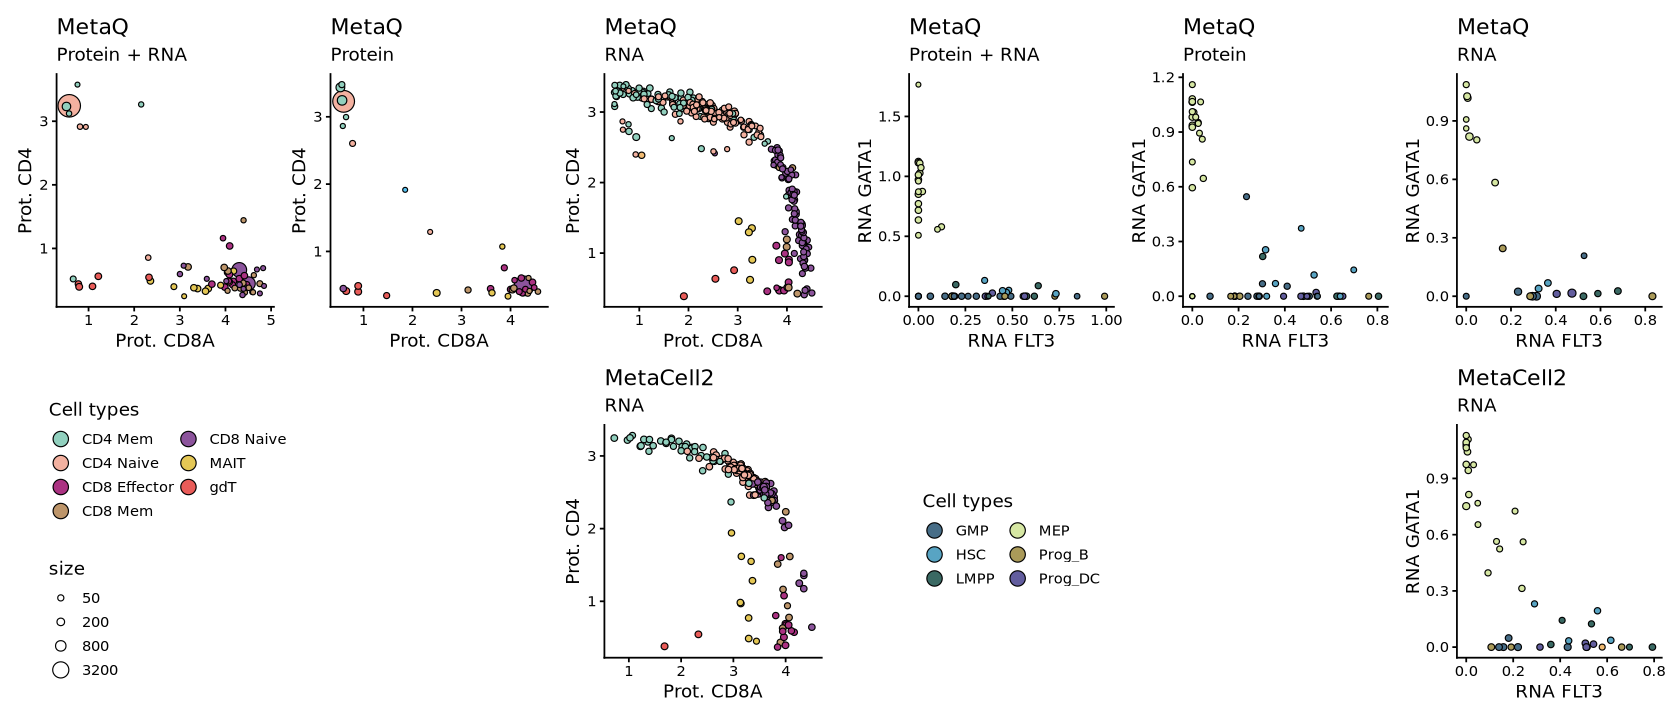

In [228]:
figSuppAcr <- cowplot::plot_grid(figSuppAcrProt,figSuppAcrRNA)
figSuppAcr

pdf("../../../pdf_files/FigS2//figSuppAcr.pdf",height = 5,width = 14)
figSuppAcr
dev.off()

## Purity by major types

Warning message in wilcox.test.default(c(1, 0.91304347826087, 1, 0.902439024390244, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(1, 0.91304347826087, 1, 0.902439024390244, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.63265306122449, 0.971428571428571, 1, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.63265306122449, 0.971428571428571, 1, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.63265306122449, 0.971428571428571, 1, :
“cannot compute exact p-value with ties”


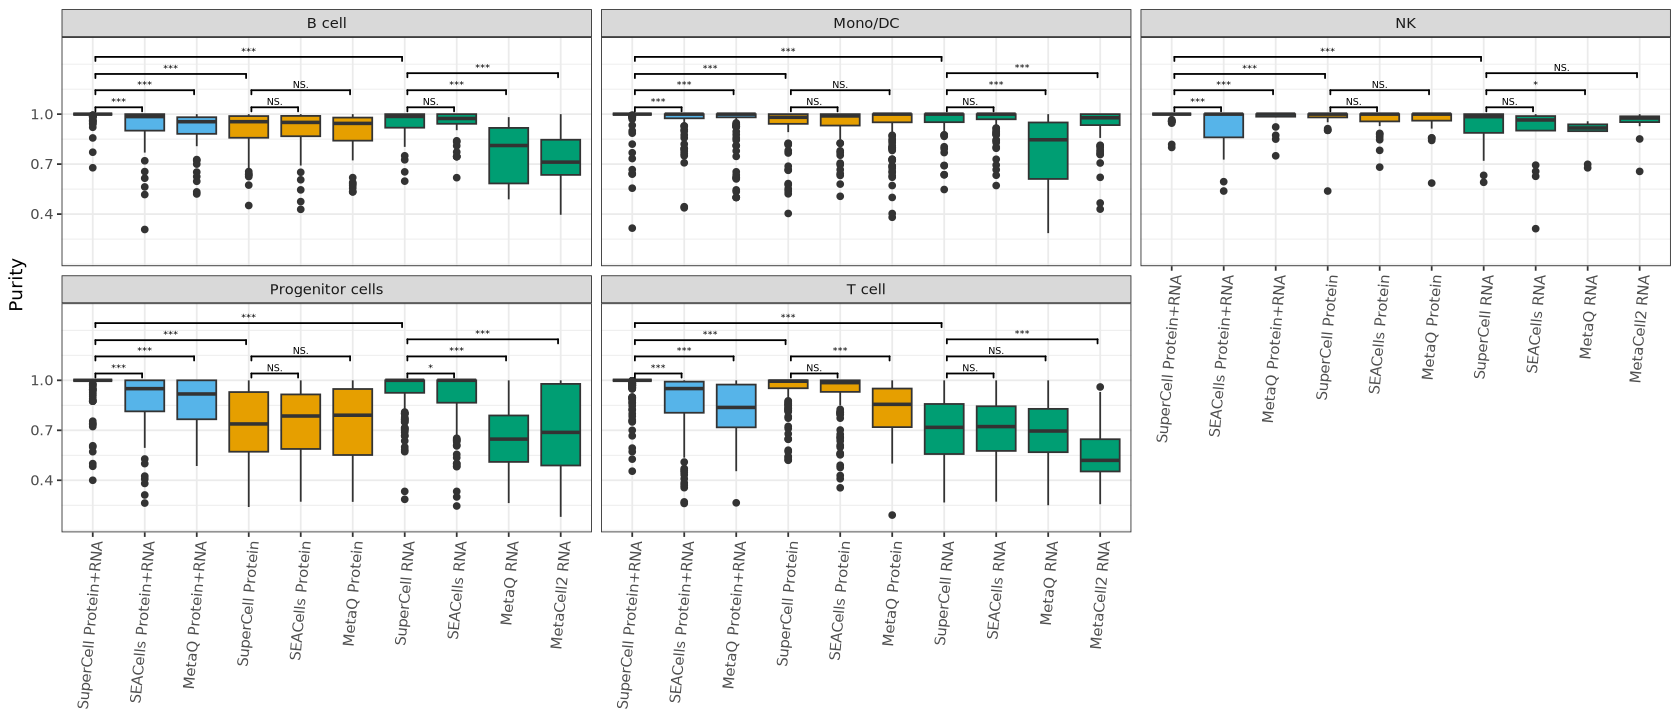

In [229]:


sig.celltype.l2_purity.g75.major.type  <- ggplot(bench.75.unsup,aes(y=celltype.l2_purity,x = method,fill = input)) + 
  geom_boxplot() + theme_bw() + facet_wrap("~celltype.l1") + 
  geom_signif(comparisons = comparisons.multi,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 2)+
  geom_signif(comparisons = comparisons.protein,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 2)+
  geom_signif(comparisons = comparisons.rna,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 2)+
  geom_signif(comparisons = comparison.inter.modality,y_position =1.2, ,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 2) +
  #facet_wrap("gamma",nrow = 1) + 
  #ylim(c(0,1.425)) + 
  # geom_signif(comparisons = comparisons,
  #             step_increase=0.15,
  #             map_signif_level=T,
  #             extend_line = -0.005,
  #             textsize = 3)+
  # geom_signif(comparisons = comparison.inter.modality,
  #             step_increase=0.15,
  #             map_signif_level=T,
  #             extend_line = -0.005,
  #             textsize = 3) +
  scale_x_discrete(guide = guide_axis(angle = 85)) + 
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Purity")  +
  scale_y_continuous(limits = c(0.15,1.4),breaks =c(0.4,0.7,1)) + theme(axis.title.x = element_blank())

sig.celltype.l2_purity.g75.major.type + NoLegend()

In [ ]:
# pdf("../../../pdf_files/Fig2/figS2E.pdf",height = 6,width = 5)
# sig.celltype.l2_purity.g75.major.type + NoLegend()
# dev.off()

In [230]:
pdf("../../../pdf_files/FigS2/figS2GH.pdf",height = 6,width = 5)
sig.celltype.l2_purity.g75.major.type + NoLegend()
wnn.weights<- VlnPlot(bm,'RNA.weight',group.by = "celltype.l1",sort = T,pt.size = 0) + NoLegend(
) + ggtitle("RNA Weights")+ theme(axis.title.y = element_blank()) + coord_flip() 
wnn.weights

Warning message in wilcox.test.default(c(1, 0.91304347826087, 1, 0.902439024390244, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(1, 0.91304347826087, 1, 0.902439024390244, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.63265306122449, 0.971428571428571, 1, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.63265306122449, 0.971428571428571, 1, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.63265306122449, 0.971428571428571, 1, :
“cannot compute exact p-value with ties”


In [231]:
pdf("../../../pdf_files/FigS2/figS2H.pdf",height = 7,width = 3)
wnn.weights + theme(text = element_text(size = 20),
                    title = element_text(size = 20))
dev.off()

agg_record_2079275276 
                    2

Metcalls2 outliers

outliers,graining_level,perc.outliers
<int>,<chr>,<chr>
151,20,0.49%
15,75,0.05%


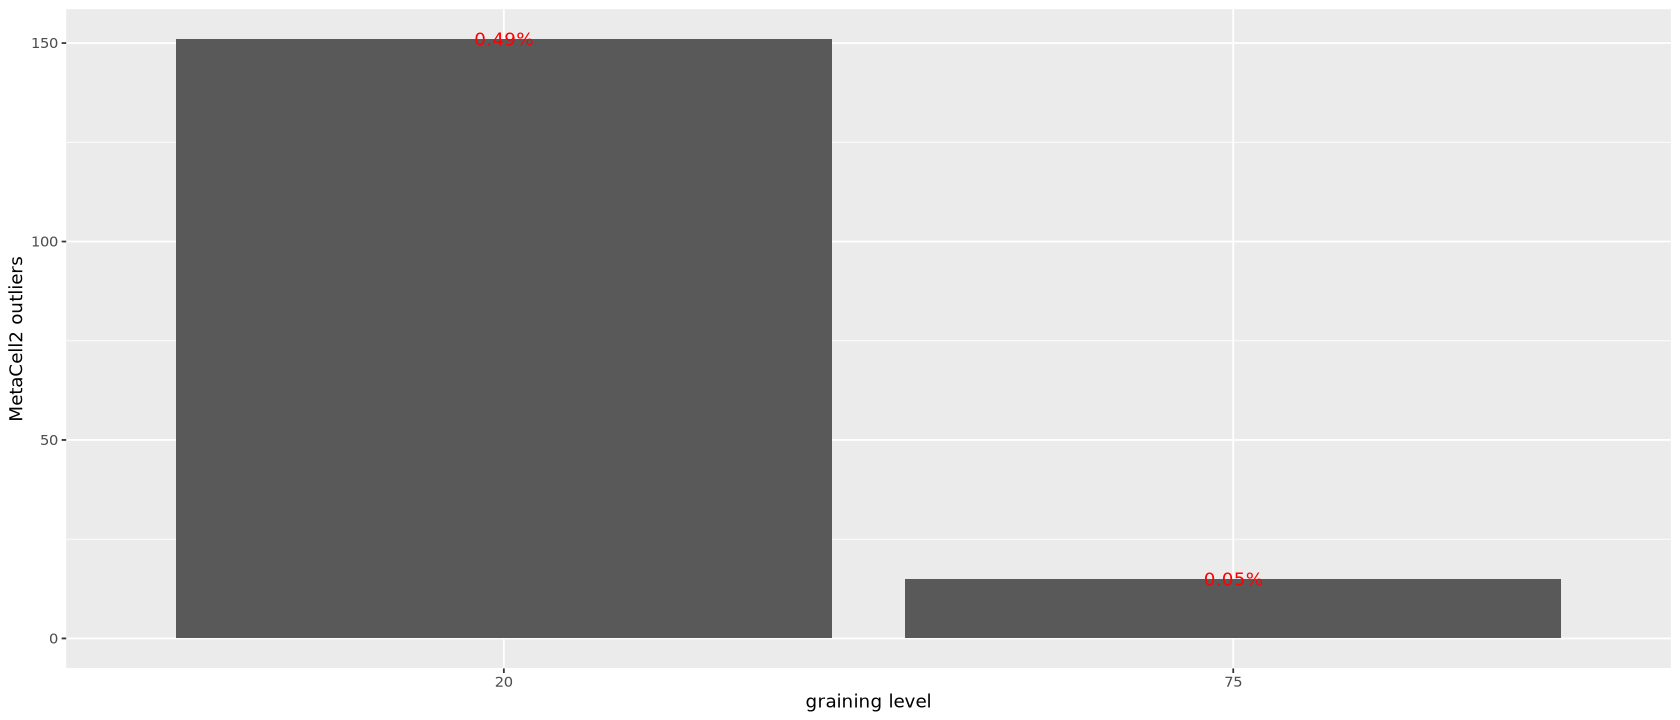

In [233]:
bm.metacell.rna.g20 <- readRDS(paste0(datadir,"/output/bmCiteSeq/MetaCellRNA/g20/seurat.cite.mc.rds"))
outliers.mc2 <- data.frame("outliers" = c(length(which(is.na(bm.metacell.rna.g20@misc$membership))),
                                          length(which(is.na(bm.metacell.rna@misc$membership)))),
                           "graining_level" = c("20","75"))
outliers.mc2$perc.outliers <-label_percent()(outliers.mc2$outliers/ncol(bm))
outliers.mc2
outliers.mc2 <- ggplot(outliers.mc2,aes( x= graining_level, y = outliers)) + geom_bar(stat = "identity", position="dodge") + ylab("MetaCell2 outliers") + xlab("graining level") + geom_text(aes(label = perc.outliers),col = "red")
outliers.mc2

In [234]:
bench.75.no.random.semi.sup <- bench.75.no.random[bench.75.no.random$tool == "ssSuperCell",]

bench.75.no.random.semi.sup$pct_known <- factor(paste0(as.character(bench.75.no.random.semi.sup$pct_known),"%"), levels = rev(c("100%","75%","50%","25%","0%") ))


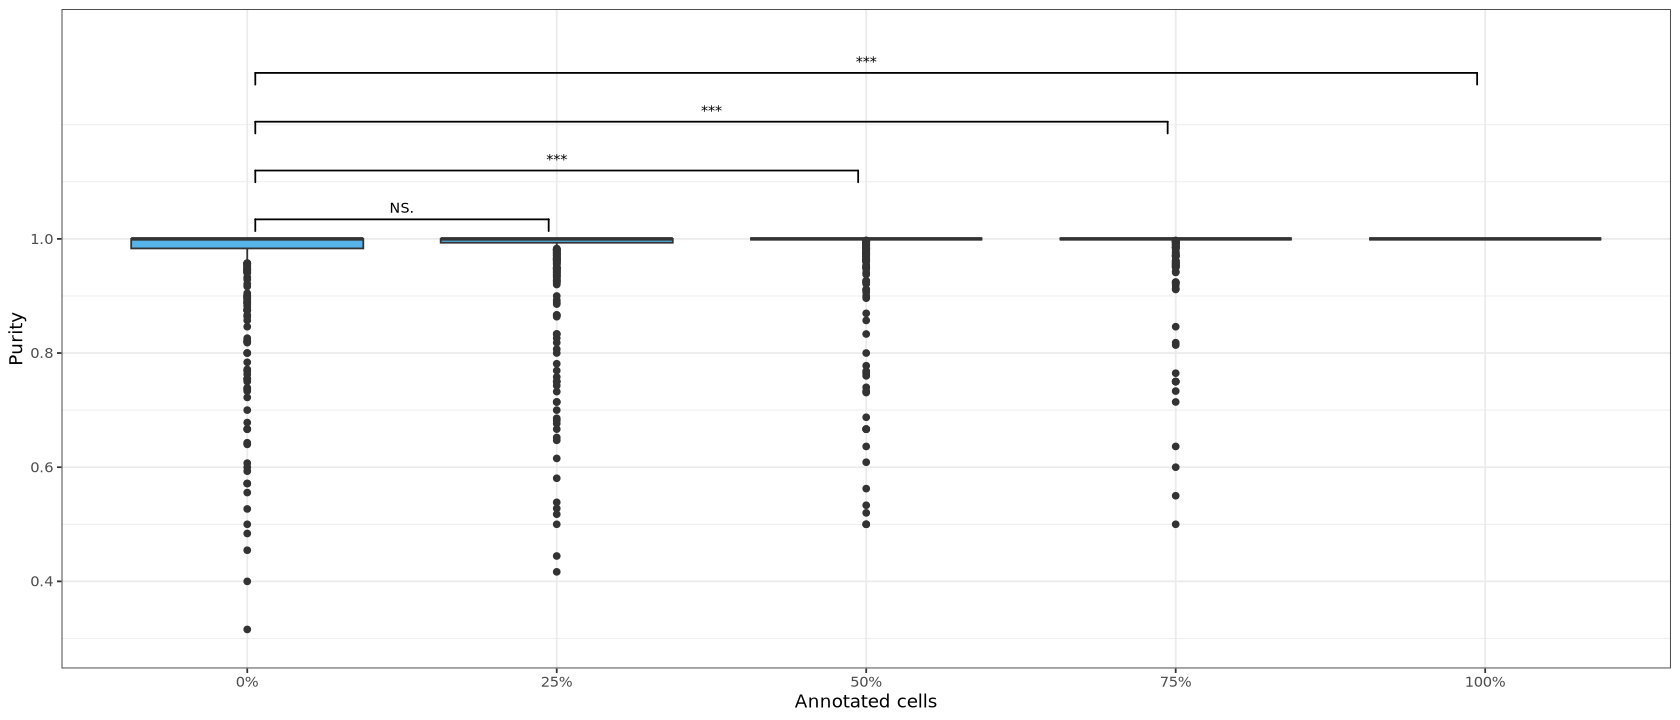

In [235]:

comparisons.semi.sup <- list(
  c("0%","25%"),
  c("0%","50%"),
  c("0%","75%"),
  c("0%","100%")
)


purity.pbmc.multiome.g75.semi.sup <- ggplot(bench.75.no.random.semi.sup[bench.75.no.random.semi.sup$input == "Protein+RNA",],
                                            aes(y=celltype.l2_purity,x = pct_known,fill = input)) + 
  geom_boxplot()  + theme_bw()  + 
  geom_signif(comparisons = comparisons.semi.sup,
              step_increase=0.125,
              map_signif_level=T,
              extend_line = -0.005,
              textsize = 3)+
  scale_y_continuous(breaks = c(0.4,0.6,0.8,1),limits = c(0.3,1.35)) + 
  
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + theme_bw() + xlab("Annotated cells") +ylab("Purity") + NoLegend()


purity.pbmc.multiome.g75.semi.sup 

Warning message:
“Removed 12 rows containing missing values or values outside the scale range
(`geom_signif()`).”


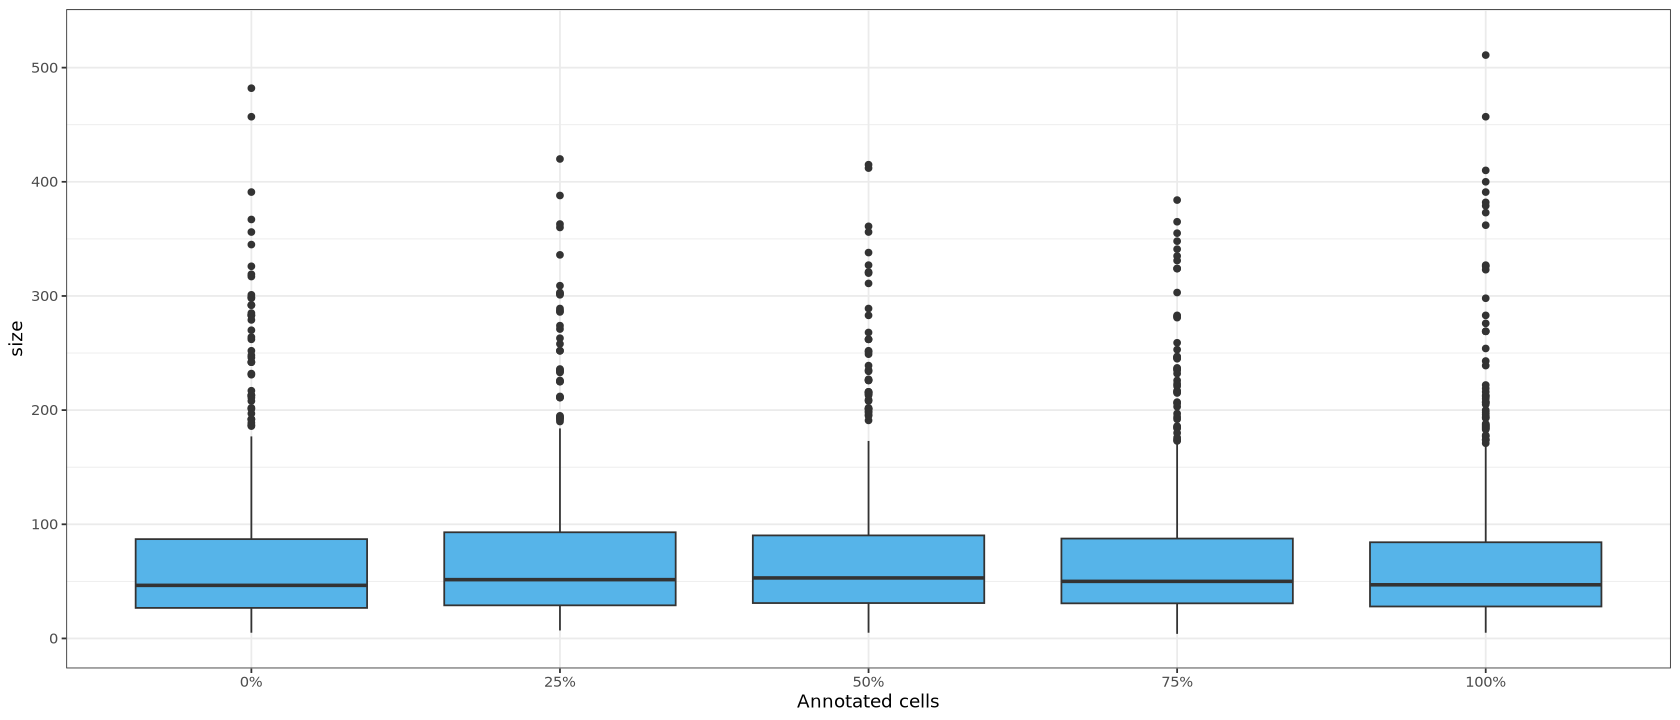

In [236]:

size.pbmc.multiome.g75.semi.sup <- ggplot(bench.75.no.random.semi.sup[bench.75.no.random.semi.sup$input == "Protein+RNA",],
                                          aes(y=size,x = pct_known,fill = input)) + 
  geom_boxplot() + theme_bw()  + 
  geom_signif(comparisons = comparisons.semi.sup,
              step_increase=0.125,
              map_signif_level=T,
              extend_line = -0.005,
              textsize = 3)+
  ylim(c(0,525))+
  
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + xlab("Annotated cells") + NoLegend()


size.pbmc.multiome.g75.semi.sup

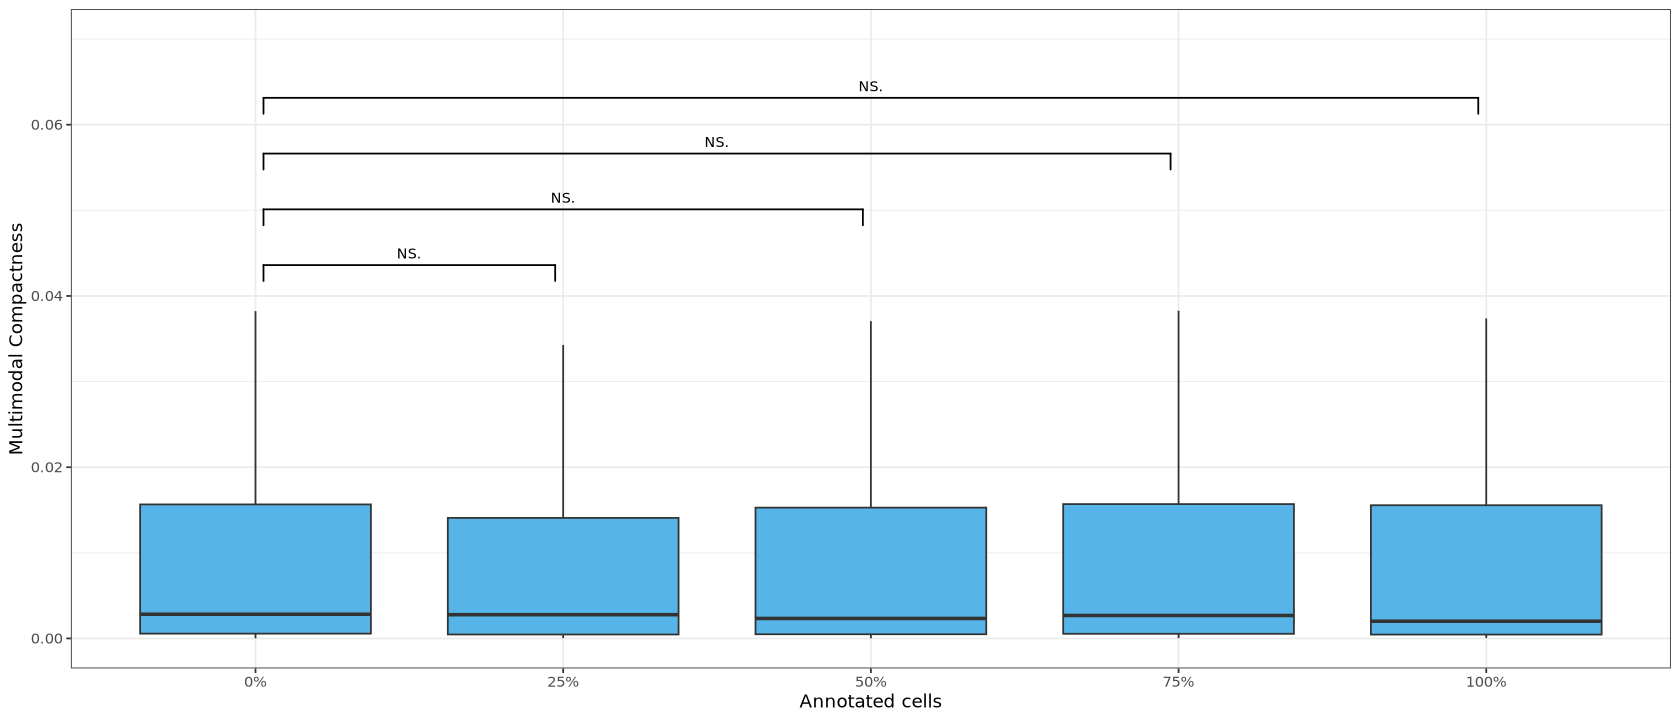

In [237]:

multimodal_compactness.75.semi.sup <- ggplot(bench.75.no.random.semi.sup[bench.75.no.random.semi.sup$input == "Protein+RNA",],aes(y=multimodal_compactness,x = pct_known,fill = input)) + 
  geom_boxplot(outlier.shape = NA)  + theme_bw() + 
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Multimodal Compactness")  +  # Hides outliers
  coord_cartesian(ylim = c(0,0.07))   + NoLegend() + 
  geom_signif(comparisons = comparisons.semi.sup,
              y_position = 0.025,
              step_increase=0.0175,
              map_signif_level=T,
              extend_line = -0.005,
              tip_length = 0.005,
              textsize = 3) + xlab("Annotated cells")
multimodal_compactness.75.semi.sup


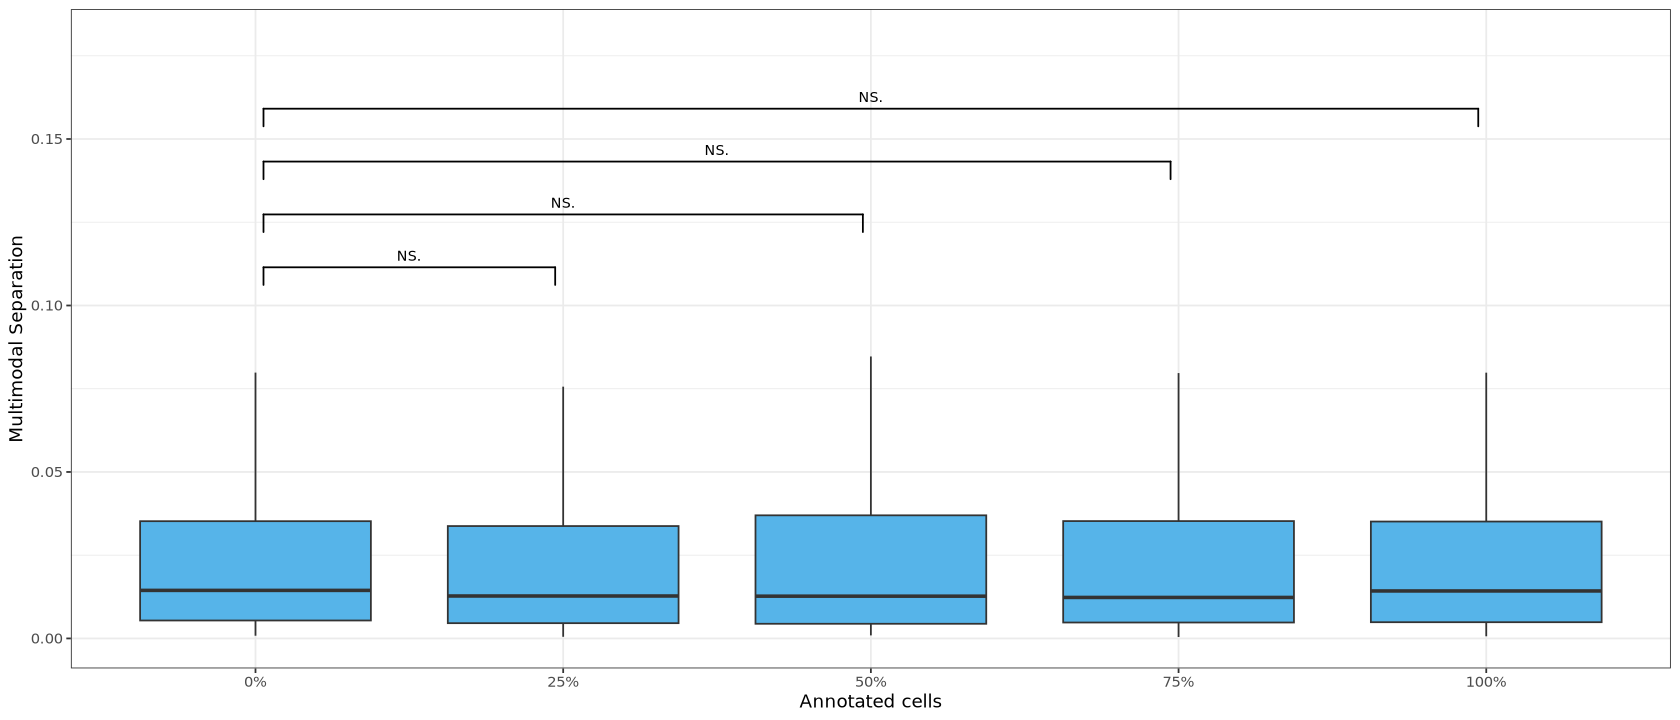

In [238]:
multimodal_separation.75.semi.sup <- ggplot(bench.75.no.random.semi.sup[bench.75.no.random.semi.sup$input == "Protein+RNA",],aes(y=multimodal_separation,x = pct_known,fill = input)) + 
  geom_boxplot(outlier.shape = NA) +theme_bw() +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Multimodal Separation")  +  # Hides outliers
  coord_cartesian(ylim = c(0, 0.18))+ NoLegend() + 
  geom_signif(comparisons = comparisons.semi.sup,
              y_position = 0.085,
              step_increase=0.03,
              map_signif_level=T,
              extend_line = -0.005,
              tip_length = 0.01,
              textsize = 3) + xlab("Annotated cells")
multimodal_separation.75.semi.sup

agg_record_1389714898 
                    2

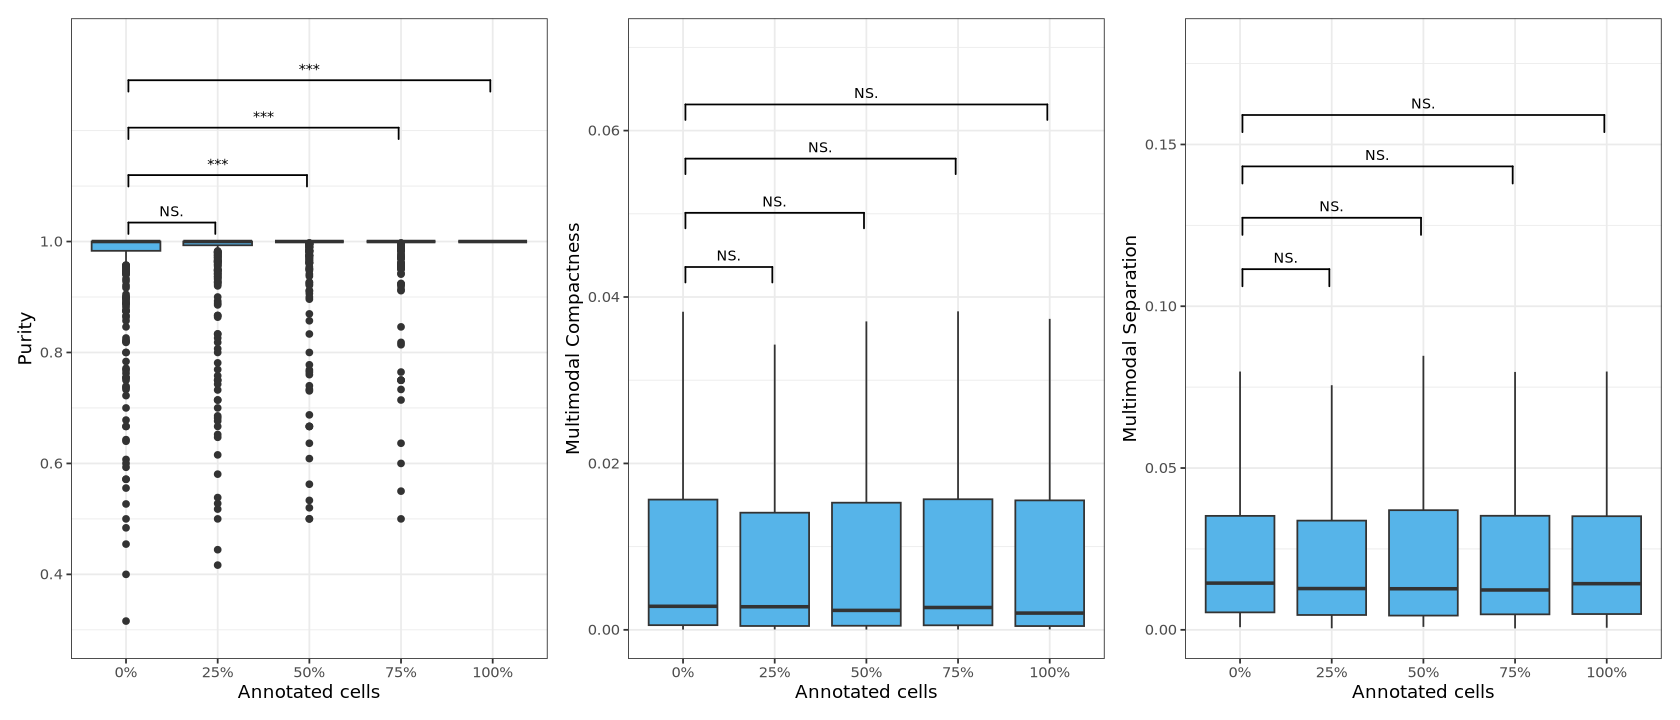

In [239]:
wrap_plots(purity.pbmc.multiome.g75.semi.sup,multimodal_compactness.75.semi.sup,multimodal_separation.75.semi.sup,nrow = 1)

pdf("../../../pdf_files/Fig2/fig2J_semi_sup.pdf",height = 2.75,width = 7)
wrap_plots(purity.pbmc.multiome.g75.semi.sup,multimodal_compactness.75.semi.sup,multimodal_separation.75.semi.sup,nrow = 1)
dev.off()

Idea switch fig main to RNA with more differences



In [ ]:
plot.list <- list()
for (p in c(100,75,50,25,0)) {
  sobj <- readRDS(paste0(paste0(datadir,"/output/bmCiteSeq//SuperCellMulti/testSemiSup/g75/guiding_label_",p,"_pct_hiddenseurat.mc.rds")))
  sobj <- addCellType(sobj)
  plot.list[[paste0("pct_",p)]] <- SingleCellsMetacellsWnnUMAP(
    sobj.sc = bm,
    sobj.mc = sobj,
    dimred_1 = "pca",
    dimred_2= "apca",
    dims.list = list(1:30, 1:18),
    cols = color.celltypes.bm,
    group.by = "celltype",
    dims.umap = c(1,2)
    ) + 
    theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  ggtitle(label = "SuperCell Protein+RNA", subtitle = paste0(100-p, "% annotated cells")) + 
    scale_size(limits = c(0,max(bench.75.no.random.semi.sup$size)),breaks = c(100,200,300,400))  +
    guides(fill=guide_legend(ncol =2,title = "Cell types",
                             override.aes = list(size=4)),
           colour = "none",
           size = guide_legend(title = "Size"))
  
  
}


wrap_plots(plot.list[[2]],plot.list[[3]],plot.list[[4]],plot.list[[5]],guide_area(),guides = "collect",nrow = 1) & 
  theme(legend.spacing.y = unit(-0.35, "line"),legend.key.size = unit(1, "line"))

dir.create("../../../pdf_files/FigS3", recursive = T, showWarnings = F)
pdf("../../../pdf_files/FigS3/figS3B_semi_sup_bm_cite.pdf", height = 4,width = 18)
wrap_plots(plot.list[[2]],plot.list[[3]],plot.list[[4]],plot.list[[5]],guide_area(),guides = "collect",nrow = 1) & 
  theme(legend.spacing.y = unit(-0.35, "line"),legend.key.size = unit(1, "line"))

dev.off()

Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph

23:06:39 UMAP embedding parameters a = 0.9922 b = 1.112

23:06:39 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 20

23:06:41 Initializing from normalized Laplacian + noise (using RSpectra)

23:06:43 Commencing optimization for 200 epochs, with 1017390 positive edges

23:06:43 Using rng type: pcg

23:07:09 Optimization finished

Warning message:
“No assay specified, setting assay as RNA by default.”
Warning message:
“No assay specified, setting assay as RNA by default.”
Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph

23:09:08 UMAP embedding parameters a = 

## Same RNA only



In [ ]:

comparisons.semi.sup <- list(
  c("0%","25%"),
  c("0%","50%"),
  c("0%","75%"),
  c("0%","100%")
)


purity.pbmc.multiome.g75.semi.sup.rna <- ggplot(bench.75.no.random.semi.sup[bench.75.no.random.semi.sup$input == "RNA",],
                                                aes(y=celltype.l2_purity,x = pct_known,fill = input)) + 
  geom_boxplot()  + theme_bw()  + 
  geom_signif(comparisons = comparisons.semi.sup,
              step_increase=0.125,
              map_signif_level=T,
              extend_line = -0.005,
              textsize = 3)+
  scale_y_continuous(breaks = c(0.4,0.6,0.8,1),limits = c(0.2,1.4)) + 
  
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + theme_bw() + xlab("Annotated cells") +ylab("Purity") + NoLegend()


purity.pbmc.multiome.g75.semi.sup.rna 

In [ ]:

size.pbmc.multiome.g75.semi.sup.rna <- ggplot(bench.75.no.random.semi.sup[bench.75.no.random.semi.sup$input == "RNA",],
                                              aes(y=size,x = pct_known,fill = input)) + 
  geom_boxplot() + theme_bw()  + 
  geom_signif(comparisons = comparisons.semi.sup,
              step_increase=0.125,
              map_signif_level=T,
              extend_line = -0.005,
              textsize = 3)+
  ylim(c(0,525))+
  
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + xlab("Annotated cells") + NoLegend()


size.pbmc.multiome.g75.semi.sup.rna

In [ ]:

multimodal_compactness.75.semi.sup.rna <- ggplot(bench.75.no.random.semi.sup[bench.75.no.random.semi.sup$input == "RNA",],aes(y=multimodal_compactness,x = pct_known,fill = input)) + 
  geom_boxplot(outlier.shape = NA)  + theme_bw() + 
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Multimodal Compactness")  +  # Hides outliers
  coord_cartesian(ylim = c(0,0.15))   + NoLegend() + 
  geom_signif(comparisons = comparisons.semi.sup,
              y_position = 0.07,
              step_increase=0.045,
              map_signif_level=T,
              extend_line = -0.005,
              tip_length = 0.005,
              textsize = 3) + xlab("Annotated cells")
multimodal_compactness.75.semi.sup.rna


In [ ]:
multimodal_separation.75.semi.sup.rna <- ggplot(bench.75.no.random.semi.sup[bench.75.no.random.semi.sup$input == "RNA",],aes(y=multimodal_separation,x = pct_known,fill = input)) + 
  geom_boxplot(outlier.shape = NA) +theme_bw() +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Multimodal Separation")  +  # Hides outliers
  coord_cartesian(ylim = c(0, 0.2))+ NoLegend() + 
  geom_signif(comparisons = comparisons.semi.sup,
              y_position = 0.1,
              step_increase=0.065,
              map_signif_level=T,
              extend_line = -0.005,
              tip_length = 0.01,
              textsize = 3) + xlab("Annotated cells")
multimodal_separation.75.semi.sup.rna

In [ ]:
wrap_plots(purity.pbmc.multiome.g75.semi.sup.rna,multimodal_compactness.75.semi.sup.rna,multimodal_separation.75.semi.sup.rna,nrow = 1)

pdf("../../../pdf_files/FigS3/figS3D_semi_sup_rna_metrics.pdf",height = 2.75,width = 7)
wrap_plots(purity.pbmc.multiome.g75.semi.sup.rna,multimodal_compactness.75.semi.sup.rna,multimodal_separation.75.semi.sup.rna,nrow = 1)
dev.off()

In [ ]:

DefaultAssay(bm.seacells.adt) <- "ADT"
bm.seacells.adt <- NormalizeData(bm.seacells.adt,normalization.method = "CLR",margin = 2)

acr.prot.seacells.prot <- FeatureScatter.SuperCell(bm.seacells.adt[,bm.seacells.adt$celltype.l1 %in% "T cell" ],
                                                   "adt_CD8a","adt_CD4",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("Prot. CD8A") + ylab("Prot. CD4")  + ggtitle(label = "SEACells",subtitle = "Protein") + theme_classic()  + NoLegend() 

In [ ]:
plot.list <- list()
for (p in c(100,75,50,25,0)) {
  sobj <- readRDS(paste0("../../../output/bmCiteSeq//SuperCellRNA/testSemiSup/g75/guiding_label_",p,"_pct_hiddenseurat.mc.rds"))
  sobj <- addCellType(sobj)
  plot.list[[paste0("pct_",p)]] <- SingleCellsMetacellsWnnUMAP(
    sobj.sc = bm,
    sobj.mc = sobj,
    dimred_1 = "pca",
    dimred_2= "apca",
    dims.list = list(1:30, 1:18),
    cols = color.celltypes.bm,
    group.by = "celltype",
    dims.umap = c(1,2)
    ) + 
    theme_classic() + ggtitle(label = "SuperCell RNA",
                              subtitle = paste0(100 - p, "% annotated cells")) + 
    scale_size(limits = c(0,max(bench.75.no.random.semi.sup$size)),breaks = c(50,100,200,400))  +
    guides(fill=guide_legend(ncol =2,title = "Cell types",
                             override.aes = list(size=4)),
           colour = "none",
           size = guide_legend(title = "Size"))
  
  
}


wrap_plots(plot.list[[2]],plot.list[[3]],plot.list[[4]],plot.list[[5]],guide_area(),guides = "collect",nrow = 1) & 
  theme(legend.spacing.y = unit(-0.35, "line"),legend.key.size = unit(1, "line"))

pdf("../../../pdf_files/FigS3/figS3C_semi_sup_bm_cite_rna_umaps.pdf", height = 4,width = 18)
wrap_plots(plot.list[[2]],plot.list[[3]],plot.list[[4]],plot.list[[5]],guide_area(),guides = "collect",nrow = 1) & 
  theme(legend.spacing.y = unit(-0.35, "line"),legend.key.size = unit(1, "line"))

dev.off()

In [ ]:

bm.supercell.rna.semi <- readRDS(paste0("../../../output/bmCiteSeq//SuperCellRNA/testSemiSup/g75/guiding_label_",25,"_pct_hiddenseurat.mc.rds"))
bm.supercell.rna.semi <- addCellType(bm.supercell.rna.semi)

DefaultAssay(bm.supercell.rna.semi) <- "ADT"
bm.supercell.rna.semi<- NormalizeData(bm.supercell.rna.semi,normalization.method = "CLR",margin = 2)

acr.prot.supercell.rna.semi.sup <- FeatureScatter.SuperCell(bm.supercell.rna.semi[,bm.supercell.rna.semi$celltype.l1 %in% "T cell" ],
                                                            "adt_CD8a","adt_CD4",group.by = "celltype", cols = color.celltypes.bm) + 
  xlab("Prot. CD8A") + ylab("Prot. CD4") + ggtitle(label = "SuperCell RNA",subtitle = "75% annotated cells")  + theme_classic()  

acr.prot.supercell.rna.semi.sup + NoLegend()

pdf("../../../pdf_files/FigS3/figS3E_semi_sup_bm_rna_acrprot.pdf",height = 3,width = 3.5)
acr.prot.supercell.rna.semi.sup + NoLegend()
dev.off()

# sup test with shuffling neivghbors




In [ ]:
bench.75.no.random.noisy.sup <- bench.75.no.random[bench.75.no.random$tool == "supSuperCell",]

bench.75.no.random.noisy.sup$shuffled_labels <- gsub(x = bench.75.no.random.noisy.sup$guiding_labels,pattern = "[a-z]*",replacement = "")
bench.75.no.random.noisy.sup$shuffled_labels <- gsub(x = bench.75.no.random.noisy.sup$shuffled_labels,pattern = "_*",replacement = "")
bench.75.no.random.noisy.sup$shuffled_labels <- paste0(bench.75.no.random.noisy.sup$shuffled_labels,"%")
bench.75.no.random.noisy.sup$shuffled_labels[bench.75.no.random.noisy.sup$shuffled_labels == "%"] <- "Unsup."
bench.75.no.random.noisy.sup$shuffled_labels <- factor(bench.75.no.random.noisy.sup$shuffled_labels,levels = rev(c("0%","1%","5%","10%","20%","Unsup.")))



In [ ]:

comparisons.noisy.sup <- list(
  c("Unsup.","20%"),
  c("Unsup.","10%"),
  c("Unsup.","5%"),
  c("Unsup.","1%"),
  c("Unsup.","0%")
)


purity.pbmc.multiome.g75.noisy.sup <- ggplot(bench.75.no.random.noisy.sup[bench.75.no.random.noisy.sup$input == "Protein+RNA",],
                                            aes(y=celltype.l2_purity,x = shuffled_labels,fill = input)) + 
  geom_boxplot()  + theme_bw()  + 
  geom_signif(comparisons = comparisons.noisy.sup,
              step_increase=0.145,
              map_signif_level=T,
              extend_line = -0.005,
              textsize = 3)+
  scale_y_continuous(breaks = c(0.4,0.6,0.8,1),limits = c(0.3,1.45)) + 
  
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + theme_bw() + xlab("Misannotated cells") +ylab("Purity") + NoLegend()


purity.pbmc.multiome.g75.noisy.sup 

In [ ]:

size.pbmc.multiome.g75.noisy.sup <- ggplot(bench.75.no.random.noisy.sup[bench.75.no.random.noisy.sup$input == "Protein+RNA",],
                                          aes(y=size,x = shuffled_labels,fill = input)) + 
  geom_boxplot() + theme_bw()  + 
  geom_signif(comparisons = comparisons.noisy.sup,
              step_increase=0.125,
              map_signif_level=T,
              extend_line = -0.005,
              textsize = 3)+
  #ylim(c(0,525))+ 
  
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + theme_bw() + xlab("misannotated cells") +ylab("Purity") + NoLegend()



size.pbmc.multiome.g75.noisy.sup

In [ ]:

multimodal_compactness.75.noisy.sup <- ggplot(bench.75.no.random.noisy.sup[bench.75.no.random.noisy.sup$input == "Protein+RNA",],aes(y=multimodal_compactness,x = shuffled_labels,fill = input)) + 
  geom_boxplot(outlier.shape = NA)  + theme_bw() + 
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Multimodal Compactness")  +  # Hides outliers
  coord_cartesian(ylim = c(0,0.0725))   + NoLegend() + 
  geom_signif(comparisons = comparisons.noisy.sup,
              y_position = 0.0325,
              step_increase=0.025,
              map_signif_level=T,
              extend_line = -0.005,
              tip_length = 0.005,
              textsize = 3) + xlab("Misannotated cells")
multimodal_compactness.75.noisy.sup


In [ ]:
multimodal_separation.75.noisy.sup <- ggplot(bench.75.no.random.noisy.sup[bench.75.no.random.noisy.sup$input == "Protein+RNA",],aes(y=multimodal_separation,x = shuffled_labels,fill = input)) + 
  geom_boxplot(outlier.shape = NA) +theme_bw() +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.cite) + ylab("Multimodal Separation")  +  # Hides outliers
  coord_cartesian(ylim = c(0, 0.18))+ NoLegend() + 
  geom_signif(comparisons = comparisons.noisy.sup,
              y_position = 0.075,
              step_increase=0.0375,
              map_signif_level=T,
              extend_line = -0.005,
              tip_length = 0.01,
              textsize = 3) + xlab("Misannotated cells")
multimodal_separation.75.noisy.sup

In [ ]:
wrap_plots(purity.pbmc.multiome.g75.noisy.sup,multimodal_compactness.75.noisy.sup,multimodal_separation.75.noisy.sup,nrow = 1) &scale_x_discrete(guide = guide_axis(angle = 45)) 

pdf("../../../pdf_files/Fig2/fig2N_noisy_sup.pdf",height = 3,width = 7)
wrap_plots(purity.pbmc.multiome.g75.noisy.sup,multimodal_compactness.75.noisy.sup,multimodal_separation.75.noisy.sup,nrow = 1)
dev.off()

In [ ]:
plot.list <- list()
for (p in c(1,5,10,20)) {
  sobj <- readRDS(paste0("../../../output/bmCiteSeq//SuperCellMulti/testShufflingSup/g75/guiding_label_",p,"_pct_shuffledseurat.mc.rds"))
  sobj <- addCellType(sobj)
  plot.list[[paste0("pct_",p)]] <- SingleCellsMetacellsWnnUMAP(
    sobj.sc = bm,
    sobj.mc = sobj,
    dimred_1 = "pca",
    dimred_2= "apca",
    dims.list = list(1:30, 1:18),
    cols = color.celltypes.bm,
    group.by = "celltype",
    dims.umap = c(1,2)
    ) + 
    theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  ggtitle(label = "SuperCell Protein+RNA", subtitle = paste0(p, "% misannotated cells")) + 
    scale_size(limits = c(0,max(bench.75.no.random.semi.sup$size)),breaks = c(100,200,300,400))  +
    guides(fill=guide_legend(ncol =2,title = "Cell types",
                             override.aes = list(size=4)),
           colour = "none",
           size = guide_legend(title = "Size"))
  
  
}


wrap_plots(plot.list[[1]],plot.list[[2]],plot.list[[3]],plot.list[[4]],guide_area(),guides = "collect",nrow = 1) & 
  theme(legend.spacing.y = unit(-0.35, "line"),legend.key.size = unit(1, "line"))

dir.create("../../../pdf_files/FigS3", recursive = T, showWarnings = F)
pdf("../../../pdf_files/FigS3/figSN_noisy_sup_bm_cite.pdf", height = 4,width = 18)
wrap_plots(plot.list[[1]],plot.list[[2]],plot.list[[3]],plot.list[[4]],guide_area(),guides = "collect",nrow = 1) & 
  theme(legend.spacing.y = unit(-0.35, "line"),legend.key.size = unit(1, "line"))

dev.off()

In [ ]:
semi.sup <- read.csv("../../../output/bmCiteSeq//SuperCellMulti/testSemiSup/g75/results_test_semisup.csv")
semi.sup.purity <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = celltype.l2_purity)) + geom_boxplot()
semi.sup.size <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = size)) + geom_boxplot()
compactness.pca <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = compactness_pca)) + geom_boxplot()
separation.pca <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = separation_pca)) + geom_boxplot()
compactness.apca <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = compactness_apca)) + geom_boxplot()
separation.apca <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = separation_apca)) + geom_boxplot()

patchwork::wrap_plots(semi.sup.purity , semi.sup.size,
                      compactness.pca , separation.pca,
                      compactness.apca , separation.apca)


# Semi sup

In [ ]:
semi.sup <- read.csv("../../../output/bmCiteSeq//SuperCellMulti/testSemiSup/g20/results_test_semisup.csv")
semi.sup.purity <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = celltype.l2_purity)) + geom_boxplot()
semi.sup.size <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = size)) + geom_boxplot()
compactness.pca <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = compactness_pca)) + geom_boxplot()
separation.pca <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = separation_pca)) + geom_boxplot()
compactness.apca <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = compactness_apca)) + geom_boxplot()
separation.apca <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = separation_apca)) + geom_boxplot()

patchwork::wrap_plots(semi.sup.purity , semi.sup.size,
                      compactness.pca , separation.pca,
                      compactness.apca , separation.apca)


<!-- # Semi sup RNA  -->

<!-- ```{r} -->
<!-- semi.sup <- read.csv("../../../output/bmCiteSeq//SuperCellMulti/testSemiSup_RNA/g75/results_test_semisup.csv") -->
<!-- semi.sup.purity <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = celltype.l2_purity)) + geom_boxplot() -->
<!-- semi.sup.size <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = size)) + geom_boxplot() -->
<!-- compactness.pca <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = compactness_pca)) + geom_boxplot() -->
<!-- separation.pca <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = separation_pca)) + geom_boxplot() -->
<!-- compactness.apca <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = compactness_apca)) + geom_boxplot() -->
<!-- separation.apca <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = separation_apca)) + geom_boxplot() -->

<!-- patchwork::wrap_plots(semi.sup.purity , semi.sup.size, -->
<!--                       compactness.pca , separation.pca, -->
<!--                       compactness.apca , separation.apca) -->

<!-- ``` -->

